In [27]:
# Cell 1 — Install All Required Libraries
import subprocess, sys

libraries = [
    "pandas", "numpy", "matplotlib", "seaborn",
    "scipy", "scikit-learn", "openpyxl"
]

for lib in libraries:
    subprocess.check_call([sys.executable, "-m", "pip", "install", lib])

print("✅ All libraries installed successfully!")

✅ All libraries installed successfully!


In [28]:
# Cell 2 — Import All Libraries
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings('ignore')

# ── Visualisation ──
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# ── Statistics ──
from scipy import stats
from scipy.stats import pearsonr, spearmanr, ttest_ind, f_oneway

# ── Machine Learning ──
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.cluster import KMeans

# ── Settings ──
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 12
RANDOM_STATE = 42

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [29]:
# Cell 3 — Load Dataset
import os

# ── List all CSV files in current directory ──
print("📂 CSV files found in current directory:")
for f in os.listdir("."):
    if f.endswith(".csv"):
        print(f"   • {f}")

📂 CSV files found in current directory:
   • Nassau Candy Distributor.csv


In [30]:
# Cell 3 — Load Dataset
df = pd.read_csv("Nassau Candy Distributor.csv")

# ── Fix date columns ──
df['Order Date'] = pd.to_datetime(df['Order Date'], dayfirst=True)
df['Ship Date']  = pd.to_datetime(df['Ship Date'],  dayfirst=True)

print("✅ Data Loaded Successfully!")
print(f"   Shape : {df.shape[0]} rows × {df.shape[1]} columns")

print("\n── Columns ──")
print(df.columns.tolist())

print("\n── Data Types ──")
print(df.dtypes)

print("\n── First 3 Rows ──")
display(df.head(3))

✅ Data Loaded Successfully!
   Shape : 10194 rows × 18 columns

── Columns ──
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Country/Region', 'City', 'State/Province', 'Postal Code', 'Division', 'Region', 'Product ID', 'Product Name', 'Sales', 'Units', 'Gross Profit', 'Cost']

── Data Types ──
Row ID                     int64
Order ID                  object
Order Date        datetime64[ns]
Ship Date         datetime64[ns]
Ship Mode                 object
Customer ID                int64
Country/Region            object
City                      object
State/Province            object
Postal Code               object
Division                  object
Region                    object
Product ID                object
Product Name              object
Sales                    float64
Units                      int64
Gross Profit             float64
Cost                     float64
dtype: object

── First 3 Rows ──


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00


In [31]:
# Cell 4 — Data Exploration & Quality Check

print("=" * 55)
print(f"  Dataset: {df.shape[0]} rows × {df.shape[1]} columns")
print("=" * 55)

print("\n── First 5 Rows ──")
display(df.head())

print("\n── Descriptive Statistics ──")
display(df.describe(include='all').T)

print("\n── Missing Values ──")
missing = df.isnull().sum()
print(missing[missing > 0] if missing.sum() > 0 else "  No missing values ✅")

print("\n── Duplicate Rows ──")
dups = df.duplicated().sum()
print(f"  {dups} duplicates {'✅' if dups == 0 else '⚠️'}")

print("\n── Unique Values ──")
print(f"  Divisions     : {df['Division'].nunique()} → {df['Division'].unique()}")
print(f"  Regions       : {df['Region'].nunique()} → {df['Region'].unique()}")
print(f"  Ship Modes    : {df['Ship Mode'].nunique()} → {df['Ship Mode'].unique()}")
print(f"  Products      : {df['Product Name'].nunique()}")
print(f"  States        : {df['State/Province'].nunique()}")
print(f"  Customers     : {df['Customer ID'].nunique()}")
print(f"  Date Range    : {df['Order Date'].min().date()} → {df['Order Date'].max().date()}")

print("\n── Key Financial Ranges ──")
print(f"  Sales        : ${df['Sales'].min():.2f}  →  ${df['Sales'].max():.2f}")
print(f"  Gross Profit : ${df['Gross Profit'].min():.2f}  →  ${df['Gross Profit'].max():.2f}")
print(f"  Cost         : ${df['Cost'].min():.2f}  →  ${df['Cost'].max():.2f}")
print(f"  Negative Profits : {(df['Gross Profit'] < 0).sum()}")
print(f"  Zero Sales       : {(df['Sales'] == 0).sum()}")

  Dataset: 10194 rows × 18 columns

── First 5 Rows ──


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,2024-01-03,2026-06-30,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,2024-01-04,2026-07-01,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,2024-01-05,2026-07-05,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90



── Descriptive Statistics ──


,count,unique,top,freq,mean,min,25%,50%,75%,max,std
Row ID,10194.0,NaN,NaN,NaN,5097.5,1.0,2549.25,5097.5,7645.75,10194.0,2942.898656
Order ID,10194,8549,US-2021-155502-CHO-MIL-31000,5,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Order Date,10194,NaN,NaN,NaN,2025-03-13 03:08:26.415538176,2024-01-02 00:00:00,2024-09-28 00:00:00,2025-04-06 12:00:00,2025-09-16 00:00:00,2025-12-31 00:00:00,NaN
Ship Date,10194,NaN,NaN,NaN,2028-10-23 23:20:43.790465024,2026-06-30 00:00:00,2027-11-09 00:00:00,2028-12-18 00:00:00,2029-11-08 00:00:00,2030-06-28 00:00:00,NaN
Ship Mode,10194,4,Standard Class,6120,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer ID,10194.0,NaN,NaN,NaN,134468.961154,100006.0,117212.0,133550.0,152051.0,192314.0,20231.483007
Country/Region,10194,2,United States,9994,NaN,NaN,NaN,NaN,NaN,NaN,NaN
City,10194,542,New York City,915,NaN,NaN,NaN,NaN,NaN,NaN,NaN
State/Province,10194,59,California,2001,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Postal Code,10194,654,10035,263,NaN,NaN,NaN,NaN,NaN,NaN,NaN



── Missing Values ──
  No missing values ✅

── Duplicate Rows ──
  0 duplicates ✅

── Unique Values ──
  Divisions     : 3 → ['Chocolate' 'Other' 'Sugar']
  Regions       : 4 → ['Interior' 'Atlantic' 'Gulf' 'Pacific']
  Ship Modes    : 4 → ['Standard Class' 'First Class' 'Second Class' 'Same Day']
  Products      : 15
  States        : 59
  Customers     : 5044
  Date Range    : 2024-01-02 → 2025-12-31

── Key Financial Ranges ──
  Sales        : $1.25  →  $260.00
  Gross Profit : $0.25  →  $130.00
  Cost         : $0.60  →  $130.00
  Negative Profits : 0
  Zero Sales       : 0


In [49]:
# Cell 5 — Data Cleaning & Feature Engineering

# ── Validate cost and sales values ──
print("🔍 Data Validation:")
print(f"  Rows with Sales <= 0       : {(df['Sales'] <= 0).sum()}")
print(f"  Rows with Cost <= 0        : {(df['Cost'] <= 0).sum()}")
print(f"  Rows with Gross Profit < 0 : {(df['Gross Profit'] < 0).sum()}")

# ── Remove zero/invalid records ──
before = len(df)
df = df[df['Sales'] > 0].copy()
df = df[df['Units'] > 0].copy()
after = len(df)
print(f"\n  Rows removed (zero sales/units) : {before - after}")
print(f"  Clean dataset shape             : {df.shape}")

# ── Standardise product and division labels ──
df['Product Name'] = df['Product Name'].str.strip()
df['Division']     = df['Division'].str.strip()
df['Region']       = df['Region'].str.strip()

# normalize internal whitespace and dash spacing (e.g. "Wonka Bar -Scrumdiddlyumptious")
df['Product Name'] = df['Product Name'].str.replace(r'\s*-\s*', ' - ', regex=True)
df['Product Name'] = df['Product Name'].str.replace(r'\s+', ' ', regex=True)
df['Division']     = df['Division'].str.title()
df['Region']       = df['Region'].str.title()

print("\n── Unique Divisions after standardisation ──")
print(sorted(df['Division'].unique()))
print("\n── Unique Product Names after standardisation ──")
print(sorted(df['Product Name'].unique()))

# ── Feature Engineering ──

# 1. Gross Margin %
df['Gross Margin %'] = (df['Gross Profit'] / df['Sales'] * 100).round(2)

# 2. Profit per Unit
df['Profit per Unit'] = (df['Gross Profit'] / df['Units']).round(3)

# 3. Cost per Unit
df['Cost per Unit'] = (df['Cost'] / df['Units']).round(3)

# 4. Revenue Contribution % (product sales / total sales)
total_sales = df['Sales'].sum()
df['Revenue Contribution %'] = (df['Sales'] / total_sales * 100).round(4)

# 5. Profit Contribution % (product profit / total profit)
total_profit = df['Gross Profit'].sum()
df['Profit Contribution %'] = (df['Gross Profit'] / total_profit * 100).round(4)

# 6. Order Month & Year
df['Order Month'] = df['Order Date'].dt.month
df['Order Year']  = df['Order Date'].dt.year

# 7. Margin Risk Flag
def margin_risk(margin):
    if margin < 20:   return 'High Risk'
    elif margin < 35: return 'Medium Risk'
    return 'Low Risk'

df['Margin Risk'] = df['Gross Margin %'].apply(margin_risk)

print("\n✅ Feature Engineering Complete!")
print("   ✅ Gross Margin %")
print("   ✅ Profit per Unit")
print("   ✅ Cost per Unit")
print("   ✅ Revenue Contribution %")
print("   ✅ Profit Contribution %")
print("   ✅ Order Month & Year")
print("   ✅ Margin Risk Flag")

print(f"\n── Updated Shape : {df.shape}")
print("\n── New Columns Preview ──")
display(df[['Product Name', 'Division', 'Sales', 'Gross Profit',
            'Gross Margin %', 'Profit per Unit', 'Margin Risk']].head())

🔍 Data Validation:
  Rows with Sales <= 0       : 0
  Rows with Cost <= 0        : 0
  Rows with Gross Profit < 0 : 0

  Rows removed (zero sales/units) : 0
  Clean dataset shape             : (10194, 27)

── Unique Divisions after standardisation ──
['Chocolate', 'Other', 'Sugar']

── Unique Product Names after standardisation ──
['Everlasting Gobstopper', 'Fizzy Lifting Drinks', 'Fun Dip', 'Hair Toffee', 'Kazookles', 'Laffy Taffy', 'Lickable Wallpaper', 'Nerds', 'SweeTARTS', 'Wonka Bar - Fudge Mallows', 'Wonka Bar - Milk Chocolate', 'Wonka Bar - Nutty Crunch Surprise', 'Wonka Bar - Scrumdiddlyumptious', 'Wonka Bar - Triple Dazzle Caramel', 'Wonka Gum']

✅ Feature Engineering Complete!
   ✅ Gross Margin %
   ✅ Profit per Unit
   ✅ Cost per Unit
   ✅ Revenue Contribution %
   ✅ Profit Contribution %
   ✅ Order Month & Year
   ✅ Margin Risk Flag

── Updated Shape : (10194, 27)

── New Columns Preview ──


,Product Name,Division,Sales,Gross Profit,Gross Margin %,Profit per Unit,Margin Risk
0,Wonka Bar - Milk Chocolate,Chocolate,6.50,4.22,64.92,2.11,Low Risk
1,Wonka Bar - Triple Dazzle Caramel,Chocolate,7.50,4.90,65.33,2.45,Low Risk
2,Wonka Bar - Nutty Crunch Surprise,Chocolate,10.47,7.47,71.35,2.49,Low Risk
3,Wonka Bar - Scrumdiddlyumptious,Chocolate,10.80,7.50,69.44,2.50,Low Risk
4,Wonka Bar - Triple Dazzle Caramel,Chocolate,11.25,7.35,65.33,2.45,Low Risk


In [50]:
# Cell 5b — Factory Mapping Integration
# ── Factory Coordinates ──
factory_coords = pd.DataFrame({
    'Factory'  : ["Lot's O' Nuts", "Wicked Choccy's", "Sugar Shack",
                  "Secret Factory", "The Other Factory"],
    'Latitude' : [32.881893, 32.076176, 48.11914, 41.446333, 35.1175],
    'Longitude': [-111.768036, -81.088371, -96.18115, -90.565487, -89.971107]
})
# ── Product → Factory Mapping ──
product_factory = pd.DataFrame({
    'Division'    : ['Chocolate', 'Chocolate', 'Chocolate', 'Chocolate', 'Chocolate',
                     'Sugar', 'Sugar', 'Sugar', 'Sugar', 'Sugar', 'Sugar',
                     'Other', 'Other', 'Other', 'Other'],
    'Product Name': ["Wonka Bar - Nutty Crunch Surprise", "Wonka Bar - Fudge Mallows",
                     "Wonka Bar - Scrumdiddlyumptious",   "Wonka Bar - Milk Chocolate",
                     "Wonka Bar - Triple Dazzle Caramel","Laffy Taffy",
                     "SweeTARTS", "Nerds", "Fun Dip", "Everlasting Gobstopper",
                     "Hair Toffee", "Fizzy Lifting Drinks", "Lickable Wallpaper",
                     "Wonka Gum", "Kazookles"],
    'Factory'     : ["Lot's O' Nuts", "Lot's O' Nuts", "Lot's O' Nuts",
                     "Wicked Choccy's", "Wicked Choccy's",
                     "Sugar Shack", "Sugar Shack", "Sugar Shack", "Sugar Shack",
                     "Secret Factory", "The Other Factory",
                     "Sugar Shack", "Secret Factory", "Secret Factory",
                     "The Other Factory"]
})
# ── Merge Factory into Main DataFrame ──
df = df.merge(product_factory, on=['Division', 'Product Name'], how='left')
missing_factory = df['Factory'].isnull().sum()
print(f"✅ Factory mapping merged!")
print(f"   Rows with factory assigned : {df['Factory'].notnull().sum():,}")
print(f"   Rows missing factory       : {missing_factory}")
# ── Factory-Level Performance Analysis ──
factory_summary = df.groupby('Factory').agg(
    Total_Sales      = ('Sales',          'sum'),
    Total_Profit     = ('Gross Profit',   'sum'),
    Total_Cost       = ('Cost',           'sum'),
    Total_Units      = ('Units',          'sum'),
    Avg_Gross_Margin = ('Gross Margin %', 'mean'),
    Total_Orders     = ('Order ID',       'count'),
    Products_Made    = ('Product Name',   'nunique')
).reset_index().round(2)
factory_summary['Cost_to_Sales_Ratio'] = (
    factory_summary['Total_Cost'] /
    factory_summary['Total_Sales'] * 100
).round(2)
factory_summary['Profit_Share %'] = (
    factory_summary['Total_Profit'] /
    factory_summary['Total_Profit'].sum() * 100
).round(2)
factory_summary = factory_summary.sort_values(
    'Total_Profit', ascending=False
).reset_index(drop=True)
factory_summary.index += 1
print("\n📊 Factory-Level Performance Summary:")
display(factory_summary)
# ── Factory × Division Margin Heatmap ──
factory_div_pivot = df.pivot_table(
    values='Gross Margin %',
    index='Factory',
    columns='Division',
    aggfunc='mean'
).round(2)
print("\n📊 Avg Gross Margin % — Factory × Division:")
display(factory_div_pivot)
# ── Merge Factory Coords for reference ──
factory_summary_full = factory_summary.merge(factory_coords, on='Factory', how='left')
# ── Plots ──
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Factory-Level Performance Analysis — Nassau Candy Distributor',
             fontsize=15, fontweight='bold')
fac_colors = ['#3b82f6','#22c55e','#f59e0b','#8b5cf6','#ef4444']
# Plot 1: Total Gross Profit by Factory
bars1 = axes[0,0].barh(
    factory_summary['Factory'],
    factory_summary['Total_Profit'],
    color=fac_colors, edgecolor='white'
)
axes[0,0].axvline(factory_summary['Total_Profit'].mean(), color='red',
                   linestyle='--', lw=2,
                   label=f"Avg: ${factory_summary['Total_Profit'].mean():,.0f}")
axes[0,0].set_title('Total Gross Profit by Factory')
axes[0,0].set_xlabel('Gross Profit ($)')
axes[0,0].legend()
for bar, val in zip(bars1, factory_summary['Total_Profit']):
    axes[0,0].text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
                   f'${val:,.0f}', va='center', fontsize=9, fontweight='bold')
# Plot 2: Avg Gross Margin % by Factory
bars2 = axes[0,1].barh(
    factory_summary['Factory'],
    factory_summary['Avg_Gross_Margin'],
    color=fac_colors, edgecolor='white'
)
axes[0,1].axvline(df['Gross Margin %'].mean(), color='red',
                   linestyle='--', lw=2,
                   label=f"Overall Avg: {df['Gross Margin %'].mean():.1f}%")
axes[0,1].set_title('Avg Gross Margin % by Factory')
axes[0,1].set_xlabel('Avg Gross Margin (%)')
axes[0,1].legend()
for bar, val in zip(bars2, factory_summary['Avg_Gross_Margin']):
    axes[0,1].text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
                   f'{val:.1f}%', va='center', fontsize=9, fontweight='bold')
# Plot 3: Cost-to-Sales Ratio by Factory
colors_csr = ['#ef4444' if v > 65 else '#f59e0b' if v > 55 else '#22c55e'
              for v in factory_summary['Cost_to_Sales_Ratio']]
bars3 = axes[1,0].barh(
    factory_summary['Factory'],
    factory_summary['Cost_to_Sales_Ratio'],
    color=colors_csr, edgecolor='white'
)
axes[1,0].axvline(factory_summary['Cost_to_Sales_Ratio'].mean(), color='red',
                   linestyle='--', lw=2,
                   label=f"Avg: {factory_summary['Cost_to_Sales_Ratio'].mean():.1f}%")
axes[1,0].set_title('Cost-to-Sales Ratio by Factory\n(Red > 65%, Yellow > 55%)')
axes[1,0].set_xlabel('Cost / Sales (%)')
axes[1,0].legend()
# Plot 4: Factory × Division Heatmap
sns.heatmap(factory_div_pivot, annot=True, fmt='.1f',
            cmap='RdYlGn', linewidths=0.5,
            annot_kws={'size': 11, 'weight': 'bold'},
            ax=axes[1,1])
axes[1,1].set_title('Avg Gross Margin % Heatmap\n(Factory × Division)')
axes[1,1].set_xlabel('Division')
axes[1,1].set_ylabel('Factory')
plt.tight_layout()
plt.savefig('plot_factory_performance.png', dpi=150, bbox_inches='tight')
plt.show()
# ── Key Findings ──
best_fac  = factory_summary.loc[factory_summary['Avg_Gross_Margin'].idxmax(), 'Factory']
worst_fac = factory_summary.loc[factory_summary['Avg_Gross_Margin'].idxmin(), 'Factory']
print(f"\n💡 Most Profitable Factory  : {factory_summary.iloc[0]['Factory']} "
      f"(Profit: ${factory_summary.iloc[0]['Total_Profit']:,.2f})")
print(f"💡 Highest Margin Factory   : {best_fac} "
      f"({factory_summary.loc[factory_summary['Factory']==best_fac,'Avg_Gross_Margin'].values[0]:.1f}%)")
print(f"💡 Lowest  Margin Factory   : {worst_fac} "
      f"({factory_summary.loc[factory_summary['Factory']==worst_fac,'Avg_Gross_Margin'].values[0]:.1f}%)")
print("\n📊 Products per Factory:")
print(product_factory.groupby('Factory')['Product Name']
      .apply(list).to_string())

KeyError: 'Factory'

📊 Product-Level Profitability Summary:


,Product Name,Division,Total_Sales,Total_Profit,Total_Cost,Total_Units,Avg_Gross_Margin,Avg_Profit_per_Unit,Total_Orders,Revenue_Contribution,Profit_Contribution
1,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,19357.50,8517.30,7743,69.44,2.50,2064,19.67,20.74
2,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,18610.20,9874.80,7596,65.33,2.45,2015,20.07,19.91
3,Wonka Bar - Milk Chocolate,Chocolate,26867.75,17443.37,9424.38,8267,64.92,2.11,2137,18.98,18.67
4,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,16819.95,6755.00,6755,71.35,2.49,1810,16.62,18.01
5,Wonka Bar - Fudge Mallows,Chocolate,24890.40,16593.60,8296.80,6914,66.67,2.40,1818,17.56,17.74
6,Lickable Wallpaper,Other,7860.00,3930.00,3930.00,393,50.00,10.00,94,5.54,4.21
7,Wonka Gum,Other,597.50,310.70,286.80,478,52.00,0.65,120,0.42,0.33
8,Everlasting Gobstopper,Sugar,130.00,104.00,26.00,13,80.00,8.00,3,0.09,0.11
9,Kazookles,Other,1205.75,92.75,1113.00,371,7.69,0.25,96,0.85,0.10
10,Hair Toffee,Sugar,76.50,59.50,17.00,17,77.78,3.50,4,0.05,0.06



🏆 Top 5 Products by Gross Profit:
                        Product Name   Division  Total_Sales  Total_Profit  Avg_Gross_Margin
1     Wonka Bar -Scrumdiddlyumptious  Chocolate     27874.80      19357.50             69.44
2  Wonka Bar - Triple Dazzle Caramel  Chocolate     28485.00      18610.20             65.33
3         Wonka Bar - Milk Chocolate  Chocolate     26867.75      17443.37             64.92
4  Wonka Bar - Nutty Crunch Surprise  Chocolate     23574.95      16819.95             71.35
5          Wonka Bar - Fudge Mallows  Chocolate     24890.40      16593.60             66.67

⚠️  Bottom 5 Products by Gross Profit:
            Product Name Division  Total_Sales  Total_Profit  Avg_Gross_Margin
11  Fizzy Lifting Drinks    Sugar        78.75         47.25             60.00
12           Laffy Taffy    Sugar        53.73         33.48             62.31
13             SweeTARTS    Sugar        61.50         28.70             46.67
14                 Nerds    Sugar        15.00     

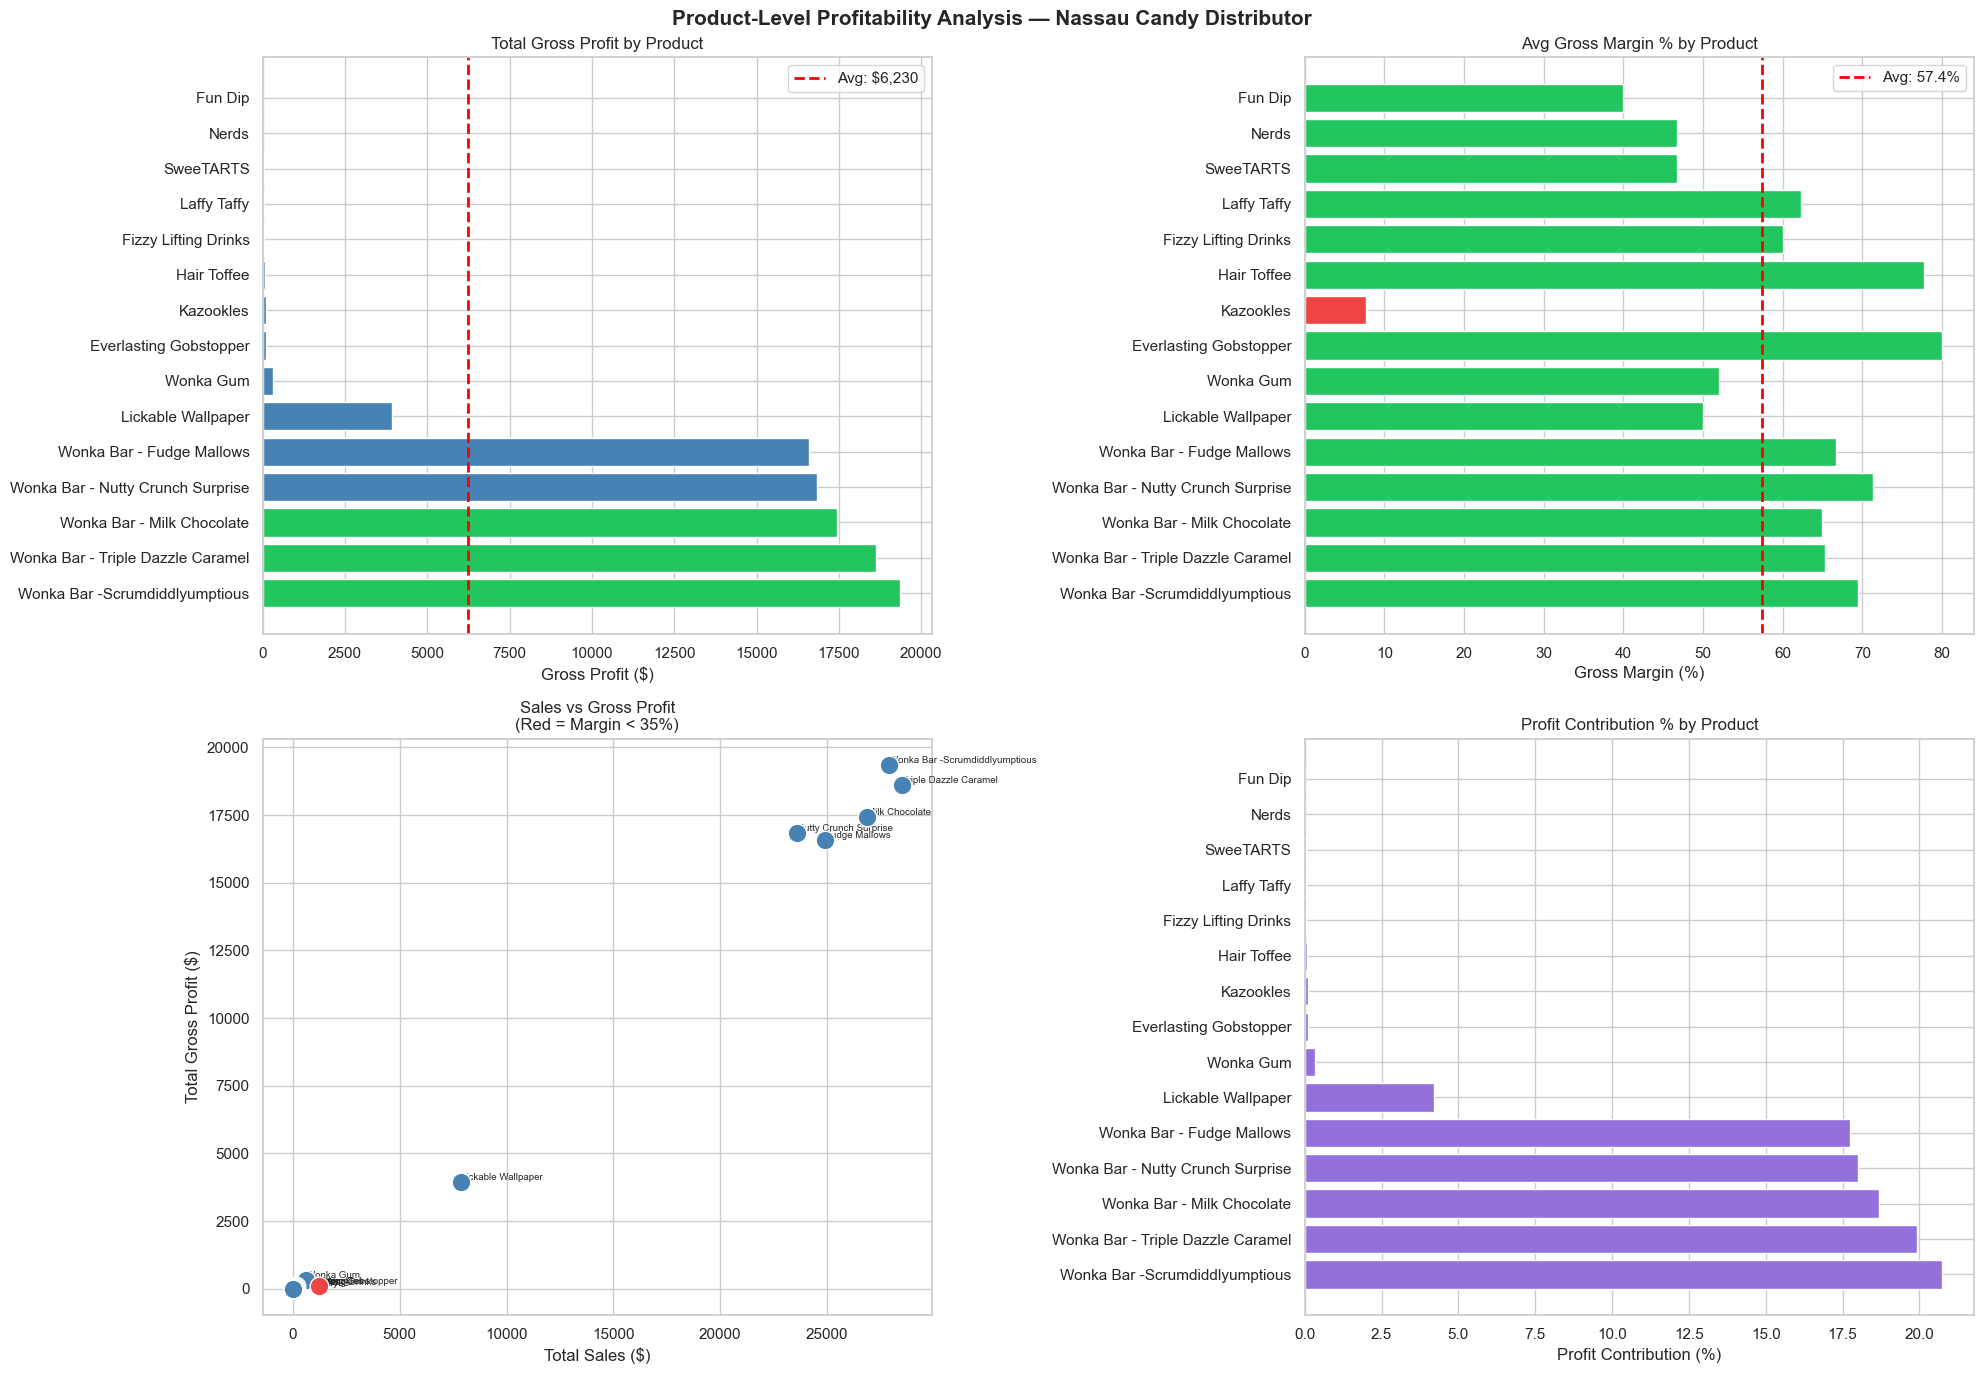


📊 Margin Risk Distribution:
Margin Risk
High Risk       96
Low Risk     10098


In [34]:
# Cell 6 — Product-Level Profitability Analysis

# ── Aggregate by Product ──
product_summary = df.groupby(['Product Name', 'Division']).agg(
    Total_Sales          = ('Sales',                'sum'),
    Total_Profit         = ('Gross Profit',         'sum'),
    Total_Cost           = ('Cost',                 'sum'),
    Total_Units          = ('Units',                'sum'),
    Avg_Gross_Margin     = ('Gross Margin %',       'mean'),
    Avg_Profit_per_Unit  = ('Profit per Unit',      'mean'),
    Total_Orders         = ('Order ID',             'count'),
    Revenue_Contribution = ('Revenue Contribution %','sum'),
    Profit_Contribution  = ('Profit Contribution %', 'sum')
).reset_index().round(2)

product_summary = product_summary.sort_values('Total_Profit', ascending=False).reset_index(drop=True)
product_summary.index += 1

print("📊 Product-Level Profitability Summary:")
display(product_summary)

# ── Top & Bottom Performers ──
print("\n🏆 Top 5 Products by Gross Profit:")
print(product_summary.head(5)[['Product Name','Division','Total_Sales',
                                'Total_Profit','Avg_Gross_Margin']].to_string())

print("\n⚠️  Bottom 5 Products by Gross Profit:")
print(product_summary.tail(5)[['Product Name','Division','Total_Sales',
                                'Total_Profit','Avg_Gross_Margin']].to_string())

# ── Plots ──
fig, axes = plt.subplots(2, 2, figsize=(20, 14))
fig.suptitle('Product-Level Profitability Analysis — Nassau Candy Distributor',
             fontsize=15, fontweight='bold')

# Plot 1: Total Gross Profit by Product
colors_p = ['#22c55e' if i < 3 else 'steelblue' for i in range(len(product_summary))]
axes[0,0].barh(product_summary['Product Name'],
               product_summary['Total_Profit'],
               color=colors_p, edgecolor='white')
axes[0,0].axvline(product_summary['Total_Profit'].mean(), color='red',
                   linestyle='--', lw=2,
                   label=f"Avg: ${product_summary['Total_Profit'].mean():,.0f}")
axes[0,0].set_title('Total Gross Profit by Product')
axes[0,0].set_xlabel('Gross Profit ($)')
axes[0,0].legend()

# Plot 2: Avg Gross Margin % by Product
colors_m = ['#ef4444' if v < 35 else '#22c55e' for v in product_summary['Avg_Gross_Margin']]
axes[0,1].barh(product_summary['Product Name'],
               product_summary['Avg_Gross_Margin'],
               color=colors_m, edgecolor='white')
axes[0,1].axvline(product_summary['Avg_Gross_Margin'].mean(), color='red',
                   linestyle='--', lw=2,
                   label=f"Avg: {product_summary['Avg_Gross_Margin'].mean():.1f}%")
axes[0,1].set_title('Avg Gross Margin % by Product')
axes[0,1].set_xlabel('Gross Margin (%)')
axes[0,1].legend()

# Plot 3: Sales vs Profit Scatter (High-sales / low-margin detection)
for i, row in product_summary.iterrows():
    axes[1,0].scatter(row['Total_Sales'], row['Total_Profit'],
                      s=180, zorder=5,
                      color='steelblue' if row['Avg_Gross_Margin'] >= 35 else '#ef4444',
                      edgecolors='white')
    axes[1,0].annotate(row['Product Name'].split(' - ')[-1],
                        (row['Total_Sales'], row['Total_Profit']),
                        fontsize=7, ha='left', va='bottom')
axes[1,0].set_title('Sales vs Gross Profit\n(Red = Margin < 35%)')
axes[1,0].set_xlabel('Total Sales ($)')
axes[1,0].set_ylabel('Total Gross Profit ($)')

# Plot 4: Profit Contribution % by Product
axes[1,1].barh(product_summary['Product Name'],
               product_summary['Profit_Contribution'],
               color='mediumpurple', edgecolor='white')
axes[1,1].set_title('Profit Contribution % by Product')
axes[1,1].set_xlabel('Profit Contribution (%)')

plt.tight_layout()
plt.savefig('plot_product_profitability.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Margin Risk Breakdown ──
print("\n📊 Margin Risk Distribution:")
print(df.groupby('Margin Risk')['Product Name'].count().to_string())

📊 Division-Level Performance Summary:


,Division,Total_Sales,Total_Profit,Total_Cost,Total_Units,Avg_Gross_Margin,Avg_Profit_per_Unit,Total_Orders,Revenue_Contribution,Profit_Contribution
0,Chocolate,131692.90,88824.62,42868.28,37275,67.46,2.38,9844,92.91,95.06
1,Other,9663.25,4333.45,5329.80,1242,37.67,3.36,310,6.82,4.64
2,Sugar,427.48,284.73,142.75,137,57.69,1.89,40,0.30,0.30



📊 Revenue vs Profit Imbalance:
  Chocolate    | Revenue: 92.9%  Profit: 95.1%  Gap: +2.2% ✅
  Other        | Revenue: 6.8%  Profit: 4.6%  Gap: -2.2% ⚠️
  Sugar        | Revenue: 0.3%  Profit: 0.3%  Gap: +0.0% ✅


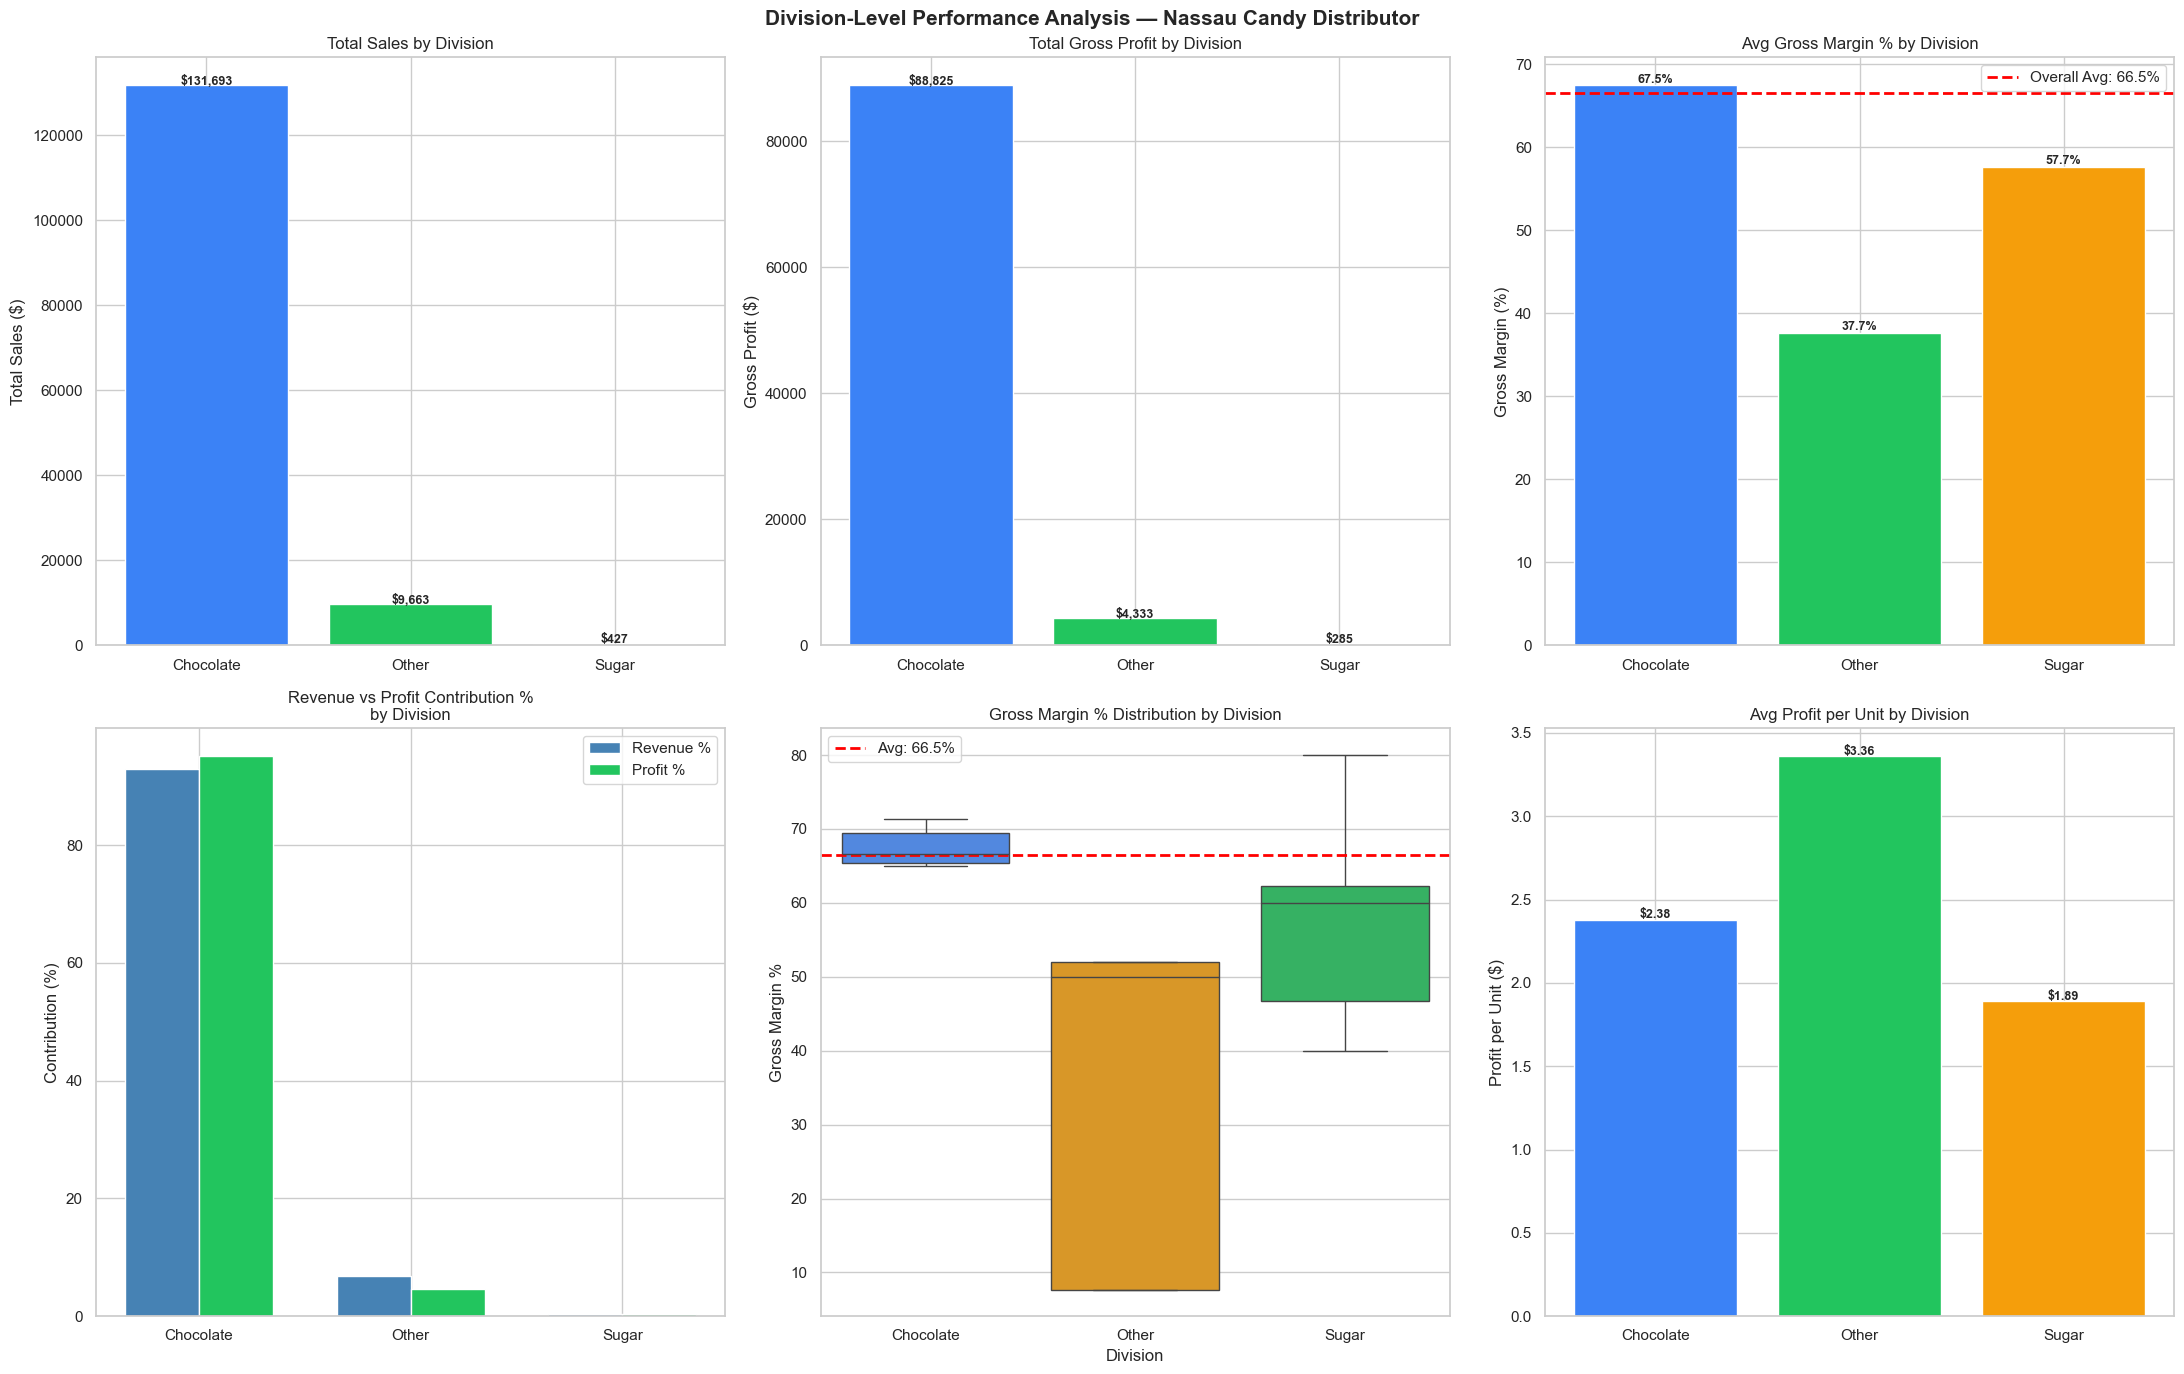


💡 Highest Margin Division : Chocolate  (67.5%)
💡 Lowest  Margin Division : Other (37.7%)


In [35]:
# Cell 7 — Division-Level Performance Analysis

# ── Aggregate by Division ──
division_summary = df.groupby('Division').agg(
    Total_Sales          = ('Sales',                'sum'),
    Total_Profit         = ('Gross Profit',         'sum'),
    Total_Cost           = ('Cost',                 'sum'),
    Total_Units          = ('Units',                'sum'),
    Avg_Gross_Margin     = ('Gross Margin %',       'mean'),
    Avg_Profit_per_Unit  = ('Profit per Unit',      'mean'),
    Total_Orders         = ('Order ID',             'count'),
    Revenue_Contribution = ('Revenue Contribution %','sum'),
    Profit_Contribution  = ('Profit Contribution %', 'sum')
).reset_index().round(2)

division_summary = division_summary.sort_values('Total_Profit', ascending=False).reset_index(drop=True)

print("📊 Division-Level Performance Summary:")
display(division_summary)

# ── Revenue vs Profit Imbalance ──
print("\n📊 Revenue vs Profit Imbalance:")
for _, row in division_summary.iterrows():
    rev_share = row['Revenue_Contribution']
    pro_share = row['Profit_Contribution']
    gap       = pro_share - rev_share
    flag      = '✅' if gap >= 0 else '⚠️'
    print(f"  {row['Division']:<12} | Revenue: {rev_share:.1f}%  Profit: {pro_share:.1f}%  Gap: {gap:+.1f}% {flag}")

# ── Plots ──
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Division-Level Performance Analysis — Nassau Candy Distributor',
             fontsize=15, fontweight='bold')

div_colors = ['#3b82f6', '#22c55e', '#f59e0b']

# Plot 1: Total Sales by Division
bars1 = axes[0,0].bar(division_summary['Division'],
                       division_summary['Total_Sales'],
                       color=div_colors, edgecolor='white')
axes[0,0].set_title('Total Sales by Division')
axes[0,0].set_ylabel('Total Sales ($)')
for bar, val in zip(bars1, division_summary['Total_Sales']):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 200,
                   f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Plot 2: Total Gross Profit by Division
bars2 = axes[0,1].bar(division_summary['Division'],
                       division_summary['Total_Profit'],
                       color=div_colors, edgecolor='white')
axes[0,1].set_title('Total Gross Profit by Division')
axes[0,1].set_ylabel('Gross Profit ($)')
for bar, val in zip(bars2, division_summary['Total_Profit']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 100,
                   f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Plot 3: Avg Gross Margin % by Division
bars3 = axes[0,2].bar(division_summary['Division'],
                       division_summary['Avg_Gross_Margin'],
                       color=div_colors, edgecolor='white')
axes[0,2].axhline(df['Gross Margin %'].mean(), color='red', linestyle='--', lw=2,
                   label=f"Overall Avg: {df['Gross Margin %'].mean():.1f}%")
axes[0,2].set_title('Avg Gross Margin % by Division')
axes[0,2].set_ylabel('Gross Margin (%)')
axes[0,2].legend()
for bar, val in zip(bars3, division_summary['Avg_Gross_Margin']):
    axes[0,2].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.3,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Plot 4: Revenue vs Profit Contribution (Grouped Bar)
x     = np.arange(len(division_summary))
width = 0.35
axes[1,0].bar(x - width/2, division_summary['Revenue_Contribution'],
              width, label='Revenue %', color='steelblue', edgecolor='white')
axes[1,0].bar(x + width/2, division_summary['Profit_Contribution'],
              width, label='Profit %',  color='#22c55e',  edgecolor='white')
axes[1,0].set_xticks(x)
axes[1,0].set_xticklabels(division_summary['Division'])
axes[1,0].set_title('Revenue vs Profit Contribution %\nby Division')
axes[1,0].set_ylabel('Contribution (%)')
axes[1,0].legend()

# Plot 5: Gross Margin Distribution by Division (Boxplot)
sns.boxplot(data=df, x='Division', y='Gross Margin %',
            palette={'Chocolate':'#3b82f6','Sugar':'#22c55e','Other':'#f59e0b'},
            ax=axes[1,1])
axes[1,1].axhline(df['Gross Margin %'].mean(), color='red', linestyle='--', lw=2,
                   label=f"Avg: {df['Gross Margin %'].mean():.1f}%")
axes[1,1].set_title('Gross Margin % Distribution by Division')
axes[1,1].legend()

# Plot 6: Avg Profit per Unit by Division
bars6 = axes[1,2].bar(division_summary['Division'],
                       division_summary['Avg_Profit_per_Unit'],
                       color=div_colors, edgecolor='white')
axes[1,2].set_title('Avg Profit per Unit by Division')
axes[1,2].set_ylabel('Profit per Unit ($)')
for bar, val in zip(bars6, division_summary['Avg_Profit_per_Unit']):
    axes[1,2].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.01,
                   f'${val:.2f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_division_performance.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Key Findings ──
best_div  = division_summary.loc[division_summary['Avg_Gross_Margin'].idxmax(), 'Division']
worst_div = division_summary.loc[division_summary['Avg_Gross_Margin'].idxmin(), 'Division']
print(f"\n💡 Highest Margin Division : {best_div}  ({division_summary.loc[division_summary['Division']==best_div, 'Avg_Gross_Margin'].values[0]:.1f}%)")
print(f"💡 Lowest  Margin Division : {worst_div} ({division_summary.loc[division_summary['Division']==worst_div,'Avg_Gross_Margin'].values[0]:.1f}%)")

📊 Pareto Table — Product Profitability Concentration:


,Product Name,Division,Total_Sales,Total_Profit,Avg_Gross_Margin,Cumulative_Profit_%,Cumulative_Revenue_%
0,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,19357.50,69.44,20.72,19.66
1,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,18610.20,65.33,40.63,39.75
2,Wonka Bar - Milk Chocolate,Chocolate,26867.75,17443.37,64.92,59.30,58.70
3,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,16819.95,71.35,77.30,75.33
4,Wonka Bar - Fudge Mallows,Chocolate,24890.40,16593.60,66.67,95.06,92.88
5,Lickable Wallpaper,Other,7860.00,3930.00,50.00,99.26,98.43
6,Wonka Gum,Other,597.50,310.70,52.00,99.60,98.85
7,Everlasting Gobstopper,Sugar,130.00,104.00,80.00,99.71,98.94
8,Kazookles,Other,1205.75,92.75,7.69,99.81,99.79
9,Hair Toffee,Sugar,76.50,59.50,77.78,99.87,99.84



💡 5 out of 15 products drive 80% of total profit
💡 5 out of 15 products drive 80% of total revenue

💡 16 out of 59 states drive 80% of total profit

📊 Top 10 States by Profit:


,State/Province,Total_Profit,Total_Sales,Total_Orders,Cumulative_Profit_%
0,California,18479.42,27917.40,2001,19.78
1,New York,10222.44,15541.03,1128,30.72
2,Texas,8909.53,13416.09,985,40.25
3,Pennsylvania,5225.47,8027.03,587,45.84
4,Washington,4566.64,6921.15,506,50.73
5,Illinois,4557.68,6898.96,492,55.61
6,Ohio,4413.03,6768.95,469,60.33
7,Florida,3207.11,4804.02,383,63.76
8,North Carolina,2331.16,3450.86,249,66.26
9,Arizona,2290.11,3587.55,224,68.71


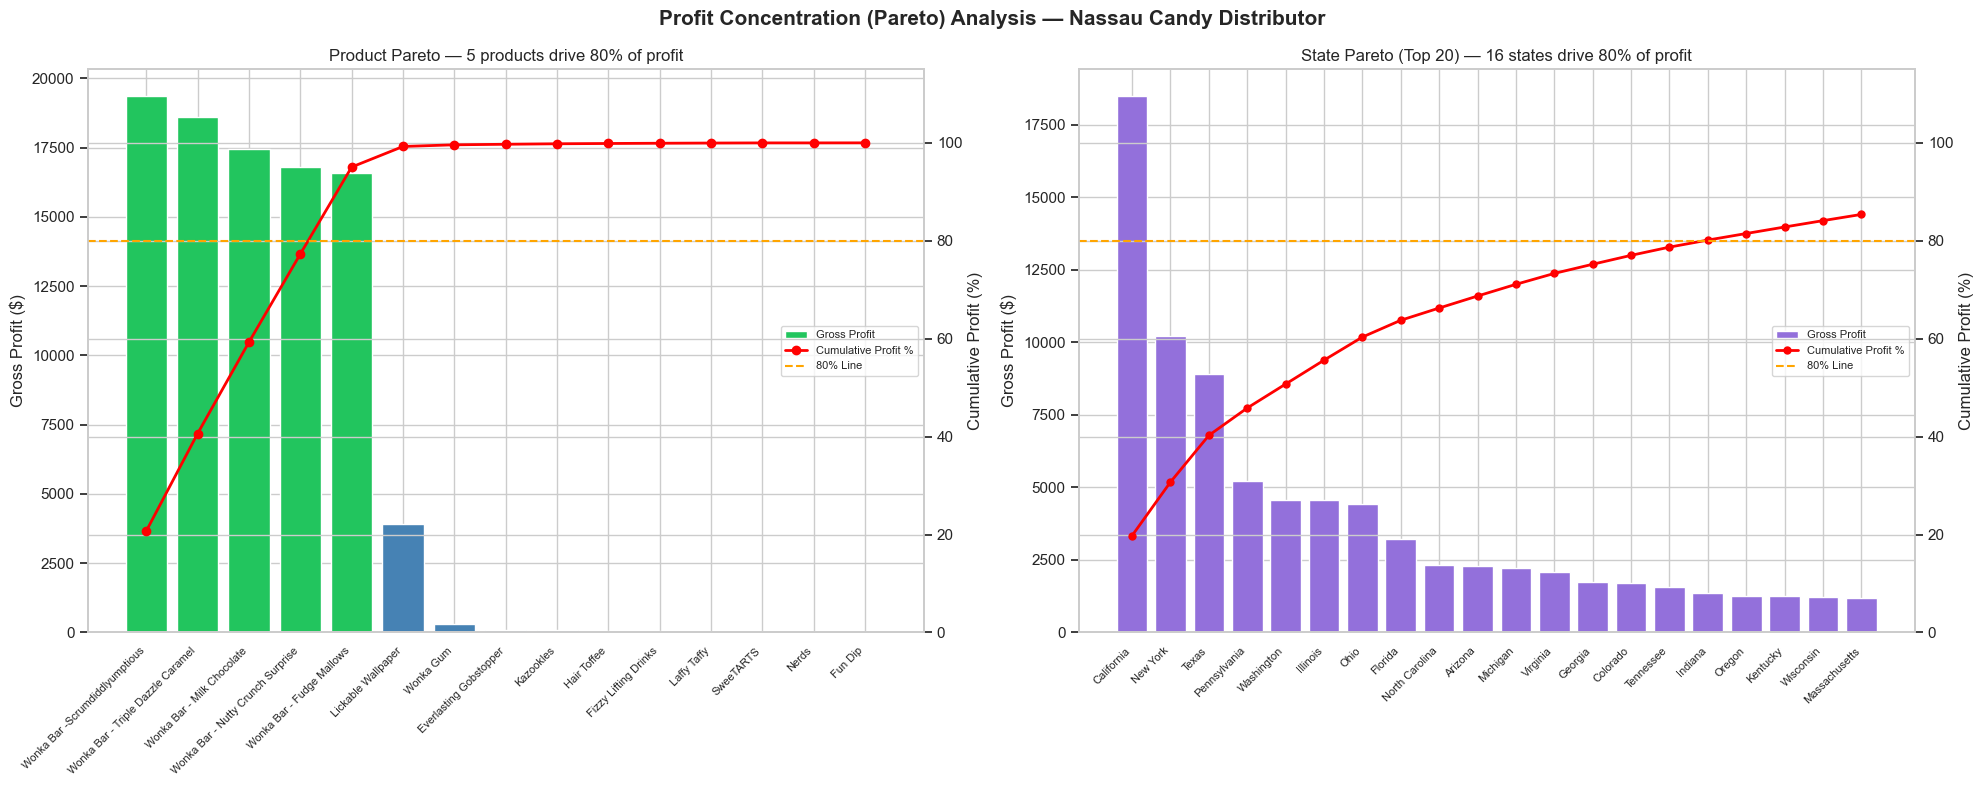


⚠️  Over-Dependency Check:
   Top 1 product drives : 20.7% of total profit
   Top 3 products drive : 59.3% of total profit
   ✅ Profit is reasonably diversified across products


In [36]:
# Cell 8 — Profit Concentration (Pareto) Analysis

# ── Product-Level Pareto ──
pareto = product_summary.sort_values('Total_Profit', ascending=False).copy()
pareto['Cumulative_Profit_%'] = (pareto['Total_Profit'].cumsum() /
                                  pareto['Total_Profit'].sum() * 100).round(2)
pareto['Cumulative_Revenue_%'] = (pareto['Total_Sales'].cumsum() /
                                   pareto['Total_Sales'].sum() * 100).round(2)
pareto['Product_Count_%'] = (np.arange(1, len(pareto)+1) / len(pareto) * 100).round(2)

print("📊 Pareto Table — Product Profitability Concentration:")
display(pareto[['Product Name', 'Division', 'Total_Sales', 'Total_Profit',
                'Avg_Gross_Margin', 'Cumulative_Profit_%', 'Cumulative_Revenue_%']].reset_index(drop=True))

# ── How many products drive 80% of profit ──
products_80_profit  = (pareto['Cumulative_Profit_%']  <= 80).sum() + 1
products_80_revenue = (pareto['Cumulative_Revenue_%'] <= 80).sum() + 1
print(f"\n💡 {products_80_profit} out of {len(pareto)} products drive 80% of total profit")
print(f"💡 {products_80_revenue} out of {len(pareto)} products drive 80% of total revenue")

# ── State-Level Pareto ──
state_pareto = df.groupby('State/Province').agg(
    Total_Profit  = ('Gross Profit', 'sum'),
    Total_Sales   = ('Sales',        'sum'),
    Total_Orders  = ('Order ID',     'count')
).reset_index().sort_values('Total_Profit', ascending=False).reset_index(drop=True)

state_pareto['Cumulative_Profit_%'] = (state_pareto['Total_Profit'].cumsum() /
                                        state_pareto['Total_Profit'].sum() * 100).round(2)
states_80 = (state_pareto['Cumulative_Profit_%'] <= 80).sum() + 1
print(f"\n💡 {states_80} out of {state_pareto.shape[0]} states drive 80% of total profit")

print("\n📊 Top 10 States by Profit:")
display(state_pareto.head(10))

# ── Plots ──
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
fig.suptitle('Profit Concentration (Pareto) Analysis — Nassau Candy Distributor',
             fontsize=15, fontweight='bold')

# Plot 1: Product Pareto Chart
ax1  = axes[0]
ax1b = ax1.twinx()

bar_colors = ['#22c55e' if i < products_80_profit else 'steelblue'
              for i in range(len(pareto))]
ax1.bar(range(len(pareto)), pareto['Total_Profit'],
        color=bar_colors, edgecolor='white', label='Gross Profit')
ax1b.plot(range(len(pareto)), pareto['Cumulative_Profit_%'],
          color='red', marker='o', lw=2, markersize=6, label='Cumulative Profit %')
ax1b.axhline(80, color='orange', linestyle='--', lw=1.5, label='80% Line')
ax1b.set_ylabel('Cumulative Profit (%)')
ax1b.set_ylim(0, 115)
ax1.set_xticks(range(len(pareto)))
ax1.set_xticklabels(pareto['Product Name'], rotation=45, ha='right', fontsize=8)
ax1.set_title(f'Product Pareto — {products_80_profit} products drive 80% of profit')
ax1.set_ylabel('Gross Profit ($)')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax1b.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=8)

# Plot 2: State Pareto Chart (Top 20)
top_states = state_pareto.head(20)
ax2  = axes[1]
ax2b = ax2.twinx()

ax2.bar(range(len(top_states)), top_states['Total_Profit'],
        color='mediumpurple', edgecolor='white', label='Gross Profit')
ax2b.plot(range(len(top_states)), top_states['Cumulative_Profit_%'],
          color='red', marker='o', lw=2, markersize=5, label='Cumulative Profit %')
ax2b.axhline(80, color='orange', linestyle='--', lw=1.5, label='80% Line')
ax2b.set_ylabel('Cumulative Profit (%)')
ax2b.set_ylim(0, 115)
ax2.set_xticks(range(len(top_states)))
ax2.set_xticklabels(top_states['State/Province'], rotation=45, ha='right', fontsize=8)
ax2.set_title(f'State Pareto (Top 20) — {states_80} states drive 80% of profit')
ax2.set_ylabel('Gross Profit ($)')
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2b.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='center right', fontsize=8)

plt.tight_layout()
plt.savefig('plot_pareto_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Over-dependency Risk ──
top1_profit_share = pareto.iloc[0]['Profit_Contribution']
top3_profit_share = pareto.head(3)['Profit_Contribution'].sum()
print(f"\n⚠️  Over-Dependency Check:")
print(f"   Top 1 product drives : {top1_profit_share:.1f}% of total profit")
print(f"   Top 3 products drive : {top3_profit_share:.1f}% of total profit")
if top3_profit_share > 60:
    print("   ⚠️  High concentration risk — over-reliance on few products")
else:
    print("   ✅ Profit is reasonably diversified across products")

📊 Cost Structure Summary by Product:


,Product Name,Division,Total_Sales,Total_Cost,Total_Profit,Avg_Margin,Avg_Cost_per_Unit,Total_Units,Cost_to_Sales_Ratio
1,Kazookles,Other,1205.75,1113.00,92.75,7.69,3.00,371,92.31
2,Fun Dip,Sugar,12.00,7.20,4.80,40.00,0.90,8,60.00
3,Nerds,Sugar,15.00,8.00,7.00,46.67,0.80,10,53.33
4,SweeTARTS,Sugar,61.50,32.80,28.70,46.67,0.80,41,53.33
5,Lickable Wallpaper,Other,7860.00,3930.00,3930.00,50.00,10.00,393,50.00
6,Wonka Gum,Other,597.50,286.80,310.70,52.00,0.60,478,48.00
7,Fizzy Lifting Drinks,Sugar,78.75,31.50,47.25,60.00,1.50,21,40.00
8,Laffy Taffy,Sugar,53.73,20.25,33.48,62.31,0.75,27,37.69
9,Wonka Bar - Milk Chocolate,Chocolate,26867.75,9424.38,17443.37,64.92,1.14,8267,35.08
10,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,9874.80,18610.20,65.33,1.30,7596,34.67



⚠️  Cost-Heavy, Margin-Poor Products (Margin < 35% & Cost Ratio > 60%):


,Product Name,Division,Total_Sales,Total_Cost,Avg_Margin,Cost_to_Sales_Ratio
1,Kazookles,Other,1205.75,1113.0,7.69,92.31



🔴 Products Needing Repricing (Margin < 25%):


,Product Name,Division,Avg_Margin,Cost_to_Sales_Ratio,Avg_Cost_per_Unit
1,Kazookles,Other,7.69,92.31,3.0


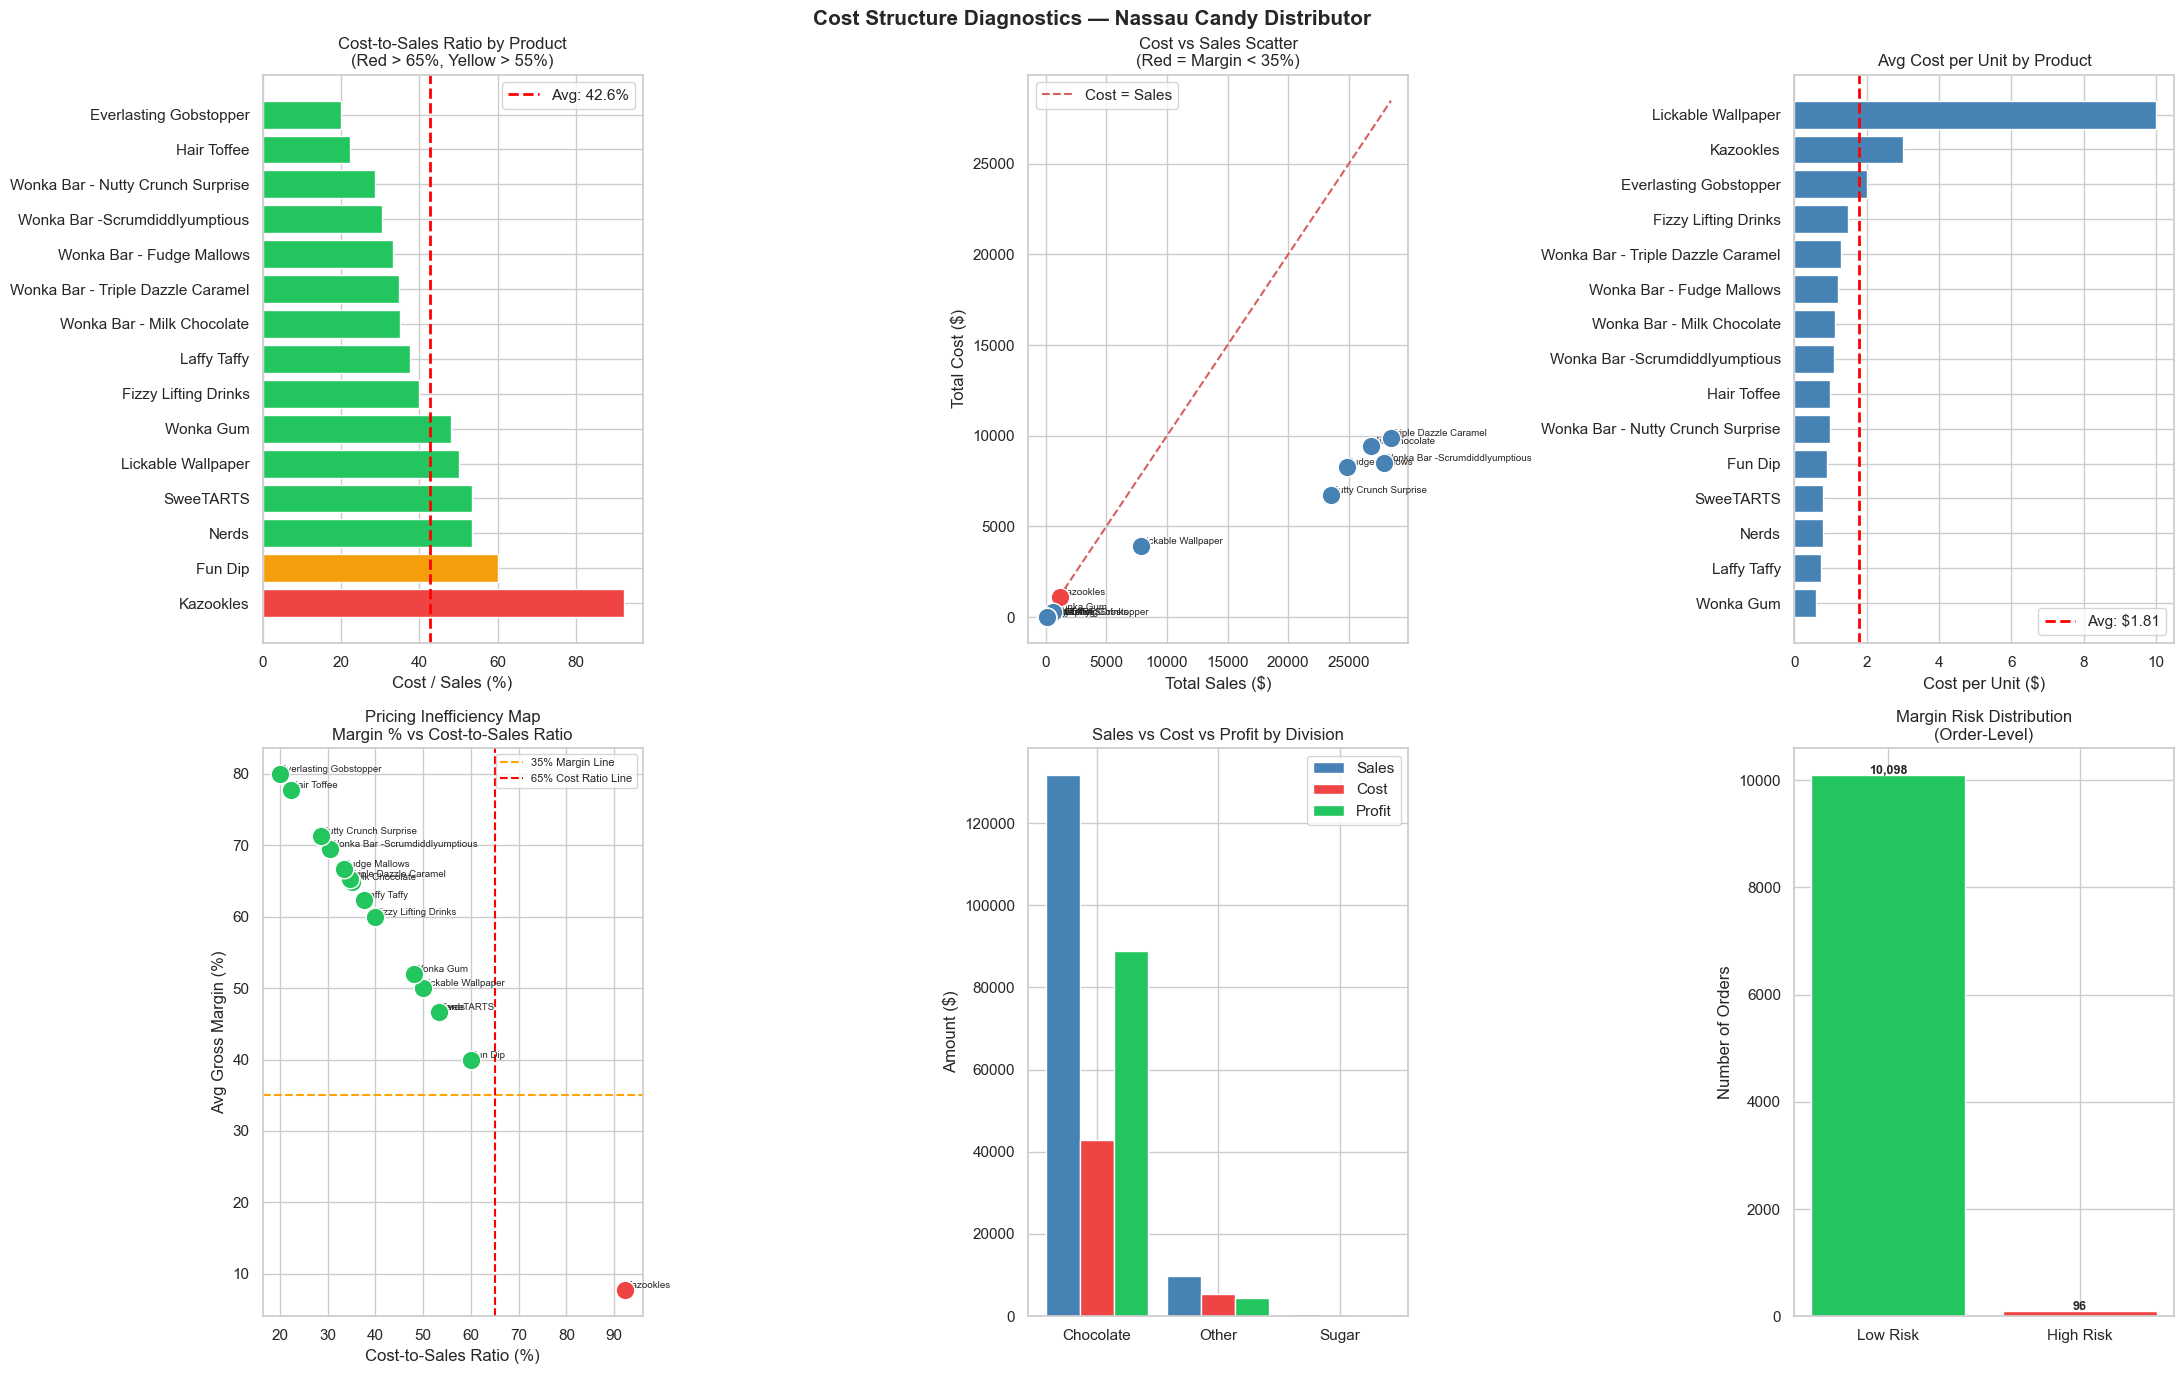


📊 Cost Structure by Division:
 Division  Total_Sales  Total_Cost  Total_Profit
Chocolate    131692.90    42868.28      88824.62
    Other      9663.25     5329.80       4333.45
    Sugar       427.48      142.75        284.73

💡 Most Cost-Efficient Product : Everlasting Gobstopper (Cost Ratio: 20.0%)
💡 Least Cost-Efficient Product: Kazookles (Cost Ratio: 92.3%)


In [37]:
# Cell 9 — Cost Structure Diagnostics

# ── Product-Level Cost Analysis ──
cost_summary = df.groupby(['Product Name', 'Division']).agg(
    Total_Sales      = ('Sales',           'sum'),
    Total_Cost       = ('Cost',            'sum'),
    Total_Profit     = ('Gross Profit',    'sum'),
    Avg_Margin       = ('Gross Margin %',  'mean'),
    Avg_Cost_per_Unit= ('Cost per Unit',   'mean'),
    Total_Units      = ('Units',           'sum')
).reset_index().round(2)

cost_summary['Cost_to_Sales_Ratio'] = (cost_summary['Total_Cost'] /
                                        cost_summary['Total_Sales'] * 100).round(2)
cost_summary = cost_summary.sort_values('Cost_to_Sales_Ratio', ascending=False).reset_index(drop=True)
cost_summary.index += 1

print("📊 Cost Structure Summary by Product:")
display(cost_summary)

# ── Flag Products Needing Attention ──
print("\n⚠️  Cost-Heavy, Margin-Poor Products (Margin < 35% & Cost Ratio > 60%):")
flagged = cost_summary[(cost_summary['Avg_Margin'] < 35) &
                        (cost_summary['Cost_to_Sales_Ratio'] > 60)]
if len(flagged) > 0:
    display(flagged[['Product Name', 'Division', 'Total_Sales',
                      'Total_Cost', 'Avg_Margin', 'Cost_to_Sales_Ratio']])
else:
    print("  ✅ No severely cost-heavy products found")

print("\n🔴 Products Needing Repricing (Margin < 25%):")
repricing = cost_summary[cost_summary['Avg_Margin'] < 25]
if len(repricing) > 0:
    display(repricing[['Product Name', 'Division', 'Avg_Margin',
                        'Cost_to_Sales_Ratio', 'Avg_Cost_per_Unit']])
else:
    print("  ✅ No products below 25% margin threshold")

# ── Plots ──
fig, axes = plt.subplots(2, 3, figsize=(22, 14))
fig.suptitle('Cost Structure Diagnostics — Nassau Candy Distributor',
             fontsize=15, fontweight='bold')

# Plot 1: Cost-to-Sales Ratio by Product
colors_c = ['#ef4444' if v > 65 else '#f59e0b' if v > 55 else '#22c55e'
            for v in cost_summary['Cost_to_Sales_Ratio']]
axes[0,0].barh(cost_summary['Product Name'],
               cost_summary['Cost_to_Sales_Ratio'],
               color=colors_c, edgecolor='white')
axes[0,0].axvline(cost_summary['Cost_to_Sales_Ratio'].mean(), color='red',
                   linestyle='--', lw=2,
                   label=f"Avg: {cost_summary['Cost_to_Sales_Ratio'].mean():.1f}%")
axes[0,0].set_title('Cost-to-Sales Ratio by Product\n(Red > 65%, Yellow > 55%)')
axes[0,0].set_xlabel('Cost / Sales (%)')
axes[0,0].legend()

# Plot 2: Cost vs Sales Scatter
for _, row in cost_summary.iterrows():
    color = '#ef4444' if row['Avg_Margin'] < 35 else 'steelblue'
    axes[0,1].scatter(row['Total_Sales'], row['Total_Cost'],
                      s=180, color=color, edgecolors='white', zorder=5)
    axes[0,1].annotate(row['Product Name'].split(' - ')[-1],
                        (row['Total_Sales'], row['Total_Cost']),
                        fontsize=7, ha='left', va='bottom')
# Perfect cost = sales line
max_val = max(cost_summary['Total_Sales'].max(), cost_summary['Total_Cost'].max())
axes[0,1].plot([0, max_val], [0, max_val], 'r--', lw=1.5, label='Cost = Sales')
axes[0,1].set_title('Cost vs Sales Scatter\n(Red = Margin < 35%)')
axes[0,1].set_xlabel('Total Sales ($)')
axes[0,1].set_ylabel('Total Cost ($)')
axes[0,1].legend()

# Plot 3: Avg Cost per Unit by Product
cost_sorted = cost_summary.sort_values('Avg_Cost_per_Unit', ascending=True)
axes[0,2].barh(cost_sorted['Product Name'],
               cost_sorted['Avg_Cost_per_Unit'],
               color='steelblue', edgecolor='white')
axes[0,2].axvline(cost_summary['Avg_Cost_per_Unit'].mean(), color='red',
                   linestyle='--', lw=2,
                   label=f"Avg: ${cost_summary['Avg_Cost_per_Unit'].mean():.2f}")
axes[0,2].set_title('Avg Cost per Unit by Product')
axes[0,2].set_xlabel('Cost per Unit ($)')
axes[0,2].legend()

# Plot 4: Margin vs Cost-to-Sales Scatter (Pricing Inefficiency Map)
for _, row in cost_summary.iterrows():
    color = '#ef4444' if row['Avg_Margin'] < 35 else '#22c55e'
    axes[1,0].scatter(row['Cost_to_Sales_Ratio'], row['Avg_Margin'],
                      s=180, color=color, edgecolors='white', zorder=5)
    axes[1,0].annotate(row['Product Name'].split(' - ')[-1],
                        (row['Cost_to_Sales_Ratio'], row['Avg_Margin']),
                        fontsize=7, ha='left', va='bottom')
axes[1,0].axhline(35, color='orange', linestyle='--', lw=1.5, label='35% Margin Line')
axes[1,0].axvline(65, color='red',    linestyle='--', lw=1.5, label='65% Cost Ratio Line')
axes[1,0].set_title('Pricing Inefficiency Map\nMargin % vs Cost-to-Sales Ratio')
axes[1,0].set_xlabel('Cost-to-Sales Ratio (%)')
axes[1,0].set_ylabel('Avg Gross Margin (%)')
axes[1,0].legend(fontsize=8)

# Plot 5: Cost Structure by Division
div_cost = df.groupby('Division').agg(
    Total_Sales  = ('Sales',        'sum'),
    Total_Cost   = ('Cost',         'sum'),
    Total_Profit = ('Gross Profit', 'sum')
).reset_index()
x     = np.arange(len(div_cost))
width = 0.28
axes[1,1].bar(x - width, div_cost['Total_Sales'],  width,
              label='Sales',  color='steelblue',   edgecolor='white')
axes[1,1].bar(x,          div_cost['Total_Cost'],   width,
              label='Cost',   color='#ef4444',      edgecolor='white')
axes[1,1].bar(x + width,  div_cost['Total_Profit'], width,
              label='Profit', color='#22c55e',      edgecolor='white')
axes[1,1].set_xticks(x)
axes[1,1].set_xticklabels(div_cost['Division'])
axes[1,1].set_title('Sales vs Cost vs Profit by Division')
axes[1,1].set_ylabel('Amount ($)')
axes[1,1].legend()

# Plot 6: Margin Risk Distribution
risk_counts = df['Margin Risk'].value_counts()
risk_colors = {'High Risk': '#ef4444', 'Medium Risk': '#f59e0b', 'Low Risk': '#22c55e'}
axes[1,2].bar(risk_counts.index,
              risk_counts.values,
              color=[risk_colors[r] for r in risk_counts.index],
              edgecolor='white')
axes[1,2].set_title('Margin Risk Distribution\n(Order-Level)')
axes[1,2].set_ylabel('Number of Orders')
for i, (idx, val) in enumerate(risk_counts.items()):
    axes[1,2].text(i, val + 20, f'{val:,}', ha='center',
                   fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_cost_diagnostics.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary ──
print("\n📊 Cost Structure by Division:")
print(div_cost.round(2).to_string(index=False))
print(f"\n💡 Most Cost-Efficient Product : {cost_summary.iloc[-1]['Product Name']} "
      f"(Cost Ratio: {cost_summary.iloc[-1]['Cost_to_Sales_Ratio']:.1f}%)")
print(f"💡 Least Cost-Efficient Product: {cost_summary.iloc[0]['Product Name']} "
      f"(Cost Ratio: {cost_summary.iloc[0]['Cost_to_Sales_Ratio']:.1f}%)")

         STATISTICAL HYPOTHESIS TESTING

📌 H1: Does Gross Margin % differ significantly across Divisions?
   F-statistic = 7205.728,  p = 0.0000  ✅ Significant
   Chocolate    Avg Margin: 67.46%
   Other        Avg Margin: 37.67%
   Sugar        Avg Margin: 57.69%
   ➡️  Conclusion: Margin varies significantly across divisions

📌 H2: Does Cost per Unit negatively correlate with Gross Margin?
   Pearson  r = -0.419,  p = 0.0000  ✅ Significant
   Spearman r = -0.625,  p = 0.0000  ✅ Significant
   ➡️  Conclusion: Higher cost per unit reduces gross margin

📌 H3: Does higher sales volume lead to better margins?
   Pearson r = -0.111,  p = 0.0000  ✅ Significant
   ➡️  Conclusion: Sales volume negatively impacts margin

📌 H4: Does Gross Margin % differ significantly across Regions?
   F-statistic = 4.570,  p = 0.0033  ✅ Significant
   Interior     Avg Margin: 66.87%
   Atlantic     Avg Margin: 66.20%
   Gulf         Avg Margin: 66.42%
   Pacific      Avg Margin: 66.59%
   ➡️  Conclusion: Marg

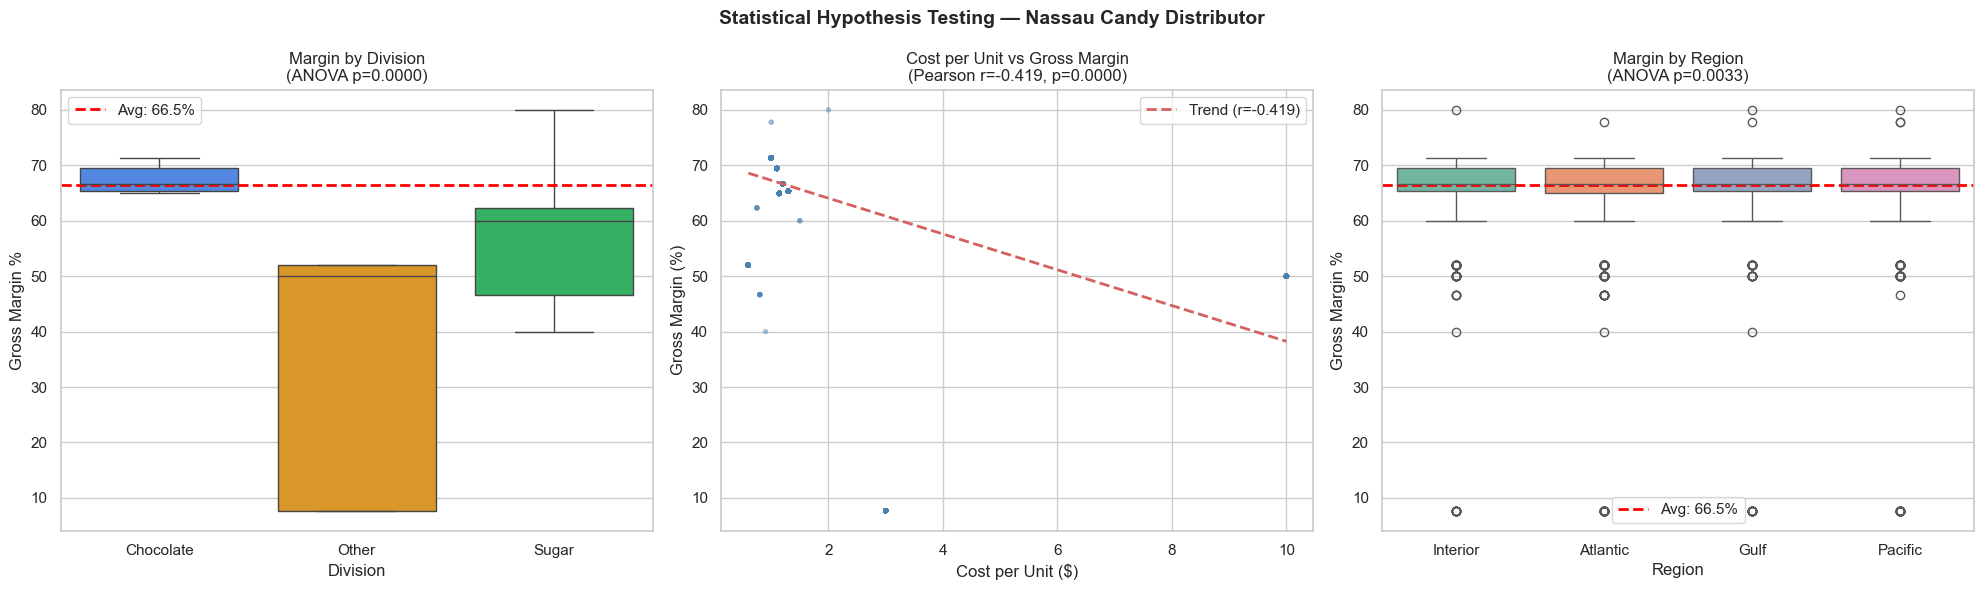


✅ All Hypothesis Tests Complete!


In [38]:
# Cell 10 — Statistical Hypothesis Testing

print("=" * 65)
print("         STATISTICAL HYPOTHESIS TESTING")
print("=" * 65)

# ── Hypothesis 1: Does Gross Margin differ across Divisions? ──
groups_div = [df[df['Division'] == d]['Gross Margin %'].dropna()
              for d in df['Division'].unique()]
f_stat, p_anova = f_oneway(*groups_div)

print("\n📌 H1: Does Gross Margin % differ significantly across Divisions?")
print(f"   F-statistic = {f_stat:.3f},  p = {p_anova:.4f}  "
      f"{'✅ Significant' if p_anova < 0.05 else '❌ Not Significant'}")
for d in df['Division'].unique():
    m = df[df['Division'] == d]['Gross Margin %'].mean()
    print(f"   {d:<12} Avg Margin: {m:.2f}%")
if p_anova < 0.05:
    print("   ➡️  Conclusion: Margin varies significantly across divisions")
else:
    print("   ➡️  Conclusion: No significant margin difference across divisions")

# ── Hypothesis 2: Does Cost per Unit correlate with Gross Margin? ──
clean = df.dropna(subset=['Cost per Unit', 'Gross Margin %'])
r_p, p_p = pearsonr(clean['Cost per Unit'], clean['Gross Margin %'])
r_s, p_s = spearmanr(clean['Cost per Unit'], clean['Gross Margin %'])

print("\n📌 H2: Does Cost per Unit negatively correlate with Gross Margin?")
print(f"   Pearson  r = {r_p:.3f},  p = {p_p:.4f}  "
      f"{'✅ Significant' if p_p < 0.05 else '❌ Not Significant'}")
print(f"   Spearman r = {r_s:.3f},  p = {p_s:.4f}  "
      f"{'✅ Significant' if p_s < 0.05 else '❌ Not Significant'}")
if p_p < 0.05:
    print(f"   ➡️  Conclusion: Higher cost per unit {'reduces' if r_p < 0 else 'increases'} gross margin")
else:
    print("   ➡️  Conclusion: No significant relationship found")

# ── Hypothesis 3: Does Sales Volume correlate with Gross Margin? ──
r_sv, p_sv = pearsonr(clean['Sales'], clean['Gross Margin %'])

print("\n📌 H3: Does higher sales volume lead to better margins?")
print(f"   Pearson r = {r_sv:.3f},  p = {p_sv:.4f}  "
      f"{'✅ Significant' if p_sv < 0.05 else '❌ Not Significant'}")
if p_sv < 0.05:
    print(f"   ➡️  Conclusion: Sales volume {'positively' if r_sv > 0 else 'negatively'} impacts margin")
else:
    print("   ➡️  Conclusion: Sales volume alone does not drive margin improvement")

# ── Hypothesis 4: Does Gross Margin differ across Regions? ──
groups_reg = [df[df['Region'] == r]['Gross Margin %'].dropna()
              for r in df['Region'].unique()]
f_reg, p_reg = f_oneway(*groups_reg)

print("\n📌 H4: Does Gross Margin % differ significantly across Regions?")
print(f"   F-statistic = {f_reg:.3f},  p = {p_reg:.4f}  "
      f"{'✅ Significant' if p_reg < 0.05 else '❌ Not Significant'}")
for r in df['Region'].unique():
    m = df[df['Region'] == r]['Gross Margin %'].mean()
    print(f"   {r:<12} Avg Margin: {m:.2f}%")
if p_reg < 0.05:
    print("   ➡️  Conclusion: Margin varies significantly across regions")
else:
    print("   ➡️  Conclusion: No significant margin difference across regions")

# ── Hypothesis 5: Do high-margin products drive disproportionate profit? ──
median_margin = df['Gross Margin %'].median()
high_margin   = df[df['Gross Margin %'] >= median_margin]['Gross Profit']
low_margin    = df[df['Gross Margin %'] <  median_margin]['Gross Profit']
t_stat, p_t   = ttest_ind(high_margin, low_margin)

print("\n📌 H5: Do high-margin orders generate significantly more profit?")
print(f"   High Margin avg profit : ${high_margin.mean():.2f}")
print(f"   Low  Margin avg profit : ${low_margin.mean():.2f}")
print(f"   T-statistic = {t_stat:.3f},  p = {p_t:.4f}  "
      f"{'✅ Significant' if p_t < 0.05 else '❌ Not Significant'}")
if p_t < 0.05:
    print("   ➡️  Conclusion: High-margin orders significantly outperform on profit")
else:
    print("   ➡️  Conclusion: No significant difference in profit between margin groups")

# ── Visualise Hypothesis Results ──
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Statistical Hypothesis Testing — Nassau Candy Distributor',
             fontsize=14, fontweight='bold')

# Plot 1: Margin by Division (Boxplot)
sns.boxplot(data=df, x='Division', y='Gross Margin %',
            palette={'Chocolate':'#3b82f6','Sugar':'#22c55e','Other':'#f59e0b'},
            ax=axes[0])
axes[0].axhline(df['Gross Margin %'].mean(), color='red', linestyle='--', lw=2,
                label=f"Avg: {df['Gross Margin %'].mean():.1f}%")
axes[0].set_title(f'Margin by Division\n(ANOVA p={p_anova:.4f})')
axes[0].legend()

# Plot 2: Cost per Unit vs Gross Margin Scatter
axes[1].scatter(df['Cost per Unit'], df['Gross Margin %'],
                alpha=0.2, color='steelblue', s=15, edgecolors='none')
m_line, b_line = np.polyfit(clean['Cost per Unit'], clean['Gross Margin %'], 1)
x_line = np.linspace(clean['Cost per Unit'].min(), clean['Cost per Unit'].max(), 100)
axes[1].plot(x_line, m_line*x_line + b_line, 'r--', lw=2,
             label=f'Trend (r={r_p:.3f})')
axes[1].set_title(f'Cost per Unit vs Gross Margin\n(Pearson r={r_p:.3f}, p={p_p:.4f})')
axes[1].set_xlabel('Cost per Unit ($)')
axes[1].set_ylabel('Gross Margin (%)')
axes[1].legend()

# Plot 3: Margin by Region (Boxplot)
sns.boxplot(data=df, x='Region', y='Gross Margin %',
            palette='Set2', ax=axes[2])
axes[2].axhline(df['Gross Margin %'].mean(), color='red', linestyle='--', lw=2,
                label=f"Avg: {df['Gross Margin %'].mean():.1f}%")
axes[2].set_title(f'Margin by Region\n(ANOVA p={p_reg:.4f})')
axes[2].legend()

plt.tight_layout()
plt.savefig('plot_hypothesis_testing.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 65)
print("✅ All Hypothesis Tests Complete!")
print("=" * 65)

📊 Regional Performance Summary:


,Region,Total_Sales,Total_Profit,Total_Cost,Total_Units,Avg_Gross_Margin,Total_Orders,Revenue_Contribution %,Profit_Contribution %
0,Pacific,46301.53,30485.94,15815.59,12466,66.59,3253,32.66,32.63
1,Atlantic,41197.24,26973.70,14223.54,11159,66.20,2986,29.06,28.87
2,Interior,32037.60,21282.49,10755.11,8820,66.87,2335,22.60,22.78
3,Gulf,22247.26,14700.67,7546.59,6209,66.42,1620,15.69,15.73



📊 Monthly Performance Trend:


,Order Year,Order Month,Total_Sales,Total_Profit,Avg_Gross_Margin,Total_Orders,Period
0,2024,1,2093.90,1366.14,65.92,148,2024-01-01
1,2024,2,1379.87,908.59,66.26,110,2024-02-01
2,2024,3,4138.90,2671.16,65.60,300,2024-03-01
3,2024,4,3988.22,2612.81,66.74,295,2024-04-01
4,2024,5,3951.52,2615.44,66.34,282,2024-05-01
5,2024,6,3518.76,2330.72,66.32,274,2024-06-01
6,2024,7,3865.38,2565.26,66.29,283,2024-07-01
7,2024,8,4477.65,2945.87,66.40,320,2024-08-01
8,2024,9,7912.10,5206.70,66.78,568,2024-09-01
9,2024,10,4815.98,3119.46,66.27,335,2024-10-01



📊 Avg Gross Margin % — Division × Region:


Region,Atlantic,Gulf,Interior,Pacific
Division,,,,
Chocolate,67.42,67.45,67.51,67.45
Other,36.32,36.86,42.59,36.81
Sugar,54.30,63.73,54.33,67.42


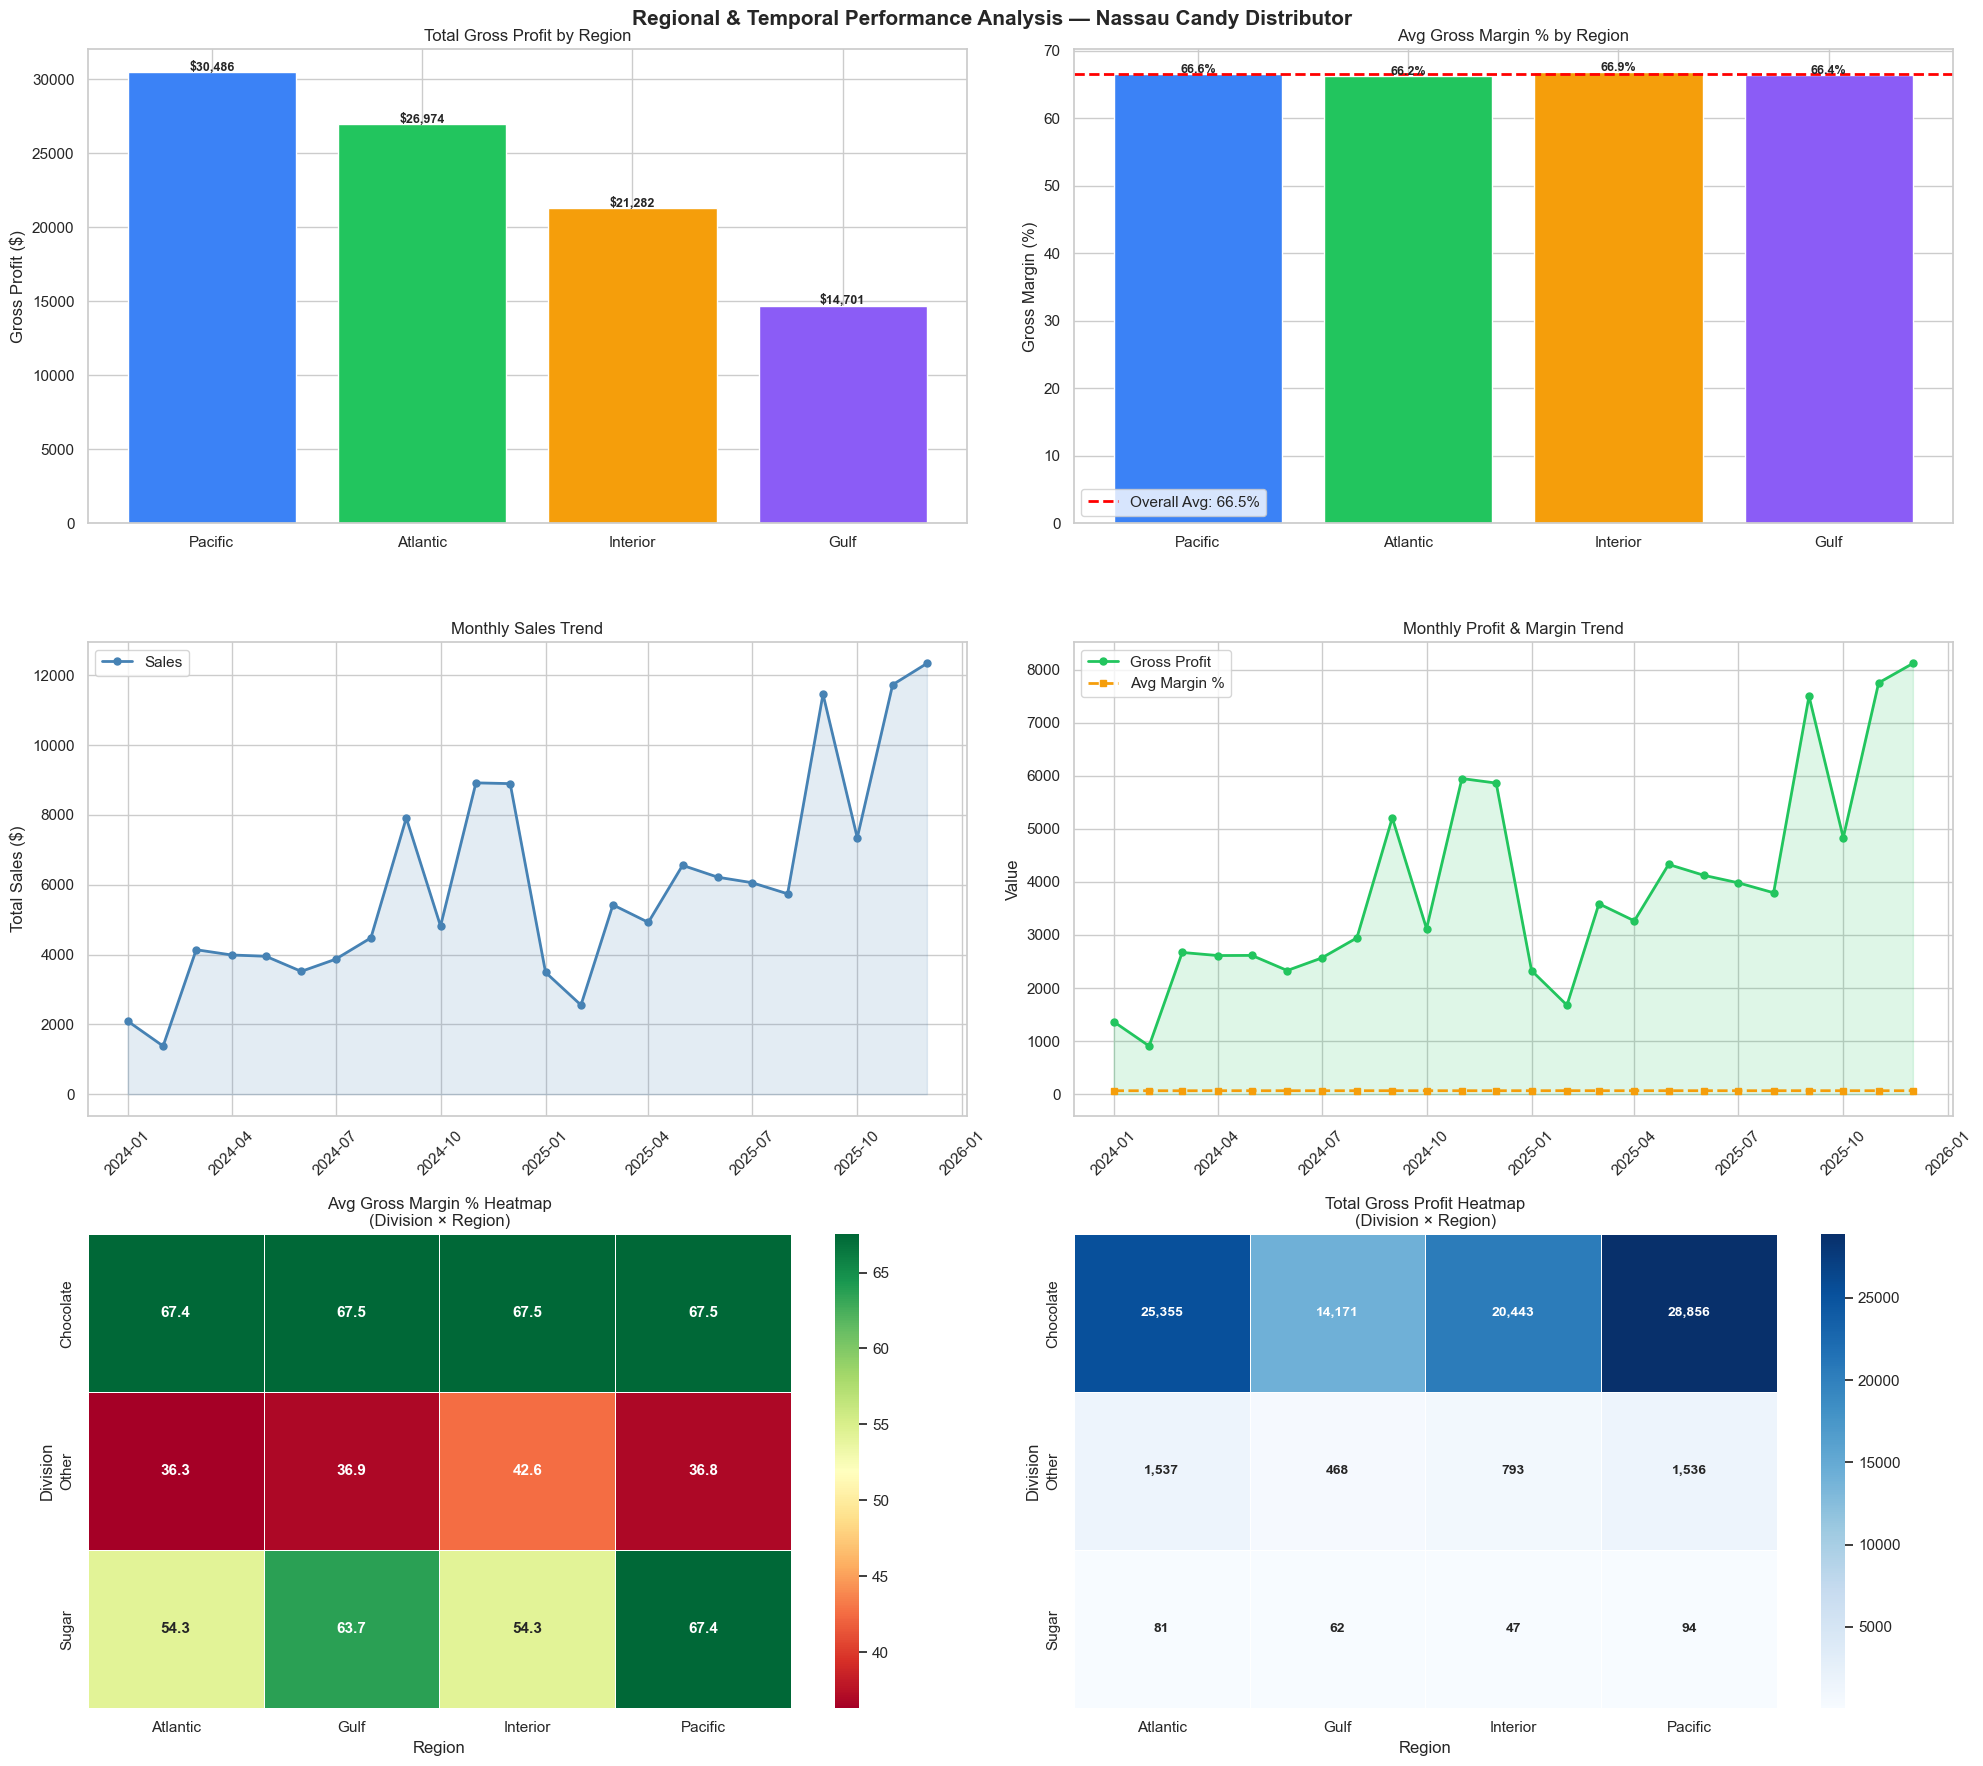


💡 Highest Margin Region : Interior
💡 Lowest  Margin Region : Atlantic
💡 Best  Month (Profit)  : Dec 2025  ($8,115.95)
💡 Worst Month (Profit)  : Feb 2024 ($908.59)


In [39]:
# Cell 11 — Regional & Temporal Performance Analysis

# ── Regional Summary ──
region_summary = df.groupby('Region').agg(
    Total_Sales      = ('Sales',          'sum'),
    Total_Profit     = ('Gross Profit',   'sum'),
    Total_Cost       = ('Cost',           'sum'),
    Total_Units      = ('Units',          'sum'),
    Avg_Gross_Margin = ('Gross Margin %', 'mean'),
    Total_Orders     = ('Order ID',       'count')
).reset_index().round(2)

region_summary['Revenue_Contribution %'] = (region_summary['Total_Sales'] /
                                              region_summary['Total_Sales'].sum() * 100).round(2)
region_summary['Profit_Contribution %']  = (region_summary['Total_Profit'] /
                                              region_summary['Total_Profit'].sum() * 100).round(2)
region_summary = region_summary.sort_values('Total_Profit', ascending=False).reset_index(drop=True)

print("📊 Regional Performance Summary:")
display(region_summary)

# ── Monthly Trend ──
monthly = df.groupby(['Order Year', 'Order Month']).agg(
    Total_Sales      = ('Sales',          'sum'),
    Total_Profit     = ('Gross Profit',   'sum'),
    Avg_Gross_Margin = ('Gross Margin %', 'mean'),
    Total_Orders     = ('Order ID',       'count')
).reset_index().round(2)

monthly['Period'] = pd.to_datetime(
    monthly['Order Year'].astype(str) + '-' +
    monthly['Order Month'].astype(str).str.zfill(2)
)
monthly = monthly.sort_values('Period').reset_index(drop=True)

print("\n📊 Monthly Performance Trend:")
display(monthly)

# ── Division × Region Heatmap Data ──
div_reg_pivot_margin = df.pivot_table(
    values='Gross Margin %',
    index='Division',
    columns='Region',
    aggfunc='mean'
).round(2)

div_reg_pivot_profit = df.pivot_table(
    values='Gross Profit',
    index='Division',
    columns='Region',
    aggfunc='sum'
).round(2)

print("\n📊 Avg Gross Margin % — Division × Region:")
display(div_reg_pivot_margin)

# ── Plots ──
fig, axes = plt.subplots(3, 2, figsize=(20, 18))
fig.suptitle('Regional & Temporal Performance Analysis — Nassau Candy Distributor',
             fontsize=15, fontweight='bold')

reg_colors = ['#3b82f6','#22c55e','#f59e0b','#8b5cf6']

# Plot 1: Total Profit by Region
bars1 = axes[0,0].bar(region_summary['Region'],
                       region_summary['Total_Profit'],
                       color=reg_colors, edgecolor='white')
axes[0,0].set_title('Total Gross Profit by Region')
axes[0,0].set_ylabel('Gross Profit ($)')
for bar, val in zip(bars1, region_summary['Total_Profit']):
    axes[0,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 100,
                   f'${val:,.0f}', ha='center', fontsize=9, fontweight='bold')

# Plot 2: Avg Gross Margin % by Region
bars2 = axes[0,1].bar(region_summary['Region'],
                       region_summary['Avg_Gross_Margin'],
                       color=reg_colors, edgecolor='white')
axes[0,1].axhline(df['Gross Margin %'].mean(), color='red', linestyle='--', lw=2,
                   label=f"Overall Avg: {df['Gross Margin %'].mean():.1f}%")
axes[0,1].set_title('Avg Gross Margin % by Region')
axes[0,1].set_ylabel('Gross Margin (%)')
axes[0,1].legend()
for bar, val in zip(bars2, region_summary['Avg_Gross_Margin']):
    axes[0,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.2,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Plot 3: Monthly Sales Trend
axes[1,0].plot(monthly['Period'], monthly['Total_Sales'],
               color='steelblue', marker='o', lw=2, markersize=5, label='Sales')
axes[1,0].fill_between(monthly['Period'], monthly['Total_Sales'],
                        alpha=0.15, color='steelblue')
axes[1,0].set_title('Monthly Sales Trend')
axes[1,0].set_ylabel('Total Sales ($)')
axes[1,0].tick_params(axis='x', rotation=45)
axes[1,0].legend()

# Plot 4: Monthly Profit Trend
axes[1,1].plot(monthly['Period'], monthly['Total_Profit'],
               color='#22c55e', marker='o', lw=2, markersize=5, label='Gross Profit')
axes[1,1].fill_between(monthly['Period'], monthly['Total_Profit'],
                        alpha=0.15, color='#22c55e')
axes[1,1].plot(monthly['Period'], monthly['Avg_Gross_Margin'],
               color='#f59e0b', marker='s', lw=2, markersize=5,
               linestyle='--', label='Avg Margin %')
axes[1,1].set_title('Monthly Profit & Margin Trend')
axes[1,1].set_ylabel('Value')
axes[1,1].tick_params(axis='x', rotation=45)
axes[1,1].legend()

# Plot 5: Division × Region Margin Heatmap
sns.heatmap(div_reg_pivot_margin, annot=True, fmt='.1f',
            cmap='RdYlGn', linewidths=0.5,
            vmin=div_reg_pivot_margin.values.min(),
            vmax=div_reg_pivot_margin.values.max(),
            annot_kws={'size':11, 'weight':'bold'}, ax=axes[2,0])
axes[2,0].set_title('Avg Gross Margin % Heatmap\n(Division × Region)')
axes[2,0].set_xlabel('Region')
axes[2,0].set_ylabel('Division')

# Plot 6: Division × Region Profit Heatmap
sns.heatmap(div_reg_pivot_profit, annot=True, fmt=',.0f',
            cmap='Blues', linewidths=0.5,
            annot_kws={'size':10, 'weight':'bold'}, ax=axes[2,1])
axes[2,1].set_title('Total Gross Profit Heatmap\n(Division × Region)')
axes[2,1].set_xlabel('Region')
axes[2,1].set_ylabel('Division')

plt.tight_layout()
plt.savefig('plot_regional_temporal.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Key Findings ──
best_reg  = region_summary.loc[region_summary['Avg_Gross_Margin'].idxmax(), 'Region']
worst_reg = region_summary.loc[region_summary['Avg_Gross_Margin'].idxmin(), 'Region']
best_month  = monthly.loc[monthly['Total_Profit'].idxmax(), 'Period'].strftime('%b %Y')
worst_month = monthly.loc[monthly['Total_Profit'].idxmin(), 'Period'].strftime('%b %Y')

print(f"\n💡 Highest Margin Region : {best_reg}")
print(f"💡 Lowest  Margin Region : {worst_reg}")
print(f"💡 Best  Month (Profit)  : {best_month}  (${monthly['Total_Profit'].max():,.2f})")
print(f"💡 Worst Month (Profit)  : {worst_month} (${monthly['Total_Profit'].min():,.2f})")

📊 Margin Volatility Summary per Product:


,Product Name,Division,Factory,Margin_Std,Margin_Mean,Margin_Min,Margin_Max,Months_Tracked,Margin_Range,Volatility_Flag
1,Everlasting Gobstopper,Sugar,Secret Factory,0.0,80.00,80.00,80.00,3,0.0,✅ Stable
2,Fun Dip,Sugar,Sugar Shack,0.0,40.00,40.00,40.00,2,0.0,✅ Stable
3,Hair Toffee,Sugar,The Other Factory,0.0,77.78,77.78,77.78,3,0.0,✅ Stable
4,Kazookles,Other,The Other Factory,0.0,7.69,7.69,7.69,23,0.0,✅ Stable
5,Laffy Taffy,Sugar,Sugar Shack,0.0,62.31,62.31,62.31,7,0.0,✅ Stable
6,Lickable Wallpaper,Other,Secret Factory,0.0,50.00,50.00,50.00,20,0.0,✅ Stable
7,Nerds,Sugar,Sugar Shack,0.0,46.67,46.67,46.67,4,0.0,✅ Stable
8,SweeTARTS,Sugar,Sugar Shack,0.0,46.67,46.67,46.67,8,0.0,✅ Stable
9,Wonka Bar - Fudge Mallows,Chocolate,Lot's O' Nuts,0.0,66.67,66.67,66.67,24,0.0,✅ Stable
10,Wonka Bar - Milk Chocolate,Chocolate,Wicked Choccy's,0.0,64.92,64.92,64.92,24,0.0,✅ Stable



🔴 High Volatility Products   : 0
🟡 Medium Volatility Products : 0
✅ Stable Products            : 14


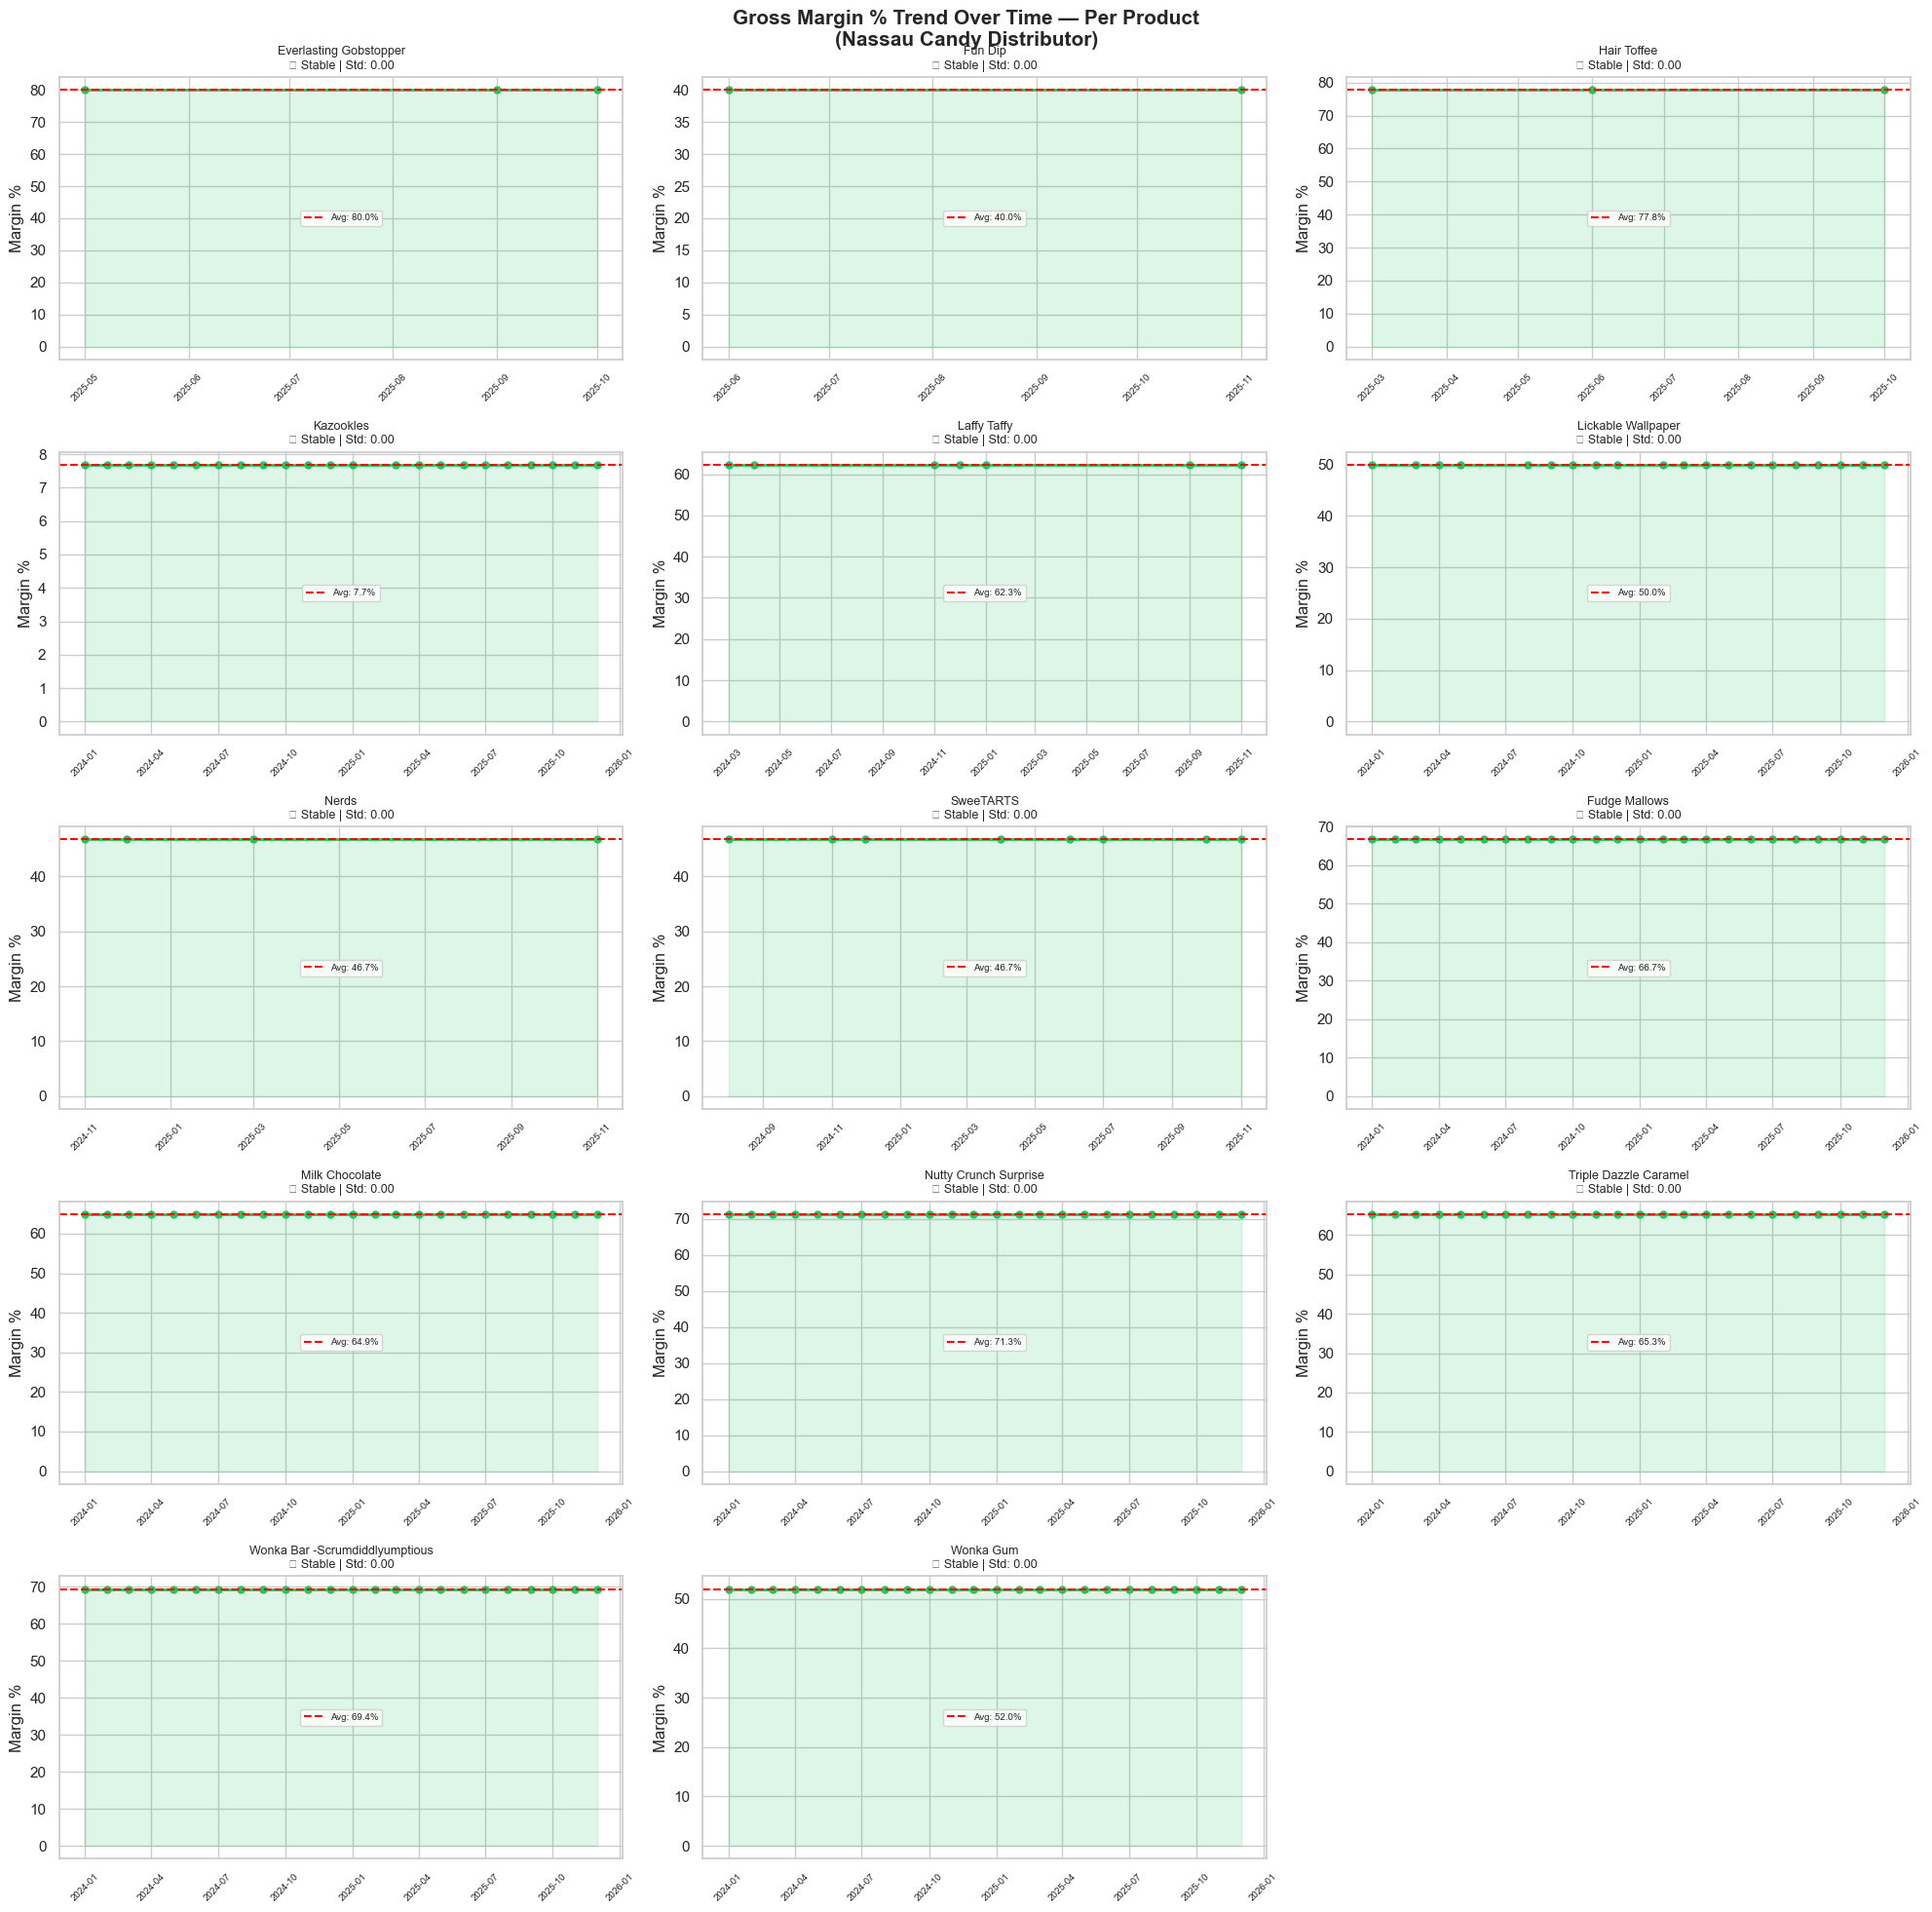

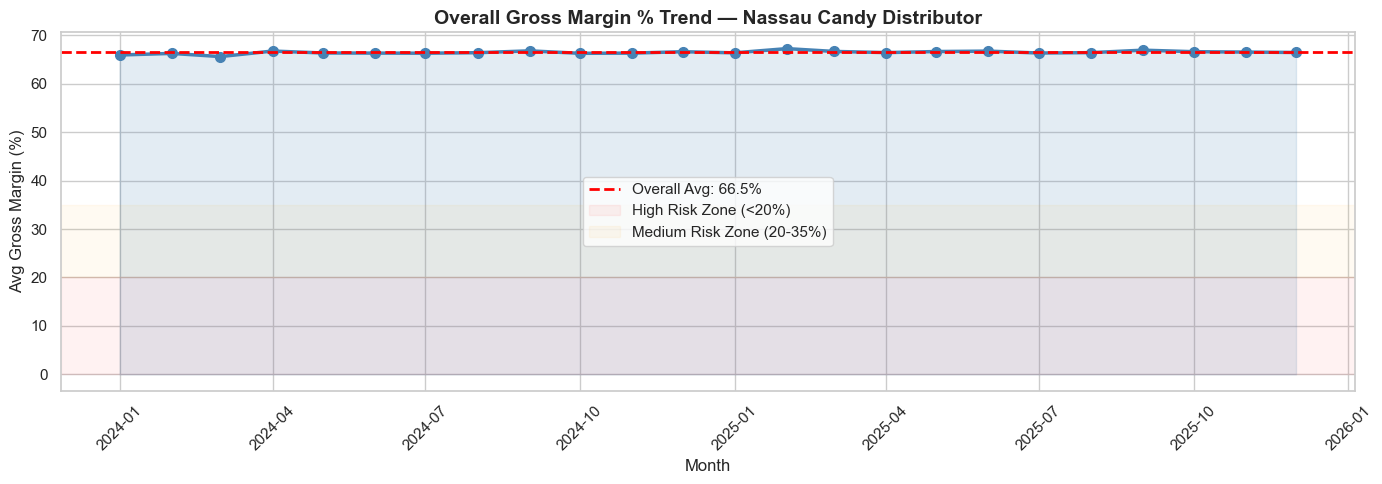


💡 Most  Stable Product : Wonka Gum (Std: 0.000)
💡 Most Volatile Product: Everlasting Gobstopper (Std: 0.000)

📊 Volatility by Factory:
Factory
The Other Factory    13.804
Sugar Shack           8.527
Secret Factory        3.521
Lot's O' Nuts         1.880
Wicked Choccy's       0.205


In [40]:
# Cell 11b — Margin Volatility Time-Series per Product

# ── Monthly Margin per Product ──
monthly_product = df.groupby(['Product Name', 'Division', 'Factory',
                               'Order Year', 'Order Month']).agg(
    Avg_Margin   = ('Gross Margin %', 'mean'),
    Total_Sales  = ('Sales',          'sum'),
    Total_Profit = ('Gross Profit',   'sum')
).reset_index().round(3)

monthly_product['Period'] = pd.to_datetime(
    monthly_product['Order Year'].astype(str) + '-' +
    monthly_product['Order Month'].astype(str).str.zfill(2)
)
monthly_product = monthly_product.sort_values(
    ['Product Name', 'Period']
).reset_index(drop=True)

# ── Volatility Metrics per Product ──
volatility_summary = monthly_product.groupby(
    ['Product Name', 'Division', 'Factory']
).agg(
    Margin_Std        = ('Avg_Margin', 'std'),
    Margin_Mean       = ('Avg_Margin', 'mean'),
    Margin_Min        = ('Avg_Margin', 'min'),
    Margin_Max        = ('Avg_Margin', 'max'),
    Months_Tracked    = ('Period',     'count')
).reset_index().round(3)

volatility_summary['Margin_Range']   = (
    volatility_summary['Margin_Max'] - volatility_summary['Margin_Min']
).round(3)

volatility_summary['Volatility_Flag'] = volatility_summary['Margin_Std'].apply(
    lambda x: '🔴 High Volatility'   if x > 5
         else '🟡 Medium Volatility' if x > 2
         else '✅ Stable'
)

volatility_summary = volatility_summary.sort_values(
    'Margin_Std', ascending=False
).reset_index(drop=True)
volatility_summary.index += 1

print("📊 Margin Volatility Summary per Product:")
display(volatility_summary)

print(f"\n🔴 High Volatility Products   : "
      f"{(volatility_summary['Volatility_Flag']=='🔴 High Volatility').sum()}")
print(f"🟡 Medium Volatility Products : "
      f"{(volatility_summary['Volatility_Flag']=='🟡 Medium Volatility').sum()}")
print(f"✅ Stable Products            : "
      f"{(volatility_summary['Volatility_Flag']=='✅ Stable').sum()}")

# ── Plots ──
products = monthly_product['Product Name'].unique()
n_cols   = 3
n_rows   = int(np.ceil(len(products) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols,
                          figsize=(20, n_rows * 4))
fig.suptitle('Gross Margin % Trend Over Time — Per Product\n(Nassau Candy Distributor)',
             fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, product in enumerate(sorted(products)):
    pdata = monthly_product[monthly_product['Product Name'] == product].copy()
    vol   = volatility_summary.loc[
        volatility_summary['Product Name'] == product, 'Margin_Std'
    ].values[0]
    flag  = volatility_summary.loc[
        volatility_summary['Product Name'] == product, 'Volatility_Flag'
    ].values[0]

    color = '#ef4444' if '🔴' in flag else '#f59e0b' if '🟡' in flag else '#22c55e'

    axes[i].plot(pdata['Period'], pdata['Avg_Margin'],
                 color=color, marker='o', lw=2, markersize=5)
    axes[i].fill_between(pdata['Period'], pdata['Avg_Margin'],
                          alpha=0.15, color=color)
    axes[i].axhline(pdata['Avg_Margin'].mean(), color='red',
                    linestyle='--', lw=1.5,
                    label=f"Avg: {pdata['Avg_Margin'].mean():.1f}%")
    axes[i].set_title(f"{product.split(' - ')[-1]}\n{flag} | Std: {vol:.2f}",
                      fontsize=9)
    axes[i].set_ylabel('Margin %')
    axes[i].tick_params(axis='x', rotation=45, labelsize=7)
    axes[i].legend(fontsize=7)

# Hide unused subplots
for j in range(len(products), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.savefig('plot_margin_volatility_timeseries.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Overall Platform Margin Trend ──
fig, ax = plt.subplots(figsize=(14, 5))
overall_monthly = df.groupby(['Order Year', 'Order Month']).agg(
    Avg_Margin = ('Gross Margin %', 'mean')
).reset_index()
overall_monthly['Period'] = pd.to_datetime(
    overall_monthly['Order Year'].astype(str) + '-' +
    overall_monthly['Order Month'].astype(str).str.zfill(2)
)
overall_monthly = overall_monthly.sort_values('Period')

ax.plot(overall_monthly['Period'], overall_monthly['Avg_Margin'],
        color='steelblue', marker='o', lw=2.5, markersize=7)
ax.fill_between(overall_monthly['Period'], overall_monthly['Avg_Margin'],
                alpha=0.15, color='steelblue')
ax.axhline(overall_monthly['Avg_Margin'].mean(), color='red',
           linestyle='--', lw=2,
           label=f"Overall Avg: {overall_monthly['Avg_Margin'].mean():.1f}%")

# Shade high/low months
ax.axhspan(0, 20,  alpha=0.05, color='red',   label='High Risk Zone (<20%)')
ax.axhspan(20, 35, alpha=0.05, color='orange', label='Medium Risk Zone (20-35%)')

ax.set_title('Overall Gross Margin % Trend — Nassau Candy Distributor',
             fontsize=14, fontweight='bold')
ax.set_ylabel('Avg Gross Margin (%)')
ax.set_xlabel('Month')
ax.tick_params(axis='x', rotation=45)
ax.legend()

plt.tight_layout()
plt.savefig('plot_overall_margin_trend.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Most & Least Stable Products ──
print(f"\n💡 Most  Stable Product : "
      f"{volatility_summary.iloc[-1]['Product Name']} "
      f"(Std: {volatility_summary.iloc[-1]['Margin_Std']:.3f})")
print(f"💡 Most Volatile Product: "
      f"{volatility_summary.iloc[0]['Product Name']} "
      f"(Std: {volatility_summary.iloc[0]['Margin_Std']:.3f})")
print(f"\n📊 Volatility by Factory:")
print(df.groupby('Factory')['Gross Margin %'].std().round(3).sort_values(
    ascending=False).to_string())

✅ ML Dataset Ready!
   Shape         : (53, 10)
   Target        : Avg_Gross_Margin
   Target Range  : 7.69% → 80.00%
   Target Mean   : 57.71%

── Features Used ──
   • Total_Sales
   • Total_Cost
   • Total_Units
   • Avg_Cost_per_Unit
   • Cost_to_Sales_Ratio
   • Margin_Volatility
   • Total_Orders
   • Revenue_Share
   • Division_enc
   • Region_enc

✅ Train/Test Split:
   Train : 42 samples
   Test  : 11 samples

📊 Feature Correlation Matrix:


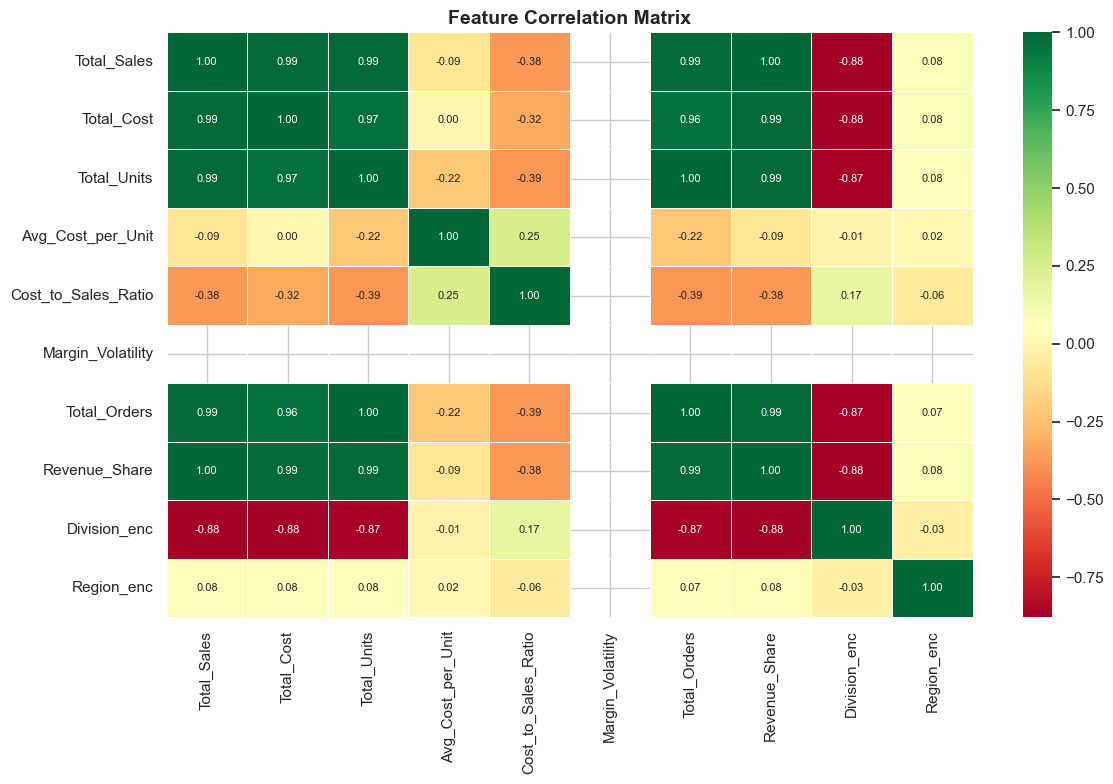


📊 ML Dataset Preview:


,Product Name,Division,Region,Total_Sales,Total_Profit,Total_Cost,Total_Units,Avg_Gross_Margin,Avg_Profit_per_Unit,Avg_Cost_per_Unit,Total_Orders,Margin_Volatility,Cost_to_Sales_Ratio,Revenue_Share,Profit_Share,Division_enc,Region_enc
0,Everlasting Gobstopper,Sugar,Gulf,40.00,32.00,8.0,4,80.0,8.00,2.0,1,0.0,20.0,0.028,0.034,2,1
1,Everlasting Gobstopper,Sugar,Interior,30.00,24.00,6.0,3,80.0,8.00,2.0,1,0.0,20.0,0.021,0.026,2,2
2,Everlasting Gobstopper,Sugar,Pacific,60.00,48.00,12.0,6,80.0,8.00,2.0,1,0.0,20.0,0.042,0.051,2,3
3,Fizzy Lifting Drinks,Sugar,Atlantic,33.75,20.25,13.5,9,60.0,2.25,1.5,2,0.0,40.0,0.024,0.022,2,0
4,Fizzy Lifting Drinks,Sugar,Gulf,15.00,9.00,6.0,4,60.0,2.25,1.5,1,0.0,40.0,0.011,0.010,2,1


In [41]:
# Cell 12 — ML Preparation & Feature Engineering for Modelling

# ── Build Product-Level ML Dataset ──
ml_product = df.groupby(['Product Name', 'Division', 'Region']).agg(
    Total_Sales       = ('Sales',            'sum'),
    Total_Profit      = ('Gross Profit',     'sum'),
    Total_Cost        = ('Cost',             'sum'),
    Total_Units       = ('Units',            'sum'),
    Avg_Gross_Margin  = ('Gross Margin %',   'mean'),
    Avg_Profit_per_Unit = ('Profit per Unit','mean'),
    Avg_Cost_per_Unit = ('Cost per Unit',    'mean'),
    Total_Orders      = ('Order ID',         'count'),
    Margin_Volatility = ('Gross Margin %',   'std')
).reset_index().round(3)

ml_product['Margin_Volatility']    = ml_product['Margin_Volatility'].fillna(0)
ml_product['Cost_to_Sales_Ratio']  = (ml_product['Total_Cost'] /
                                       ml_product['Total_Sales'] * 100).round(3)
ml_product['Revenue_Share']        = (ml_product['Total_Sales'] /
                                       ml_product['Total_Sales'].sum() * 100).round(3)
ml_product['Profit_Share']         = (ml_product['Total_Profit'] /
                                       ml_product['Total_Profit'].sum() * 100).round(3)

# ── Encode Categoricals ──
le_div = LabelEncoder()
le_reg = LabelEncoder()
ml_product['Division_enc'] = le_div.fit_transform(ml_product['Division'])
ml_product['Region_enc']   = le_reg.fit_transform(ml_product['Region'])

# ── Define Features & Target ──
feature_cols = [
    'Total_Sales', 'Total_Cost', 'Total_Units',
    'Avg_Cost_per_Unit', 'Cost_to_Sales_Ratio',
    'Margin_Volatility', 'Total_Orders',
    'Revenue_Share', 'Division_enc', 'Region_enc'
]

target_col = 'Avg_Gross_Margin'

ml_product = ml_product.dropna(subset=feature_cols + [target_col])

X = ml_product[feature_cols]
y = ml_product[target_col]

print(f"✅ ML Dataset Ready!")
print(f"   Shape         : {X.shape}")
print(f"   Target        : {target_col}")
print(f"   Target Range  : {y.min():.2f}% → {y.max():.2f}%")
print(f"   Target Mean   : {y.mean():.2f}%")

print(f"\n── Features Used ──")
for f in feature_cols:
    print(f"   • {f}")

# ── Scale & Split ──
scaler   = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"\n✅ Train/Test Split:")
print(f"   Train : {X_train.shape[0]} samples")
print(f"   Test  : {X_test.shape[0]} samples")

# ── Correlation Matrix ──
print("\n📊 Feature Correlation Matrix:")
fig, ax = plt.subplots(figsize=(12, 8))
corr = X_scaled.corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn',
            linewidths=0.5, annot_kws={'size': 8}, ax=ax)
ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('plot_correlation_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 ML Dataset Preview:")
display(ml_product.head())

🤖 Training Regression Models...
  Linear Regression      | CV R² = 1.000 ± 0.000 | Test R² = 1.000 | Test MAE = 0.002
  Ridge                  | CV R² = 0.995 ± 0.004 | Test R² = 0.999 | Test MAE = 0.281
  Lasso                  | CV R² = 1.000 ± 0.000 | Test R² = 1.000 | Test MAE = 0.006
  Decision Tree          | CV R² = 0.783 ± 0.141 | Test R² = 1.000 | Test MAE = 0.000
  Random Forest          | CV R² = 0.719 ± 0.225 | Test R² = 0.998 | Test MAE = 0.518
  Gradient Boosting      | CV R² = 0.808 ± 0.146 | Test R² = 1.000 | Test MAE = 0.089

📊 Model Comparison Table:


,Model,CV_R2_Mean,CV_R2_Std,CV_MAE_Mean,Test_R2,Test_MSE,Test_MAE
0,Linear Regression,1.0000,0.0000,0.0030,1.0000,0.0000,0.0020
1,Lasso,1.0000,0.0000,0.0110,1.0000,0.0001,0.0057
2,Ridge,0.9952,0.0035,0.6722,0.9993,0.2041,0.2810
3,Gradient Boosting,0.8080,0.1456,4.3218,0.9997,0.0855,0.0885
4,Decision Tree,0.7828,0.1414,5.1144,1.0000,0.0000,0.0000
5,Random Forest,0.7193,0.2251,4.9106,0.9983,0.5187,0.5180


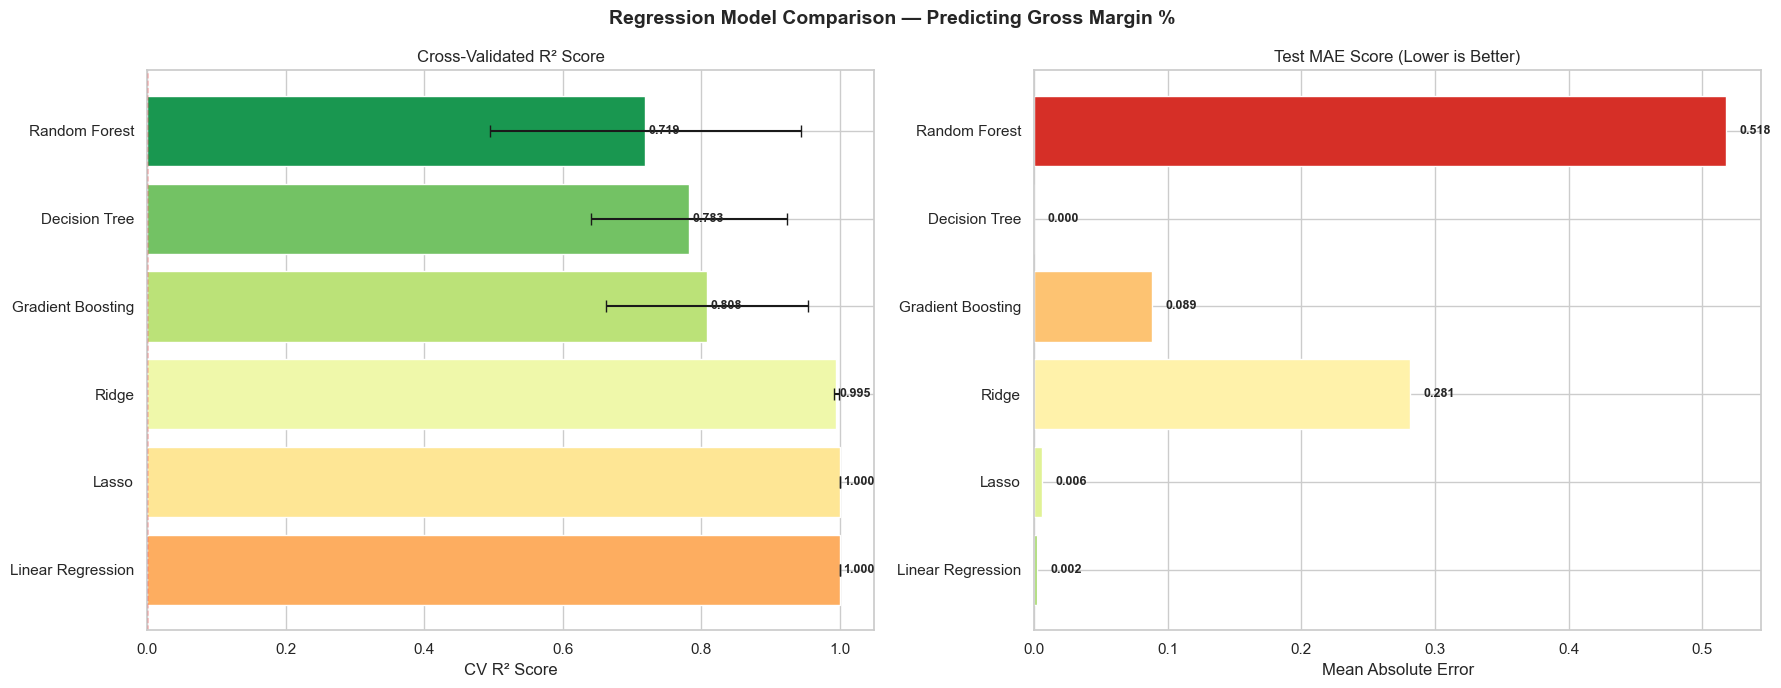


🏆 Best Model : Linear Regression (CV R² = 1.000)
   Test R²   : 1.000
   Test MAE  : 0.002


In [42]:
# Cell 13 — Multi-Model Regression Training (Predict Avg Gross Margin %)

models = {
    'Linear Regression'  : LinearRegression(),
    'Ridge'              : Ridge(alpha=1.0),
    'Lasso'              : Lasso(alpha=0.01, max_iter=5000),
    'Decision Tree'      : DecisionTreeRegressor(max_depth=6,
                                                  random_state=RANDOM_STATE),
    'Random Forest'      : RandomForestRegressor(n_estimators=200, max_depth=8,
                                                  random_state=RANDOM_STATE),
    'Gradient Boosting'  : GradientBoostingRegressor(n_estimators=200, max_depth=4,
                                                      learning_rate=0.05,
                                                      random_state=RANDOM_STATE),
}

results = []

print("🤖 Training Regression Models...")
print("=" * 65)

for name, model in models.items():
    # ── Cross Validation ──
    cv_r2  = cross_val_score(model, X_scaled, y, cv=5, scoring='r2')
    cv_mae = cross_val_score(model, X_scaled, y, cv=5,
                              scoring='neg_mean_absolute_error')

    # ── Train & Evaluate ──
    model.fit(X_train, y_train)
    y_pred   = model.predict(X_test)
    test_r2  = r2_score(y_test, y_pred)
    test_mse = mean_squared_error(y_test, y_pred)
    test_mae = mean_absolute_error(y_test, y_pred)

    results.append({
        'Model'      : name,
        'CV_R2_Mean' : cv_r2.mean(),
        'CV_R2_Std'  : cv_r2.std(),
        'CV_MAE_Mean': -cv_mae.mean(),
        'Test_R2'    : test_r2,
        'Test_MSE'   : test_mse,
        'Test_MAE'   : test_mae
    })

    print(f"  {name:<22} | CV R² = {cv_r2.mean():.3f} ± {cv_r2.std():.3f}"
          f" | Test R² = {test_r2:.3f} | Test MAE = {test_mae:.3f}")

results_df = pd.DataFrame(results).sort_values(
    'CV_R2_Mean', ascending=False
).reset_index(drop=True)

print("\n📊 Model Comparison Table:")
display(results_df.round(4))

# ── Model Comparison Plot ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Regression Model Comparison — Predicting Gross Margin %',
             fontsize=14, fontweight='bold')

# Plot 1: CV R² Score
colors_r = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(results_df)))
bars = axes[0].barh(results_df['Model'], results_df['CV_R2_Mean'],
                    xerr=results_df['CV_R2_Std'],
                    color=colors_r, edgecolor='white', capsize=4)
axes[0].axvline(0, color='red', linestyle='--', lw=1)
axes[0].set_title('Cross-Validated R² Score')
axes[0].set_xlabel('CV R² Score')
for bar, val in zip(bars, results_df['CV_R2_Mean']):
    axes[0].text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

# Plot 2: Test MAE
colors_m = plt.cm.RdYlGn_r(np.linspace(0.3, 0.9, len(results_df)))
bars2 = axes[1].barh(results_df['Model'], results_df['Test_MAE'],
                     color=colors_m, edgecolor='white')
axes[1].set_title('Test MAE Score (Lower is Better)')
axes[1].set_xlabel('Mean Absolute Error')
for bar, val in zip(bars2, results_df['Test_MAE']):
    axes[1].text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{val:.3f}', va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n🏆 Best Model : {results_df.iloc[0]['Model']}"
      f" (CV R² = {results_df.iloc[0]['CV_R2_Mean']:.3f})")
print(f"   Test R²   : {results_df.iloc[0]['Test_R2']:.3f}")
print(f"   Test MAE  : {results_df.iloc[0]['Test_MAE']:.3f}")

🏆 Best Model : Linear Regression
   Test R²   : 1.0000
   Test MSE  : 0.0000
   Test MAE  : 0.0020
   RMSE      : 0.0025

📊 Residual Analysis:
   Mean Residual : -0.0011  (closer to 0 = less bias)
   Std Residual  : 0.0023
   Max Overshot  : -0.0044
   Max Undershot : 0.0043

📊 Top 5 Features Driving Gross Margin %:
Cost_to_Sales_Ratio    17.732370
Revenue_Share           1.971674
Total_Sales             1.961181
Total_Units             0.006660
Total_Cost              0.006094


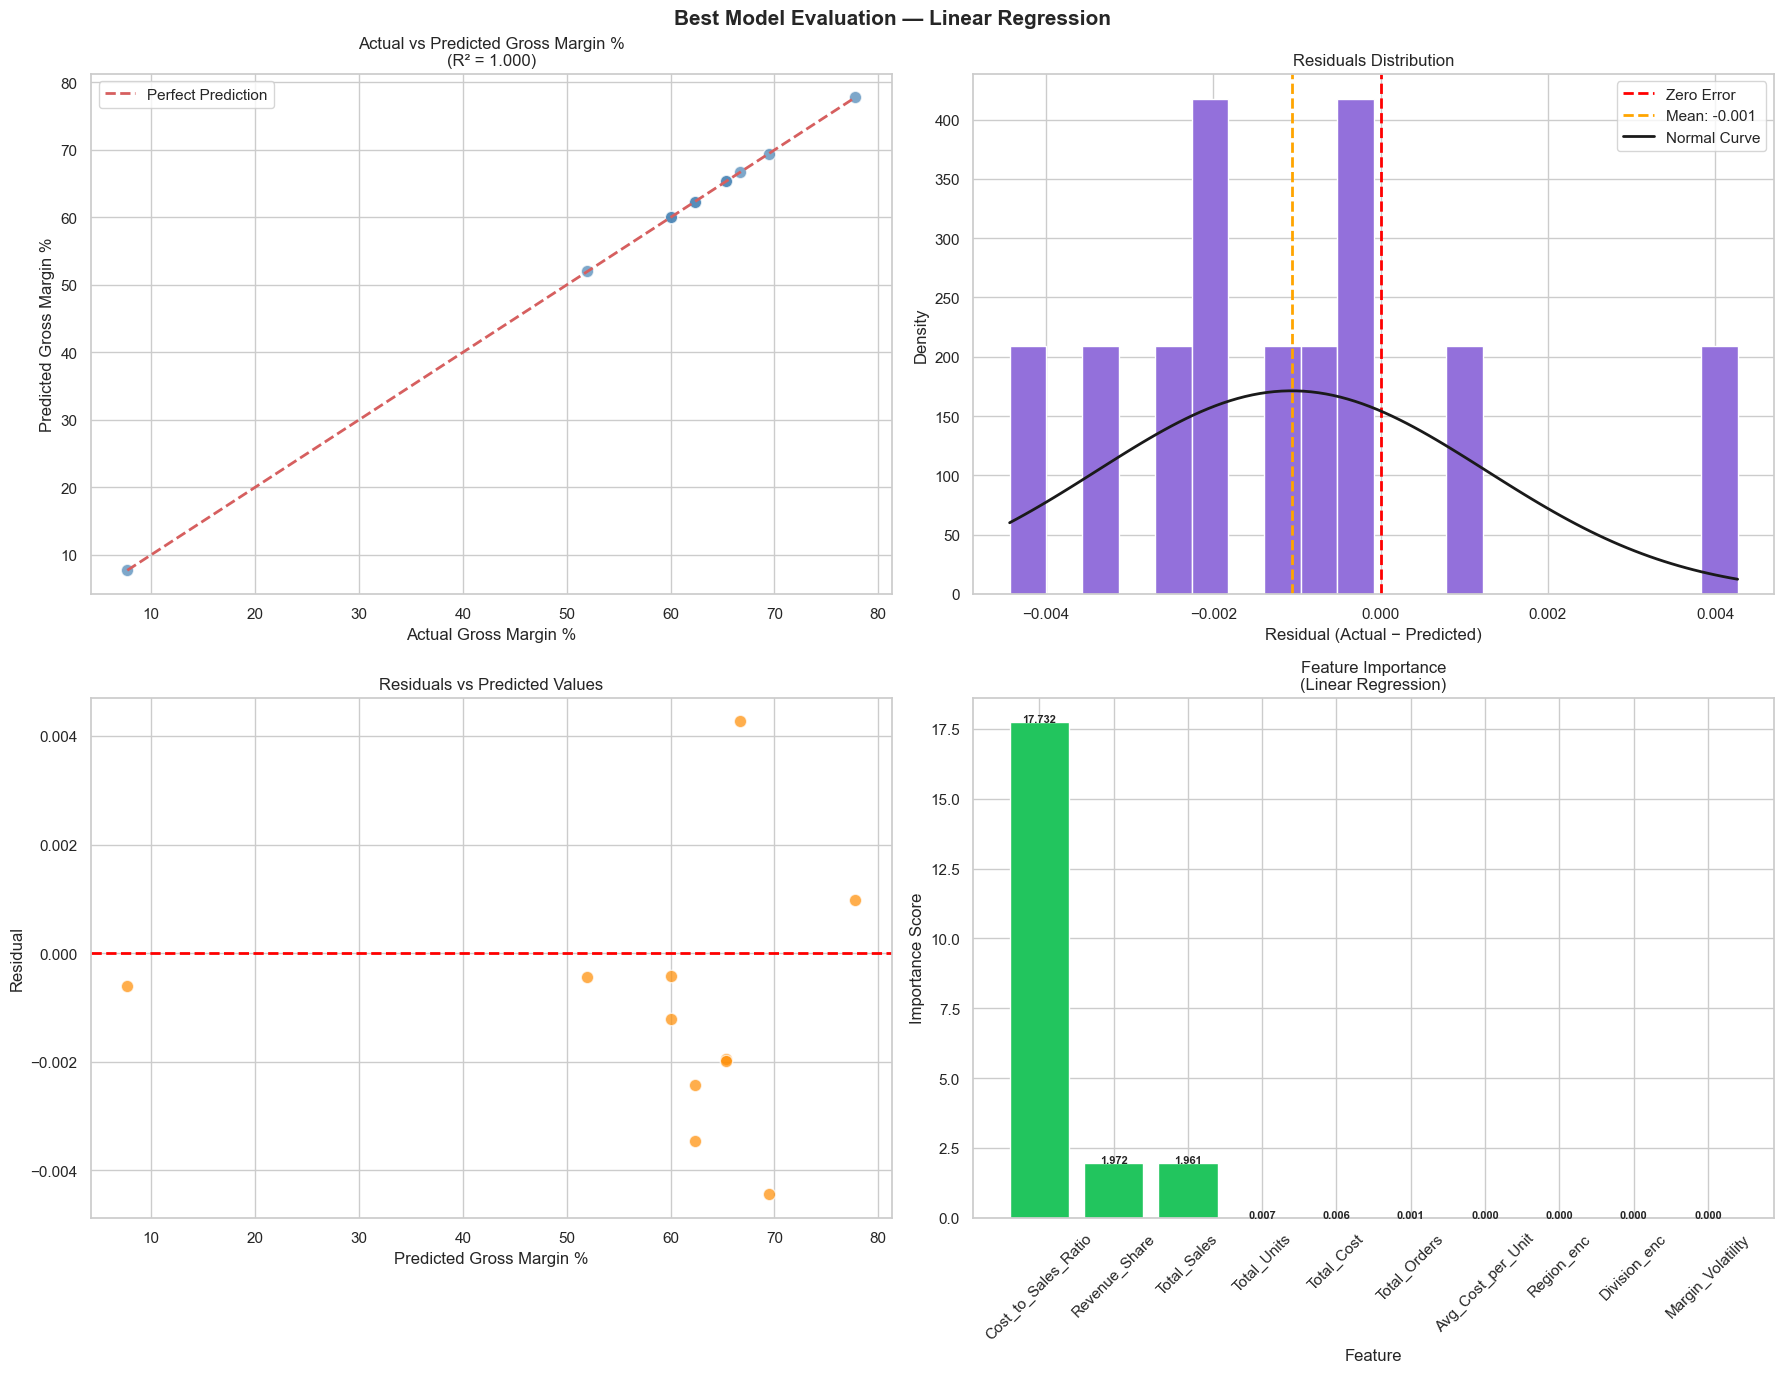


📊 All Models — Final Comparison:


,Model,CV_R2_Mean,CV_R2_Std,Test_R2,Test_MAE
0,Linear Regression,1.0000,0.0000,1.0000,0.0020
1,Lasso,1.0000,0.0000,1.0000,0.0057
2,Ridge,0.9952,0.0035,0.9993,0.2810
3,Gradient Boosting,0.8080,0.1456,0.9997,0.0885
4,Decision Tree,0.7828,0.1414,1.0000,0.0000
5,Random Forest,0.7193,0.2251,0.9983,0.5180


In [43]:
# Cell 14 — Best Model Evaluation & Feature Importance

# ── Retrain Best Model on Full Train Set ──
best_model_name = results_df.iloc[0]['Model']
best_model      = models[best_model_name]

best_model.fit(X_train, y_train)
y_pred_best = best_model.predict(X_test)

best_r2  = r2_score(y_test, y_pred_best)
best_mse = mean_squared_error(y_test, y_pred_best)
best_mae = mean_absolute_error(y_test, y_pred_best)

print(f"🏆 Best Model : {best_model_name}")
print(f"   Test R²   : {best_r2:.4f}")
print(f"   Test MSE  : {best_mse:.4f}")
print(f"   Test MAE  : {best_mae:.4f}")
print(f"   RMSE      : {np.sqrt(best_mse):.4f}")

# ── Residual Analysis ──
residuals = y_test - y_pred_best

print(f"\n📊 Residual Analysis:")
print(f"   Mean Residual : {residuals.mean():.4f}  (closer to 0 = less bias)")
print(f"   Std Residual  : {residuals.std():.4f}")
print(f"   Max Overshot  : {residuals.min():.4f}")
print(f"   Max Undershot : {residuals.max():.4f}")

# ── Feature Importance ──
if hasattr(best_model, 'feature_importances_'):
    feat_imp = pd.Series(
        best_model.feature_importances_,
        index=X_scaled.columns
    ).sort_values(ascending=False)
elif hasattr(best_model, 'coef_'):
    feat_imp = pd.Series(
        np.abs(best_model.coef_),
        index=X_scaled.columns
    ).sort_values(ascending=False)
else:
    feat_imp = None

# ── Plots ──
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle(f'Best Model Evaluation — {best_model_name}',
             fontsize=15, fontweight='bold')

# Plot 1: Actual vs Predicted
axes[0,0].scatter(y_test, y_pred_best, alpha=0.7,
                  color='steelblue', edgecolors='white', s=80)
axes[0,0].plot([y_test.min(), y_test.max()],
               [y_test.min(), y_test.max()],
               'r--', lw=2, label='Perfect Prediction')
axes[0,0].set_title(f'Actual vs Predicted Gross Margin %\n(R² = {best_r2:.3f})')
axes[0,0].set_xlabel('Actual Gross Margin %')
axes[0,0].set_ylabel('Predicted Gross Margin %')
axes[0,0].legend()

# Plot 2: Residuals Distribution
axes[0,1].hist(residuals, bins=20, color='mediumpurple',
               edgecolor='white', density=True)
axes[0,1].axvline(0, color='red', linestyle='--', lw=2, label='Zero Error')
axes[0,1].axvline(residuals.mean(), color='orange', linestyle='--', lw=2,
                   label=f'Mean: {residuals.mean():.3f}')
# Overlay normal curve
from scipy.stats import norm
xmin, xmax = residuals.min(), residuals.max()
x_norm = np.linspace(xmin, xmax, 100)
axes[0,1].plot(x_norm, norm.pdf(x_norm, residuals.mean(), residuals.std()),
               'k-', lw=2, label='Normal Curve')
axes[0,1].set_title('Residuals Distribution')
axes[0,1].set_xlabel('Residual (Actual − Predicted)')
axes[0,1].set_ylabel('Density')
axes[0,1].legend()

# Plot 3: Residuals vs Predicted
axes[1,0].scatter(y_pred_best, residuals, alpha=0.7,
                  color='darkorange', edgecolors='white', s=80)
axes[1,0].axhline(0, color='red', linestyle='--', lw=2)
axes[1,0].set_title('Residuals vs Predicted Values')
axes[1,0].set_xlabel('Predicted Gross Margin %')
axes[1,0].set_ylabel('Residual')

# Plot 4: Feature Importance
if feat_imp is not None:
    colors_fi = ['#22c55e' if i < 3 else 'steelblue'
                 for i in range(len(feat_imp))]
    axes[1,1].bar(feat_imp.index, feat_imp.values,
                  color=colors_fi, edgecolor='white')
    axes[1,1].set_title(f'Feature Importance\n({best_model_name})')
    axes[1,1].set_xlabel('Feature')
    axes[1,1].set_ylabel('Importance Score')
    axes[1,1].tick_params(axis='x', rotation=45)
    for i, val in enumerate(feat_imp.values):
        axes[1,1].text(i, val + 0.001, f'{val:.3f}',
                       ha='center', fontsize=8, fontweight='bold')

    print(f"\n📊 Top 5 Features Driving Gross Margin %:")
    print(feat_imp.head(5).to_string())
else:
    axes[1,1].set_visible(False)

plt.tight_layout()
plt.savefig('plot_best_model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Model Score Summary ──
print("\n📊 All Models — Final Comparison:")
display(results_df[['Model','CV_R2_Mean','CV_R2_Std',
                     'Test_R2','Test_MAE']].round(4))

✅ Optimal K selected : 3

📊 Cluster Profiles:


,Avg_Gross_Margin,Total_Sales,Total_Profit,Cost_to_Sales_Ratio,Avg_Profit_per_Unit,Margin_Volatility,Total_Orders,Count,Segment
Cluster,,,,,,,,,
0,44.99,88.01,22.81,55.01,0.96,0.0,10.83,23,⚠️ Thin Margin
1,67.54,6584.64,4441.23,32.46,2.39,0.0,492.20,20,⭐ Premium Margin
2,67.33,806.65,409.35,32.67,7.45,0.0,10.10,10,✅ Healthy Margin



📊 Segment Summary:


,Product_Count,Avg_Margin,Avg_Sales,Avg_Profit,Avg_Cost_Ratio,Avg_Volatility
Segment,,,,,,
⚠️ Thin Margin,23,44.99,88.01,22.81,55.01,0.0
✅ Healthy Margin,10,67.33,806.65,409.35,32.67,0.0
⭐ Premium Margin,20,67.54,6584.64,4441.23,32.46,0.0


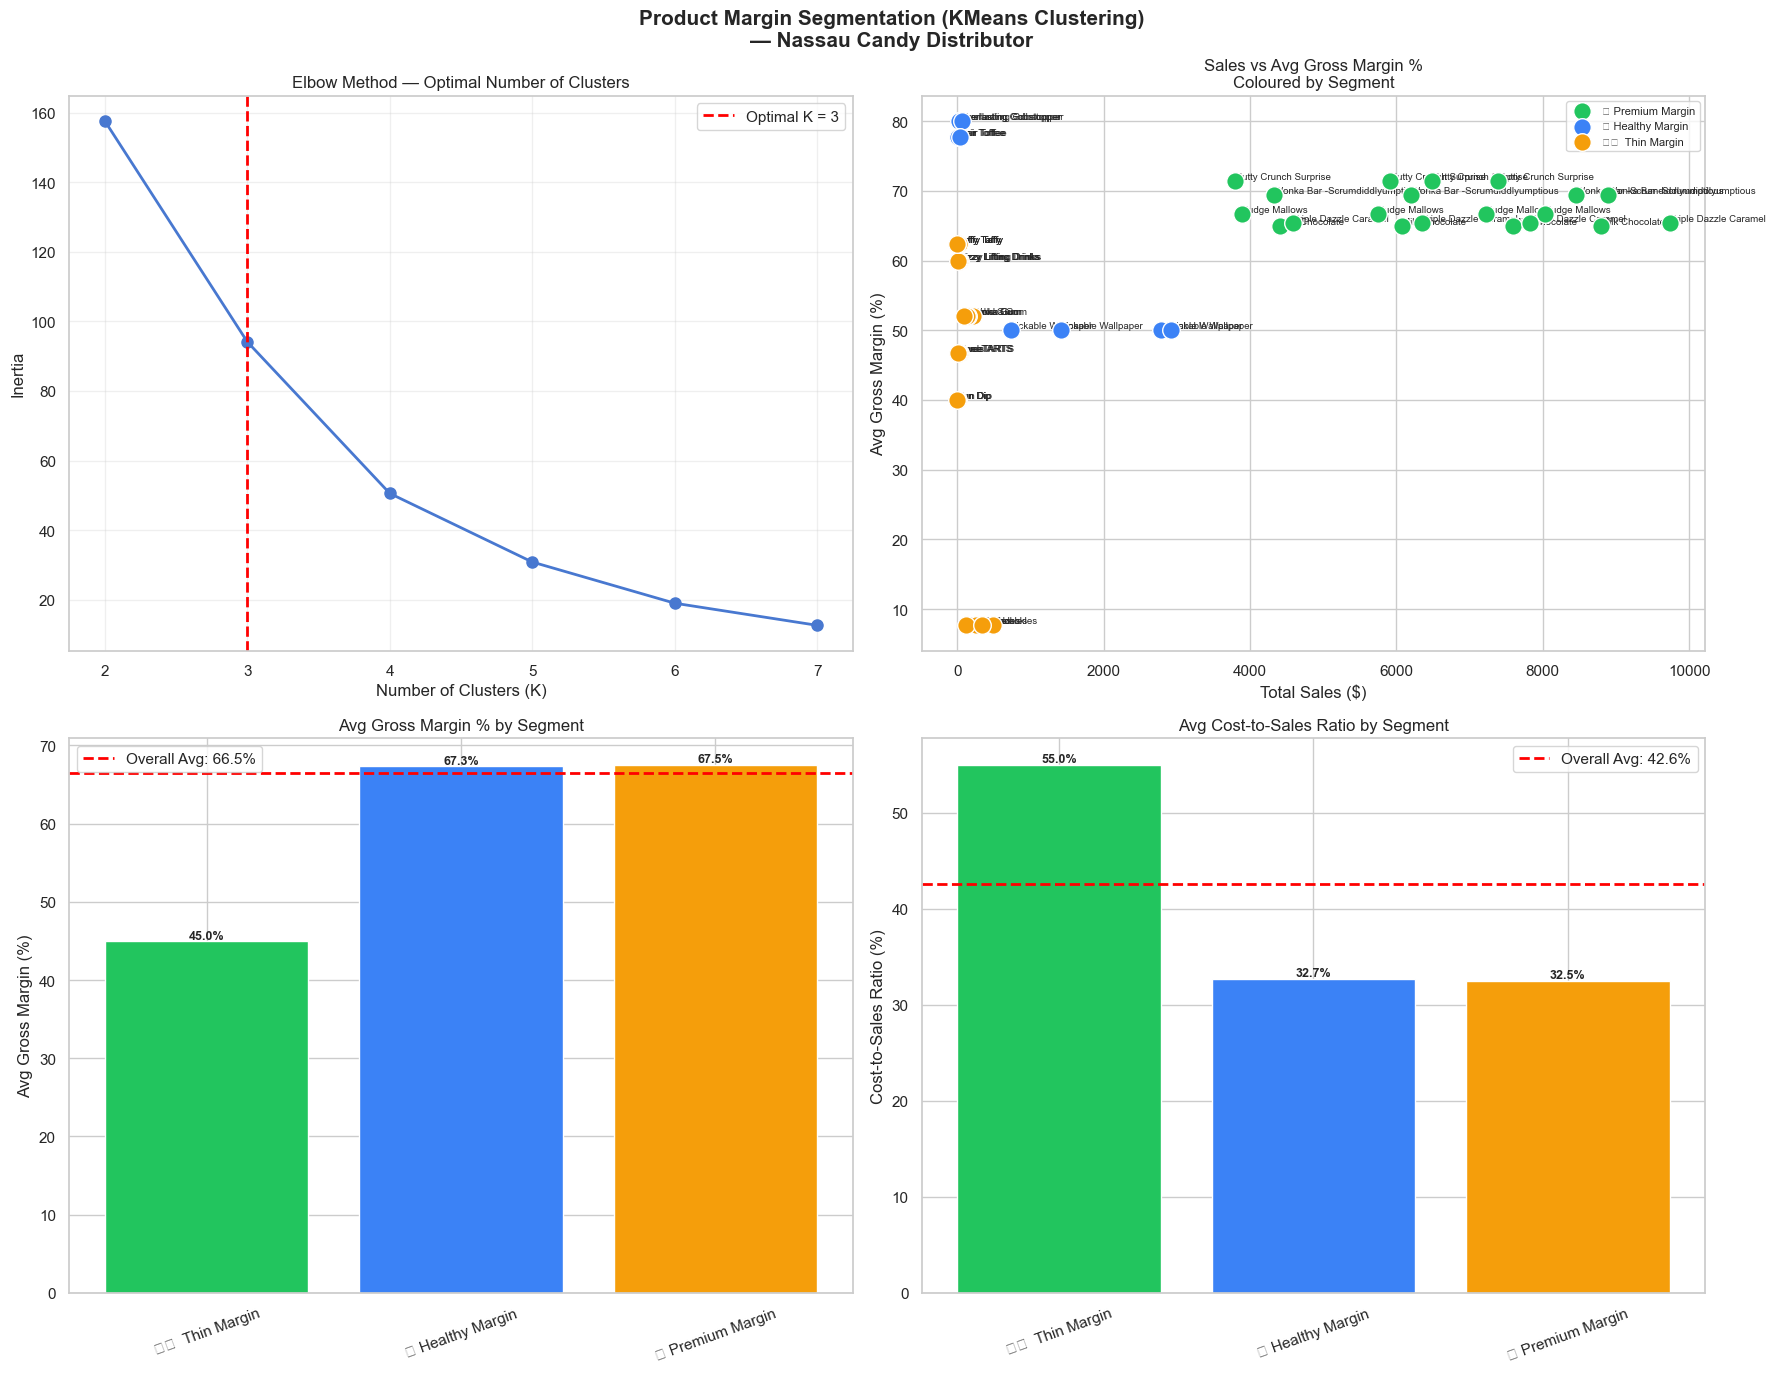


📊 Product → Segment Assignment:
                     Product Name  Division  Avg_Gross_Margin  Cost_to_Sales_Ratio          Segment
           Everlasting Gobstopper     Sugar             80.00               20.000 ✅ Healthy Margin
           Everlasting Gobstopper     Sugar             80.00               20.000 ✅ Healthy Margin
           Everlasting Gobstopper     Sugar             80.00               20.000 ✅ Healthy Margin
                      Hair Toffee     Sugar             77.78               22.222 ✅ Healthy Margin
                      Hair Toffee     Sugar             77.78               22.222 ✅ Healthy Margin
                      Hair Toffee     Sugar             77.78               22.222 ✅ Healthy Margin
Wonka Bar - Nutty Crunch Surprise Chocolate             71.35               28.653 ⭐ Premium Margin
Wonka Bar - Nutty Crunch Surprise Chocolate             71.35               28.653 ⭐ Premium Margin
Wonka Bar - Nutty Crunch Surprise Chocolate             71.35      

In [44]:
# Cell 15 — Product Clustering (KMeans — Margin Segmentation)

# ── Prepare Clustering Features ──
cluster_features = [
    'Avg_Gross_Margin', 'Total_Sales', 'Total_Profit',
    'Cost_to_Sales_Ratio', 'Avg_Profit_per_Unit',
    'Margin_Volatility', 'Total_Orders'
]

cluster_df = ml_product[cluster_features + ['Product Name', 'Division']].dropna().copy()

scaler_c  = StandardScaler()
X_cluster = scaler_c.fit_transform(cluster_df[cluster_features])

# ── Elbow Method ──
inertias = []
k_range  = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(X_cluster)
    inertias.append(km.inertia_)

# ── Pick Best K ──
drops  = [inertias[i] - inertias[i+1] for i in range(len(inertias)-1)]
best_k = list(k_range)[drops.index(max(drops)) + 1]
best_k = max(3, min(best_k, 4))
print(f"✅ Optimal K selected : {best_k}")

# ── Final KMeans ──
km_final = KMeans(n_clusters=best_k, random_state=RANDOM_STATE, n_init=10)
cluster_df['Cluster'] = km_final.fit_predict(X_cluster)

# ── Auto-Label Clusters by Avg Gross Margin ──
cluster_profiles = cluster_df.groupby('Cluster')[cluster_features].mean().round(2)
cluster_profiles['Count'] = cluster_df.groupby('Cluster').size()

sorted_clusters = cluster_profiles['Avg_Gross_Margin'].sort_values(ascending=False)
segment_labels  = [
    '⭐ Premium Margin',
    '✅ Healthy Margin',
    '⚠️  Thin Margin',
    '🔴 Critical Margin'
]
label_map = {cid: segment_labels[i]
             for i, (cid, _) in enumerate(sorted_clusters.items())}

cluster_df['Segment'] = cluster_df['Cluster'].map(label_map)
cluster_profiles['Segment'] = cluster_profiles.index.map(label_map)

print("\n📊 Cluster Profiles:")
display(cluster_profiles)

# ── Segment Summary ──
segment_summary = cluster_df.groupby('Segment').agg(
    Product_Count    = ('Product Name',     'count'),
    Avg_Margin       = ('Avg_Gross_Margin', 'mean'),
    Avg_Sales        = ('Total_Sales',      'mean'),
    Avg_Profit       = ('Total_Profit',     'mean'),
    Avg_Cost_Ratio   = ('Cost_to_Sales_Ratio','mean'),
    Avg_Volatility   = ('Margin_Volatility','mean')
).round(2)

print("\n📊 Segment Summary:")
display(segment_summary)

# ── Plots ──
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Product Margin Segmentation (KMeans Clustering)\n— Nassau Candy Distributor',
             fontsize=15, fontweight='bold')

seg_colors = ['#22c55e', '#3b82f6', '#f59e0b', '#ef4444']
seg_order  = segment_labels[:best_k]

# Plot 1: Elbow Curve
axes[0,0].plot(k_range, inertias, 'bo-', lw=2, markersize=8)
axes[0,0].axvline(best_k, color='red', linestyle='--', lw=2,
                   label=f'Optimal K = {best_k}')
axes[0,0].set_title('Elbow Method — Optimal Number of Clusters')
axes[0,0].set_xlabel('Number of Clusters (K)')
axes[0,0].set_ylabel('Inertia')
axes[0,0].legend()
axes[0,0].grid(True, alpha=0.3)

# Plot 2: Scatter — Sales vs Gross Margin % coloured by Segment
for i, seg in enumerate(seg_order):
    mask = cluster_df['Segment'] == seg
    axes[0,1].scatter(
        cluster_df.loc[mask, 'Total_Sales'],
        cluster_df.loc[mask, 'Avg_Gross_Margin'],
        label=seg, color=seg_colors[i],
        s=160, edgecolors='white', zorder=5
    )
for _, row in cluster_df.iterrows():
    axes[0,1].annotate(
        row['Product Name'].split(' - ')[-1],
        (row['Total_Sales'], row['Avg_Gross_Margin']),
        fontsize=7, ha='left', va='bottom'
    )
axes[0,1].set_title('Sales vs Avg Gross Margin %\nColoured by Segment')
axes[0,1].set_xlabel('Total Sales ($)')
axes[0,1].set_ylabel('Avg Gross Margin (%)')
axes[0,1].legend(fontsize=8)

# Plot 3: Avg Gross Margin by Segment
seg_plot = segment_summary.reset_index()
bars3 = axes[1,0].bar(
    seg_plot['Segment'], seg_plot['Avg_Margin'],
    color=seg_colors[:len(seg_plot)], edgecolor='white'
)
axes[1,0].axhline(df['Gross Margin %'].mean(), color='red',
                   linestyle='--', lw=2,
                   label=f"Overall Avg: {df['Gross Margin %'].mean():.1f}%")
axes[1,0].set_title('Avg Gross Margin % by Segment')
axes[1,0].set_ylabel('Avg Gross Margin (%)')
axes[1,0].tick_params(axis='x', rotation=20)
axes[1,0].legend()
for bar, val in zip(bars3, seg_plot['Avg_Margin']):
    axes[1,0].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.3,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

# Plot 4: Cost-to-Sales Ratio by Segment
bars4 = axes[1,1].bar(
    seg_plot['Segment'], seg_plot['Avg_Cost_Ratio'],
    color=seg_colors[:len(seg_plot)], edgecolor='white'
)
axes[1,1].axhline(
    df.groupby('Product Name')['Cost per Unit'].mean().mean() /
    df.groupby('Product Name')['Sales'].mean().mean() * 100 * 0 +
    cost_summary['Cost_to_Sales_Ratio'].mean(),
    color='red', linestyle='--', lw=2,
    label=f"Overall Avg: {cost_summary['Cost_to_Sales_Ratio'].mean():.1f}%"
)
axes[1,1].set_title('Avg Cost-to-Sales Ratio by Segment')
axes[1,1].set_ylabel('Cost-to-Sales Ratio (%)')
axes[1,1].tick_params(axis='x', rotation=20)
axes[1,1].legend()
for bar, val in zip(bars4, seg_plot['Avg_Cost_Ratio']):
    axes[1,1].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.3,
                   f'{val:.1f}%', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_clustering.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Product Assignments ──
print("\n📊 Product → Segment Assignment:")
print(cluster_df[['Product Name','Division','Avg_Gross_Margin',
                   'Cost_to_Sales_Ratio','Segment']]
      .sort_values('Avg_Gross_Margin', ascending=False)
      .to_string(index=False))

In [45]:
# Cell 16 — KPI Dashboard Summary

print("=" * 65)
print("     NASSAU CANDY DISTRIBUTOR — KEY PERFORMANCE INDICATORS")
print("=" * 65)

# ── Overall Financials ──
total_sales    = df['Sales'].sum()
total_profit   = df['Gross Profit'].sum()
total_cost     = df['Cost'].sum()
total_units    = df['Units'].sum()
total_orders   = df['Order ID'].count()
overall_margin = (total_profit / total_sales * 100)

print("\n📌 OVERALL FINANCIALS")
print("=" * 65)
print(f"  Total Revenue        : ${total_sales:>12,.2f}")
print(f"  Total Gross Profit   : ${total_profit:>12,.2f}")
print(f"  Total Cost           : ${total_cost:>12,.2f}")
print(f"  Total Units Sold     : {total_units:>13,.0f}")
print(f"  Total Orders         : {total_orders:>13,.0f}")
print(f"  Overall Gross Margin : {overall_margin:>12.2f}%")

# ── KPI Table ──
print("\n📊 KEY PERFORMANCE INDICATORS")
print("=" * 65)
print(f"  {'KPI':<35} | {'VALUE':>12}")
print("-" * 65)
print(f"  {'Gross Margin %':<35} | {overall_margin:>11.2f}%")
print(f"  {'Avg Profit per Unit':<35} | ${df['Profit per Unit'].mean():>11.3f}")
print(f"  {'Avg Cost per Unit':<35} | ${df['Cost per Unit'].mean():>11.3f}")
print(f"  {'Revenue Concentration (Top 3 Products)':<35} | "
      f"{pareto.head(3)['Revenue_Contribution'].sum():>11.1f}%")
print(f"  {'Profit Concentration (Top 3 Products)':<35} | "
      f"{pareto.head(3)['Profit_Contribution'].sum():>11.1f}%")
print(f"  {'Margin Volatility (Std Dev)':<35} | "
      f"{df['Gross Margin %'].std():>11.2f}%")
print(f"  {'High Risk Orders (Margin < 20%)':<35} | "
      f"{(df['Margin Risk']=='High Risk').sum():>12,}")
print(f"  {'States Driving 80% of Profit':<35} | {states_80:>12}")
print(f"  {'Products Driving 80% of Profit':<35} | {products_80_profit:>12}")

# ── Division KPIs ──
# grab profit share column regardless of exact name
profit_share_col = [c for c in division_summary.columns
                    if 'Profit' in c and 'Contribution' in c][0]

print("\n📊 DIVISION PERFORMANCE")
print("=" * 65)
print(f"  {'Division':<14} | {'Revenue':>10} | {'Profit':>10} | "
      f"{'Margin %':>9} | {'Profit Share':>12}")
print("-" * 65)
for _, row in division_summary.iterrows():
    print(f"  {row['Division']:<14} | ${row['Total_Sales']:>9,.0f} | "
          f"${row['Total_Profit']:>9,.0f} | {row['Avg_Gross_Margin']:>8.1f}% | "
          f"{row[profit_share_col]:>11.1f}%")

# ── Product Leaderboard ──
print("\n🏆 PRODUCT PROFITABILITY LEADERBOARD")
print("=" * 65)
leaderboard_prod = product_summary.copy()
leaderboard_prod['Performance Score'] = (
    leaderboard_prod['Avg_Gross_Margin']      * 0.4 +
    (leaderboard_prod['Total_Profit'] /
     leaderboard_prod['Total_Profit'].max() * 100) * 0.35 +
    leaderboard_prod['Profit_Contribution']   * 0.25
).round(2)

leaderboard_prod = leaderboard_prod.sort_values(
    'Performance Score', ascending=False
).reset_index(drop=True)
leaderboard_prod.index += 1

print("\n🥇 Top 5 Products:")
display(leaderboard_prod.head(5)[['Product Name', 'Division', 'Total_Sales',
                                   'Total_Profit', 'Avg_Gross_Margin',
                                   'Performance Score']])

print("\n⚠️  Bottom 5 Products:")
display(leaderboard_prod.tail(5)[['Product Name', 'Division', 'Total_Sales',
                                   'Total_Profit', 'Avg_Gross_Margin',
                                   'Performance Score']])

# ── Margin Risk Summary ──
print("\n📊 MARGIN RISK BREAKDOWN")
print("=" * 65)
risk_summary = df.groupby('Margin Risk').agg(
    Order_Count  = ('Order ID',       'count'),
    Total_Sales  = ('Sales',          'sum'),
    Total_Profit = ('Gross Profit',   'sum'),
    Avg_Margin   = ('Gross Margin %', 'mean')
).round(2)
display(risk_summary)

# ── Cluster Segment Summary ──
print("\n🗂️  PRODUCT MARGIN SEGMENTS")
print("=" * 65)
display(segment_summary)

# ── ML Model Summary ──
print("\n🤖 ML MODEL RESULTS")
print("=" * 65)
print(f"  Best Model       : {results_df.iloc[0]['Model']}")
print(f"  CV R²            : {results_df.iloc[0]['CV_R2_Mean']:.4f} "
      f"± {results_df.iloc[0]['CV_R2_Std']:.4f}")
print(f"  Test R²          : {best_r2:.4f}")
print(f"  Test MAE         : {best_mae:.4f}%")
print(f"  Top Predictor    : {feat_imp.index[0] if feat_imp is not None else 'N/A'}")

print("\n" + "=" * 65)
print("✅ KPI Dashboard Complete!")
print("=" * 65)

     NASSAU CANDY DISTRIBUTOR — KEY PERFORMANCE INDICATORS

📌 OVERALL FINANCIALS
  Total Revenue        : $  141,783.63
  Total Gross Profit   : $   93,442.80
  Total Cost           : $   48,340.83
  Total Units Sold     :        38,654
  Total Orders         :        10,194
  Overall Gross Margin :        65.91%

📊 KEY PERFORMANCE INDICATORS
  KPI                                 |        VALUE
-----------------------------------------------------------------
  Gross Margin %                      |       65.91%
  Avg Profit per Unit                 | $      2.413
  Avg Cost per Unit                   | $      1.242
  Revenue Concentration (Top 3 Products) |        58.7%
  Profit Concentration (Top 3 Products) |        59.3%
  Margin Volatility (Std Dev)         |        6.72%
  High Risk Orders (Margin < 20%)     |           96
  States Driving 80% of Profit        |           16
  Products Driving 80% of Profit      |            5

📊 DIVISION PERFORMANCE
  Division       |    Revenue 

,Product Name,Division,Total_Sales,Total_Profit,Avg_Gross_Margin,Performance Score
1,Wonka Bar -Scrumdiddlyumptious,Chocolate,27874.80,19357.50,69.44,67.96
2,Wonka Bar - Triple Dazzle Caramel,Chocolate,28485.00,18610.20,65.33,64.76
3,Wonka Bar - Nutty Crunch Surprise,Chocolate,23574.95,16819.95,71.35,63.45
4,Wonka Bar - Milk Chocolate,Chocolate,26867.75,17443.37,64.92,62.17
5,Wonka Bar - Fudge Mallows,Chocolate,24890.40,16593.60,66.67,61.11



⚠️  Bottom 5 Products:


,Product Name,Division,Total_Sales,Total_Profit,Avg_Gross_Margin,Performance Score
11,Wonka Gum,Other,597.50,310.70,52.00,21.44
12,SweeTARTS,Sugar,61.50,28.70,46.67,18.73
13,Nerds,Sugar,15.00,7.00,46.67,18.68
14,Fun Dip,Sugar,12.00,4.80,40.00,16.01
15,Kazookles,Other,1205.75,92.75,7.69,3.27



📊 MARGIN RISK BREAKDOWN


,Order_Count,Total_Sales,Total_Profit,Avg_Margin
Margin Risk,,,,
High Risk,96,1205.75,92.75,7.69
Low Risk,10098,140577.88,93350.05,67.07



🗂️  PRODUCT MARGIN SEGMENTS


,Product_Count,Avg_Margin,Avg_Sales,Avg_Profit,Avg_Cost_Ratio,Avg_Volatility
Segment,,,,,,
⚠️ Thin Margin,23,44.99,88.01,22.81,55.01,0.0
✅ Healthy Margin,10,67.33,806.65,409.35,32.67,0.0
⭐ Premium Margin,20,67.54,6584.64,4441.23,32.46,0.0



🤖 ML MODEL RESULTS
  Best Model       : Linear Regression
  CV R²            : 1.0000 ± 0.0000
  Test R²          : 1.0000
  Test MAE         : 0.0020%
  Top Predictor    : Cost_to_Sales_Ratio

✅ KPI Dashboard Complete!


     STRATEGIC PRODUCT CLASSIFICATION & FLAG ANALYSIS

📐 Thresholds Used:
   High Sales boundary  : $901.62 (median)
   Low Margin boundary  : 35.0%
   Low Profit boundary  : $207.35 (median)

📊 Full Strategic Product Classification:


,Product Name,Division,Factory,Total_Sales,Total_Profit,Avg_Gross_Margin,Revenue_Share %,Profit_Share %,Strategic_Class,Action_Flag
1,Kazookles,Other,The Other Factory,1205.75,92.75,7.69,0.85,0.10,⚠️ High-Sales / Low-Margin,🔁 Repricing Needed
2,Lickable Wallpaper,Other,Secret Factory,7860.00,3930.00,50.00,5.55,4.21,⭐ Star Product,✅ Promote & Scale
3,Wonka Bar - Fudge Mallows,Chocolate,Lot's O' Nuts,24890.40,16593.60,66.67,17.56,17.77,⭐ Star Product,✅ Promote & Scale
4,Wonka Bar - Milk Chocolate,Chocolate,Wicked Choccy's,26867.75,17443.37,64.92,18.96,18.68,⭐ Star Product,✅ Promote & Scale
5,Wonka Bar - Nutty Crunch Surprise,Chocolate,Lot's O' Nuts,23574.95,16819.95,71.35,16.64,18.01,⭐ Star Product,✅ Promote & Scale
6,Wonka Bar - Triple Dazzle Caramel,Chocolate,Wicked Choccy's,28485.00,18610.20,65.33,20.10,19.93,⭐ Star Product,✅ Promote & Scale
7,Wonka Bar -Scrumdiddlyumptious,Chocolate,Lot's O' Nuts,27874.80,19357.50,69.44,19.67,20.73,⭐ Star Product,✅ Promote & Scale
8,Wonka Gum,Other,Secret Factory,597.50,310.70,52.00,0.42,0.33,💎 Niche High-Margin,📦 Protect Niche
9,Everlasting Gobstopper,Sugar,Secret Factory,130.00,104.00,80.00,0.09,0.11,🟡 Average Performer,👁️ Monitor Closely
10,Fun Dip,Sugar,Sugar Shack,12.00,4.80,40.00,0.01,0.01,🟡 Average Performer,👁️ Monitor Closely



📊 Products by Strategic Class:


,Count,Avg_Margin,Total_Sales,Total_Profit,Revenue_Share,Profit_Share
Strategic_Class,,,,,,
⚠️ High-Sales / Low-Margin,1,7.69,1205.75,92.75,0.85,0.10
⭐ Star Product,6,64.62,139552.90,92754.62,98.48,99.33
💎 Niche High-Margin,1,52.00,597.50,310.70,0.42,0.33
🟡 Average Performer,6,58.90,348.73,237.48,0.24,0.26



⚠️  HIGH-SALES / LOW-MARGIN Products (Repricing Priority):


,Product Name,Division,Factory,Total_Sales,Avg_Gross_Margin,Cost_to_Sales %,Action_Flag
1,Kazookles,Other,The Other Factory,1205.75,7.69,92.31,🔁 Repricing Needed



📉 HIGH-SALES / LOW-PROFIT Products:
  None found under current thresholds

🔴 LOW-SALES / LOW-PROFIT Products (Discontinuation Review):
  None found under current thresholds

⭐ STAR Products (Promote & Scale):


,Product Name,Division,Factory,Total_Sales,Total_Profit,Avg_Gross_Margin,Action_Flag
2,Lickable Wallpaper,Other,Secret Factory,7860.00,3930.00,50.00,✅ Promote & Scale
3,Wonka Bar - Fudge Mallows,Chocolate,Lot's O' Nuts,24890.40,16593.60,66.67,✅ Promote & Scale
4,Wonka Bar - Milk Chocolate,Chocolate,Wicked Choccy's,26867.75,17443.37,64.92,✅ Promote & Scale
5,Wonka Bar - Nutty Crunch Surprise,Chocolate,Lot's O' Nuts,23574.95,16819.95,71.35,✅ Promote & Scale
6,Wonka Bar - Triple Dazzle Caramel,Chocolate,Wicked Choccy's,28485.00,18610.20,65.33,✅ Promote & Scale
7,Wonka Bar -Scrumdiddlyumptious,Chocolate,Lot's O' Nuts,27874.80,19357.50,69.44,✅ Promote & Scale


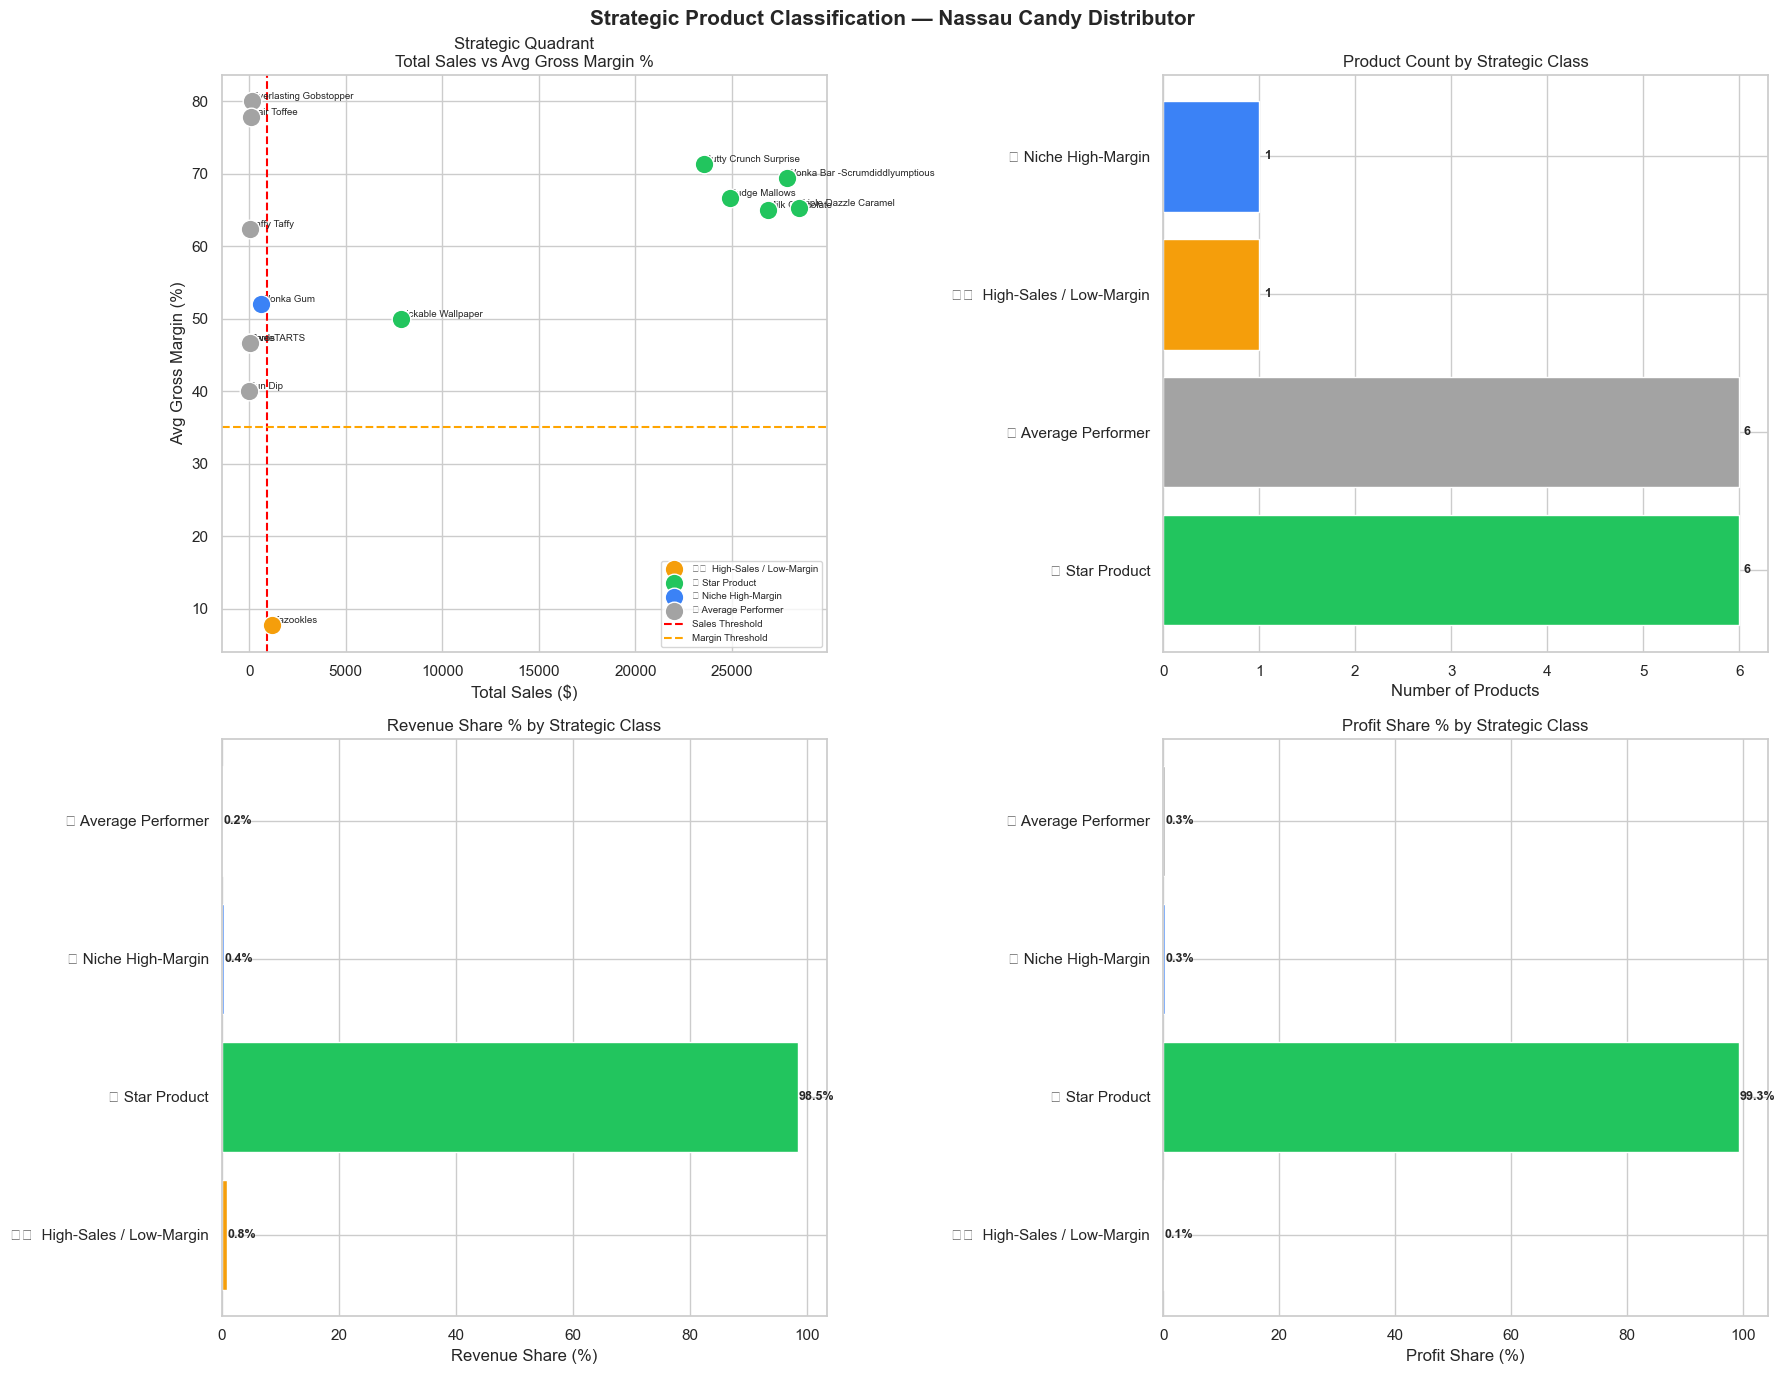


✅ Strategic Product Classification Complete!


In [46]:
# Cell 17 — Flagged Product List (Strategic Classification)

print("=" * 65)
print("     STRATEGIC PRODUCT CLASSIFICATION & FLAG ANALYSIS")
print("=" * 65)

# ── Build Master Product Metrics ──
product_flags = df.groupby(['Product Name', 'Division', 'Factory']).agg(
    Total_Sales      = ('Sales',          'sum'),
    Total_Profit     = ('Gross Profit',   'sum'),
    Total_Units      = ('Units',          'sum'),
    Avg_Gross_Margin = ('Gross Margin %', 'mean'),
    Avg_Profit_per_Unit = ('Profit per Unit', 'mean'),
    Total_Orders     = ('Order ID',       'count'),
    Margin_Std       = ('Gross Margin %', 'std')
).reset_index().round(3)

product_flags['Margin_Std']        = product_flags['Margin_Std'].fillna(0)
product_flags['Revenue_Share %']   = (product_flags['Total_Sales'] /
                                       product_flags['Total_Sales'].sum() * 100).round(2)
product_flags['Profit_Share %']    = (product_flags['Total_Profit'] /
                                       product_flags['Total_Profit'].sum() * 100).round(2)
product_flags['Cost_to_Sales %']   = ((product_flags['Total_Sales'] -
                                        product_flags['Total_Profit']) /
                                        product_flags['Total_Sales'] * 100).round(2)

# ── Thresholds ──
median_sales   = product_flags['Total_Sales'].median()
median_margin  = product_flags['Avg_Gross_Margin'].median()
median_profit  = product_flags['Total_Profit'].median()
low_margin_thr = 35.0   # below this = low margin
high_sales_thr = median_sales
low_profit_thr = median_profit
low_sales_thr  = median_sales

print(f"\n📐 Thresholds Used:")
print(f"   High Sales boundary  : ${high_sales_thr:,.2f} (median)")
print(f"   Low Margin boundary  : {low_margin_thr:.1f}%")
print(f"   Low Profit boundary  : ${low_profit_thr:,.2f} (median)")

# ── Strategic Quadrant Assignment ──
def classify_product(row):
    high_sales  = row['Total_Sales']  >= high_sales_thr
    low_margin  = row['Avg_Gross_Margin'] < low_margin_thr
    low_profit  = row['Total_Profit'] <  low_profit_thr
    high_margin = row['Avg_Gross_Margin'] >= low_margin_thr
    high_profit = row['Total_Profit'] >= low_profit_thr

    if high_sales and high_margin and high_profit:
        return '⭐ Star Product'
    elif high_sales and low_margin:
        return '⚠️  High-Sales / Low-Margin'
    elif high_sales and low_profit:
        return '📉 High-Sales / Low-Profit'
    elif not high_sales and low_profit and low_margin:
        return '🔴 Low-Sales / Low-Profit'
    elif not high_sales and high_margin and high_profit:
        return '💎 Niche High-Margin'
    else:
        return '🟡 Average Performer'

product_flags['Strategic_Class'] = product_flags.apply(classify_product, axis=1)

# ── Action Flag ──
def action_flag(row):
    if '⚠️' in row['Strategic_Class'] or '📉' in row['Strategic_Class']:
        return '🔁 Repricing Needed'
    elif '🔴' in row['Strategic_Class']:
        return '❌ Discontinuation Review'
    elif '⭐' in row['Strategic_Class']:
        return '✅ Promote & Scale'
    elif '💎' in row['Strategic_Class']:
        return '📦 Protect Niche'
    else:
        return '👁️  Monitor Closely'

product_flags['Action_Flag'] = product_flags.apply(action_flag, axis=1)

product_flags = product_flags.sort_values(
    'Strategic_Class'
).reset_index(drop=True)
product_flags.index += 1

print("\n📊 Full Strategic Product Classification:")
display(product_flags[['Product Name', 'Division', 'Factory',
                        'Total_Sales', 'Total_Profit',
                        'Avg_Gross_Margin', 'Revenue_Share %',
                        'Profit_Share %', 'Strategic_Class', 'Action_Flag']])

# ── Breakdown by Class ──
print("\n📊 Products by Strategic Class:")
class_summary = product_flags.groupby('Strategic_Class').agg(
    Count        = ('Product Name',     'count'),
    Avg_Margin   = ('Avg_Gross_Margin', 'mean'),
    Total_Sales  = ('Total_Sales',      'sum'),
    Total_Profit = ('Total_Profit',     'sum'),
    Revenue_Share= ('Revenue_Share %',  'sum'),
    Profit_Share = ('Profit_Share %',   'sum')
).round(2)
display(class_summary)

# ── Flagged Lists ──
print("\n⚠️  HIGH-SALES / LOW-MARGIN Products (Repricing Priority):")
hs_lm = product_flags[product_flags['Strategic_Class'] == '⚠️  High-Sales / Low-Margin']
if len(hs_lm) > 0:
    display(hs_lm[['Product Name', 'Division', 'Factory',
                    'Total_Sales', 'Avg_Gross_Margin',
                    'Cost_to_Sales %', 'Action_Flag']])
else:
    print("  None found under current thresholds")

print("\n📉 HIGH-SALES / LOW-PROFIT Products:")
hs_lp = product_flags[product_flags['Strategic_Class'] == '📉 High-Sales / Low-Profit']
if len(hs_lp) > 0:
    display(hs_lp[['Product Name', 'Division', 'Factory',
                    'Total_Sales', 'Total_Profit',
                    'Avg_Gross_Margin', 'Action_Flag']])
else:
    print("  None found under current thresholds")

print("\n🔴 LOW-SALES / LOW-PROFIT Products (Discontinuation Review):")
ls_lp = product_flags[product_flags['Strategic_Class'] == '🔴 Low-Sales / Low-Profit']
if len(ls_lp) > 0:
    display(ls_lp[['Product Name', 'Division', 'Factory',
                    'Total_Sales', 'Total_Profit',
                    'Avg_Gross_Margin', 'Action_Flag']])
else:
    print("  None found under current thresholds")

print("\n⭐ STAR Products (Promote & Scale):")
stars = product_flags[product_flags['Strategic_Class'] == '⭐ Star Product']
if len(stars) > 0:
    display(stars[['Product Name', 'Division', 'Factory',
                    'Total_Sales', 'Total_Profit',
                    'Avg_Gross_Margin', 'Action_Flag']])
else:
    print("  None found under current thresholds")

# ── Plots ──
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
fig.suptitle('Strategic Product Classification — Nassau Candy Distributor',
             fontsize=15, fontweight='bold')

class_colors = {
    '⭐ Star Product'            : '#22c55e',
    '⚠️  High-Sales / Low-Margin': '#f59e0b',
    '📉 High-Sales / Low-Profit' : '#fb923c',
    '🔴 Low-Sales / Low-Profit'  : '#ef4444',
    '💎 Niche High-Margin'       : '#3b82f6',
    '🟡 Average Performer'       : '#a3a3a3'
}

# Plot 1: Strategic Quadrant — Sales vs Margin
for cls, grp in product_flags.groupby('Strategic_Class'):
    color = class_colors.get(cls, 'grey')
    axes[0,0].scatter(grp['Total_Sales'], grp['Avg_Gross_Margin'],
                      label=cls, color=color,
                      s=180, edgecolors='white', zorder=5)
    for _, row in grp.iterrows():
        axes[0,0].annotate(
            row['Product Name'].split(' - ')[-1],
            (row['Total_Sales'], row['Avg_Gross_Margin']),
            fontsize=7, ha='left', va='bottom'
        )
axes[0,0].axvline(high_sales_thr, color='red',
                   linestyle='--', lw=1.5, label='Sales Threshold')
axes[0,0].axhline(low_margin_thr, color='orange',
                   linestyle='--', lw=1.5, label='Margin Threshold')
axes[0,0].set_title('Strategic Quadrant\nTotal Sales vs Avg Gross Margin %')
axes[0,0].set_xlabel('Total Sales ($)')
axes[0,0].set_ylabel('Avg Gross Margin (%)')
axes[0,0].legend(fontsize=7)

# Plot 2: Strategic Class Count
class_counts = product_flags['Strategic_Class'].value_counts()
bar_colors   = [class_colors.get(c, 'grey') for c in class_counts.index]
axes[0,1].barh(class_counts.index, class_counts.values,
               color=bar_colors, edgecolor='white')
axes[0,1].set_title('Product Count by Strategic Class')
axes[0,1].set_xlabel('Number of Products')
for i, val in enumerate(class_counts.values):
    axes[0,1].text(val + 0.05, i, str(val),
                   va='center', fontsize=9, fontweight='bold')

# Plot 3: Revenue Share by Strategic Class
rev_by_class = product_flags.groupby('Strategic_Class')['Revenue_Share %'].sum()
bar_colors2  = [class_colors.get(c, 'grey') for c in rev_by_class.index]
axes[1,0].barh(rev_by_class.index, rev_by_class.values,
               color=bar_colors2, edgecolor='white')
axes[1,0].set_title('Revenue Share % by Strategic Class')
axes[1,0].set_xlabel('Revenue Share (%)')
for i, val in enumerate(rev_by_class.values):
    axes[1,0].text(val + 0.1, i, f'{val:.1f}%',
                   va='center', fontsize=9, fontweight='bold')

# Plot 4: Profit Share by Strategic Class
pro_by_class = product_flags.groupby('Strategic_Class')['Profit_Share %'].sum()
bar_colors3  = [class_colors.get(c, 'grey') for c in pro_by_class.index]
axes[1,1].barh(pro_by_class.index, pro_by_class.values,
               color=bar_colors3, edgecolor='white')
axes[1,1].set_title('Profit Share % by Strategic Class')
axes[1,1].set_xlabel('Profit Share (%)')
for i, val in enumerate(pro_by_class.values):
    axes[1,1].text(val + 0.1, i, f'{val:.1f}%',
                   va='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('plot_strategic_classification.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 65)
print("✅ Strategic Product Classification Complete!")
print("=" * 65)

In [51]:
# Cell 18 — Export All Results to Excel & Save Plots

import os
import shutil

# ── Create Output Folder ──
os.makedirs("Nassau_Results", exist_ok=True)

# ── Export All DataFrames to Multi-Sheet Excel ──
with pd.ExcelWriter("Nassau_Results/Nassau_Candy_Analysis_Results.xlsx",
                    engine="openpyxl") as writer:

    # Raw Cleaned Data
    df.to_excel(writer, sheet_name="Cleaned_Data", index=False)

    # Product Summary
    product_summary.to_excel(writer, sheet_name="Product_Summary", index=False)

    # Division Summary
    division_summary.to_excel(writer, sheet_name="Division_Summary", index=False)

    # Region Summary
    region_summary.to_excel(writer, sheet_name="Region_Summary", index=False)

    # Pareto Table
    pareto.to_excel(writer, sheet_name="Pareto_Analysis", index=False)

    # State Pareto
    state_pareto.to_excel(writer, sheet_name="State_Pareto", index=False)

    # Cost Summary
    cost_summary.to_excel(writer, sheet_name="Cost_Diagnostics", index=False)

    # Monthly Trend
    monthly.to_excel(writer, sheet_name="Monthly_Trend", index=False)

    # Product Leaderboard
    leaderboard_prod.to_excel(writer, sheet_name="Product_Leaderboard", index=False)

    # Clustering Results
    cluster_df[['Product Name', 'Division', 'Avg_Gross_Margin',
                'Total_Sales', 'Total_Profit', 'Cost_to_Sales_Ratio',
                'Margin_Volatility', 'Segment']].to_excel(
        writer, sheet_name="Clustering_Segments", index=False)

    # Segment Summary
    segment_summary.reset_index().to_excel(
        writer, sheet_name="Segment_Summary", index=False)

    # ML Model Results
    results_df.to_excel(writer, sheet_name="ML_Model_Results", index=False)

    # Factory Summary  ← NEW
    factory_summary.to_excel(writer, sheet_name="Factory_Summary", index=False)

    # Strategic Product Flags  ← NEW
    product_flags.to_excel(writer, sheet_name="Product_Flags", index=False)

    # ML Feature Dataset  ← NEW
    ml_product.to_excel(writer, sheet_name="ML_Features", index=False)

    # KPIs
    kpi_df = pd.DataFrame({
        'KPI': [
            'Total Revenue',
            'Total Gross Profit',
            'Total Cost',
            'Total Units Sold',
            'Total Orders',
            'Overall Gross Margin %',
            'Avg Profit per Unit',
            'Avg Cost per Unit',
            'Margin Volatility (Std)',
            'High Risk Orders',
            'States Driving 80% Profit',
            'Products Driving 80% Profit',
            'Best ML Model',
            'Best ML Test R2',
            'Best ML Test MAE'
        ],
        'Value': [
            round(total_sales,   2),
            round(total_profit,  2),
            round(total_cost,    2),
            int(total_units),
            int(total_orders),
            round(overall_margin, 2),
            round(df['Profit per Unit'].mean(), 3),
            round(df['Cost per Unit'].mean(),   3),
            round(df['Gross Margin %'].std(),   2),
            int((df['Margin Risk'] == 'High Risk').sum()),
            int(states_80),
            int(products_80_profit),
            results_df.iloc[0]['Model'],
            round(best_r2,  4),
            round(best_mae, 4)
        ],
        'Description': [
            'Sum of all order sales',
            'Sum of all gross profits',
            'Sum of all manufacturing costs',
            'Total units sold across all orders',
            'Total number of orders',
            'Gross Profit / Sales × 100',
            'Gross Profit / Units',
            'Cost / Units',
            'Standard deviation of gross margin %',
            'Orders with margin below 20%',
            'States contributing 80% of total profit',
            'Products contributing 80% of total profit',
            'Top performing regression model',
            'R² score on held-out test set',
            'Mean absolute error on test set'
        ]
    })
    kpi_df.to_excel(writer, sheet_name="KPI_Summary", index=False)

print("✅ Excel exported → Nassau_Results/Nassau_Candy_Analysis_Results.xlsx")

# ── Copy All Saved Plots ──
plot_files = [f for f in os.listdir(".")
              if f.startswith("plot_") and f.endswith(".png")]
for plot in plot_files:
    shutil.copy(plot, f"Nassau_Results/{plot}")

print(f"✅ {len(plot_files)} plots copied → Nassau_Results/")

# ── Final File List ──
print("\n📁 Files in Nassau_Results/:")
for f in sorted(os.listdir("Nassau_Results")):
    size = os.path.getsize(f"Nassau_Results/{f}") / 1024
    print(f"   • {f:<55} {size:>8.1f} KB")

print("\n" + "=" * 65)
print("✅ ANALYSIS COMPLETE — NASSAU CANDY DISTRIBUTOR")
print("=" * 65)

✅ Excel exported → Nassau_Results/Nassau_Candy_Analysis_Results.xlsx
✅ 14 plots copied → Nassau_Results/

📁 Files in Nassau_Results/:
   • Nassau_Candy_Analysis_Results.xlsx                        1381.8 KB
   • plot_best_model_evaluation.png                             287.6 KB
   • plot_clustering.png                                        299.4 KB
   • plot_correlation_matrix.png                                155.2 KB
   • plot_cost_diagnostics.png                                  430.8 KB
   • plot_division_performance.png                              227.1 KB
   • plot_factory_performance.png                               230.8 KB
   • plot_hypothesis_testing.png                                134.0 KB
   • plot_margin_volatility_timeseries.png                      311.8 KB
   • plot_model_comparison.png                                   94.6 KB
   • plot_overall_margin_trend.png                               79.6 KB
   • plot_pareto_analysis.png                                  